

An Information Retrieval Engine




#**Phase 1: Retrieval Basics:**


##**1. Data Exploration, Statistics, and Preparation**




**Importer le dataset de Kaggle**



In [ ]:
# Install the Kaggle API
!pip install -q kaggle

In [ ]:


import json              
import os            
import sys               
import regex as re    
import zipfile           
import pandas as pd     
import matplotlib.pyplot as plt  
import numpy as np       
from collections import Counter, defaultdict  
import statistics     
import seaborn as sns   

In [ ]:
import secrets
kaggle_token = {
    "username": secrets.username,   
    "key": secrets.key   
}

# Create the .kaggle directory (if it does not already exist)
os.makedirs("/root/.kaggle", exist_ok=True)

# Write the kaggle.json configuration file
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

# Set the correct file permissions (read/write for the owner only)
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configured successfully ✅")

Kaggle configured successfully ✅


In [ ]:
# Download the competition dataset from Kaggle
!kaggle competitions download -c retrieval-engine-competition

# Unzip the downloaded dataset (overwrite existing files if needed)
!unzip -o retrieval-engine-competition.zip

  0% 0.00/82.8M [00:00<?, ?B/s]
100% 82.8M/82.8M [00:00<00:00, 1.56GB/s]
Archive:  retrieval-engine-competition.zip
  inflating: docs.json               
  inflating: qgts_train.json         
  inflating: queries_test.json       
  inflating: queries_train.json      
  inflating: submission.csv          


In [ ]:
import json

# Load the documents dataset
with open("docs.json", "r") as f:
    documents = json.load(f)

# Load training queries
with open("queries_train.json", "r") as f:
    train_queries = json.load(f)

# Load relevance judgments (ground truth)
with open("qgts_train.json", "r") as f:
    gts = json.load(f)

# Load test queries
with open("queries_test.json", "r") as f:
    test_queries = json.load(f)

# Print dataset sizes
print("documents Number:", len(documents))
print("train queries Number:", len(train_queries))
print("relevance judgments Number:", len(gts))
print("test queries Number:", len(test_queries))

# Convert data to pandas DataFrames for easier manipulation
docs_df = pd.DataFrame(documents)
train_queries_df = pd.DataFrame(train_queries)
gts_df = pd.DataFrame(gts)
test_queries_df = pd.DataFrame(test_queries)

documents Number: 216041
train queries Number: 327
relevance judgments Number: 327
test queries Number: 141


### 1.1 Document Corpus (documents.json)

**Overview:**
Shape of the dataset, total number of documents (216,041), and unique categories.

In [ ]:
print("Shape:", docs_df.shape)
docs_df.head(5)

Shape: (216041, 5)


,id,text,title,tags,category
0,6970cbf2-ffff-4c7b-b73d-52524000c232_145427,I try to install Complete MiKTeX 2.9 But there...,MikTex Download Failure - toptesi.tar.lzma,[miktex],tex
1,667220d0-66be-4059-ae60-b9df15d285f7_77850,I'm trying to get a launcher working for the W...,Launcher for a Python program that requires ex...,"[gnome3, python, path, cd]",unix
2,e5608645-f23d-4cf4-bda6-46071510ebb0_84546,Its unclear as to whether this trait means tha...,"How does the ""Double damage in combat"" trait w...",[ftl-faster-than-light],gaming
3,367fcce1-2ed8-4a95-81e4-77e30c1a37eb_154499,I am writing a thesis with specific margin req...,"Compiling with ""latex"" instead of ""pdflatex"" c...","[margins, geometry]",tex
4,75fcda1e-9b8e-4d95-bbd9-770dd6f011cc_41849,I always see job positions for web companies f...,Machine Learning Web Jobs,"[job-definition, artificial-intelligence]",programmers


In [ ]:
print("total number of documents :", docs_df.shape[0])
print("total number of category :", docs_df["category"].nunique())
print("category list :", docs_df["category"].unique())

total number of documents : 216041
total number of category : 5
category list : ['tex' 'unix' 'gaming' 'programmers' 'android']


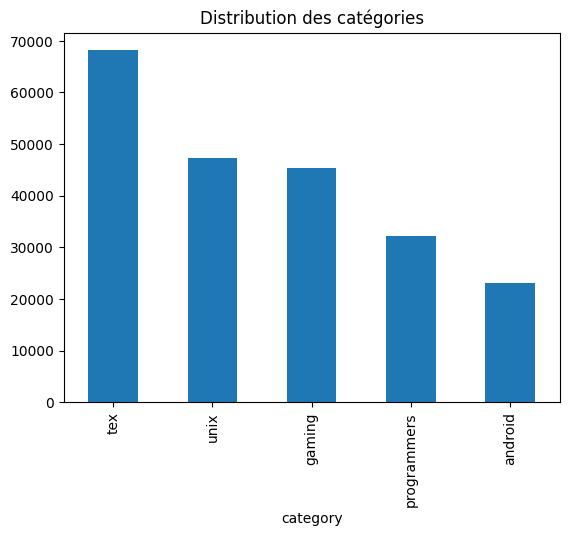

In [ ]:
#distribution of categoru
docs_df["category"].value_counts().plot(kind="bar")
plt.title("Distribution des catégories")
plt.show()

**Tag Statistics:**

Total unique tags (8,449), top 10 most frequent tags, and descriptive statistics of tags per document (Boxplot).

In [ ]:
tags_counts = dict()
for tags in docs_df["tags"]:
 for tag in tags:
  tags_counts[tag] = tags_counts.get(tag, 0) + 1
print(tags_counts.__len__(), "unique tag")
print("Most Frequent Tag :")
Counter(tags_counts).most_common(10)
docs_df["Tag#"] = docs_df["tags"].apply(lambda x: len(x))
docs_df["Tag#"].describe()

8449 unique tag
Most Frequent Tag :


,Tag#
count,216041.000000
mean,2.257215
std,1.140581
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


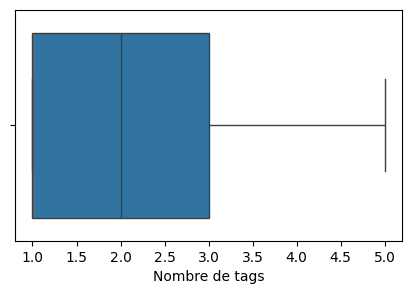

In [ ]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=docs_df["Tag#"])
plt.xlabel("Nombre de tags")
plt.show()

**Data Integrity**:
* Missing Values Count of NAs
* identification of blank strings (e.g., the document with ID 34477 has a blank text field).

In [ ]:
# Count missing values per column
na_counts = docs_df.isna().sum()

# Compute percentage of missing values
na_pct = (na_counts / len(docs_df) * 100).round(2)

# Create a summary table
missing_summary = pd.DataFrame({
    "missing_count": na_counts,
    "missing_pct": na_pct
})

# Sort columns by number of missing values (descending)
missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
id,0,0.0
text,0,0.0
title,0,0.0
tags,0,0.0
category,0,0.0
Tag#,0,0.0


In [ ]:
# --- Small preprocessing step for clean data exploration ---

import re

# Check if a string is empty (after stripping spaces)
def is_blank_str(x):
    return isinstance(x, str) and x.strip() == ""

# Check if text is too short or contains only special characters
def is_quasi_empty_text(x, min_chars=5):
    if not isinstance(x, str):
        return False

    cleaned = x.strip()

    # Text is considered quasi-empty if very short
    if len(cleaned) < min_chars:
        return True

    # Or if it contains only non-alphanumeric characters
    if re.match(r'^\W+$', cleaned):
        return True

    return False

# Validate tags (must be a non-empty list of non-empty strings)
def is_bad_tags(x):
    if not isinstance(x, list):
        return True
    if len(x) == 0:
        return True

    # Clean tags
    cleaned_tags = [t.strip() for t in x if isinstance(t, str)]
    cleaned_tags = [t for t in cleaned_tags if t != ""]

    return len(cleaned_tags) == 0

# Check if text field has invalid type
def is_bad_type_text(x):
    return not isinstance(x, str)


# --- Basic data quality checks on documents ---

blank_title = docs_df["title"].apply(is_blank_str).sum()
blank_text  = docs_df["text"].apply(is_blank_str).sum()

quasi_empty_text = docs_df["text"].apply(is_quasi_empty_text).sum()

empty_or_bad_tags = docs_df["tags"].apply(is_bad_tags).sum()

bad_type_text = docs_df["text"].apply(is_bad_type_text).sum()

empty_categories = docs_df["category"].apply(is_blank_str).sum()

# Display exploration results
print("Blank title:", blank_title)
print("Blank text :", blank_text)
print("Quasi-empty text (short/punct only):", quasi_empty_text)
print("Empty or bad tags:", empty_or_bad_tags)
print("Bad type in text:", bad_type_text)
print("Empty categories :", empty_categories)

Blank title: 0
Blank text : 1
Quasi-empty text (short/punct only): 1
Empty or bad tags: 0
Bad type in text: 0
Empty categories : 0


In [ ]:
blank_text_rows = docs_df[docs_df["text"].apply(is_blank_str)]
print("Blank text rows:")
display(blank_text_rows)

quasi_empty_text_rows = docs_df[docs_df["text"].apply(is_quasi_empty_text)]
print("\nQuasi-empty text rows (short/punct only):")
display(quasi_empty_text_rows)

Blank text rows:


,id,text,title,tags,category,Tag#
34477,12193f6f-c8a8-4d30-9917-5f32cc0c2a31_245,,"Where can I find the ""mutant donkey woman"" horse?",[red-dead-redemption],gaming,1



Quasi-empty text rows (short/punct only):


,id,text,title,tags,category,Tag#
34477,12193f6f-c8a8-4d30-9917-5f32cc0c2a31_245,,"Where can I find the ""mutant donkey woman"" horse?",[red-dead-redemption],gaming,1


In [ ]:
# Install the word2number library (convert written numbers to digits)
!pip install word2number

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=d317ba6597c0bafd9397da8b7864248eded45a6ca6177e9c7d6ef30376c87c91
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number


**Data Preparation for Documents analysis**

For Text:
* Numerical Normalization: Conversion of numbers written in letters to their numerical values.

* Lowercasing: Conversion of all characters to lowercase.

*  Special Character Removal: Stripping out non-alphanumeric characters and symbols.


For Tags:
* Special Character Removal: Elimination of symbols and punctuation within the tags.

* Empty and Duplicate Removal: Deletion of empty tags and removal of redundant entries.

* Tag Sorting: Alphabetical sorting of tags to handle consistency (e.g., "margins, geometry" and "geometry, margins").

In [ ]:
import re
import pandas as pd
from word2number import w2n

# Convert written numbers (e.g., "twenty five") into digits
def replace_num(match):
    try:
        return str(w2n.word_to_num(match.group(0)))
    except:
        # Keep original text if conversion fails
        return match.group(0)

# Clean and normalize text
def clean_text(s):
    if pd.isna(s):
        return ""

    # Convert to lowercase
    s = str(s).lower()

    # Define number word patterns
    units = r"(?:one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|thirteen|fourteen|fifteen|sixteen|seventeen|eighteen|nineteen)"
    tens = r"(?:twenty|thirty|forty|fifty|sixty|seventy|eighty|ninety)"
    scales = r"(?:hundred|thousand|million|billion)"

    num_pattern = rf"\b(?:{units}|{tens}|{scales})(?:[\s\-]|and|{units}|{tens}|{scales})*\b"

    # Replace number words with digits
    s = re.sub(num_pattern, replace_num, s, flags=re.IGNORECASE)

    # Remove special characters (keep letters and digits only)
    s = re.sub(r"[^a-z0-9]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

# Clean and normalize a list of tags
def clean_tags(tags):
    if not isinstance(tags, list):
        return ""

    cleaned = [clean_text(t) for t in tags]  # Clean each tag
    cleaned = [t for t in cleaned if t != ""]  # Remove empty tags
    cleaned = sorted(set(cleaned))  # Remove duplicates and sort

    return " ".join(cleaned)  # Return as a single string

In [ ]:
# Apply text cleaning to document titles
docs_df["title_clean"] = docs_df["title"].apply(clean_text)

# Apply text cleaning to document main text
docs_df["text_clean"] = docs_df["text"].apply(clean_text)

# Apply tag cleaning to document tags
docs_df["tags_clean"] = docs_df["tags"].apply(clean_tags)

In [ ]:
#merging Title, Text, and Tags into  Content_key

#Increasing title importance by tripling its frequency: docs_df["title_clean"]+ " ")*3

docs_df["content_key"] = (
    (docs_df["title_clean"]+ " ")*3 +
    docs_df["text_clean"]  + " " +
    docs_df["tags_clean"]
).str.strip()

**Analysis of Potential Duplicates:**

Duplicate Doc IDs: Multiple records sharing the same unique identifier.

Duplicate Doc Titles: Different documents that have the exact same title.

Duplicate Doc Text: Instances where the body content is identical across different entries.

Duplicate Content Keys: Rows where the combination of Title, Tags, and Text is identical (indicating a 100% semantic match).




In [ ]:
dup_id = docs_df["id"].str.strip().duplicated().sum()
print("Duplicated doc IDs (after stripping spaces):", dup_id)

Duplicated doc IDs (after stripping spaces): 0


In [ ]:
dup_title = docs_df["title_clean"].duplicated().sum()
print("Duplicated doc title:", dup_title)

Duplicated doc title: 115


In [ ]:
#affichage des titres doublés
docs_df[docs_df["title_clean"].duplicated(keep=False)].sort_values("title_clean").head(len(docs_df[docs_df["title_clean"].duplicated(keep=False)]))

,id,text,title,tags,category,Tag#,title_clean,text_clean,tags_clean,content_key
194827,2ddfc7a8-2abe-4460-bdba-326137299df4_82661,I'm facing a problem with ABD connection under...,adb connection problem on Kubuntu 13.04 x64,"[android, kubuntu]",unix,2,adb connection problem on kubuntu 13 04 x64,i m facing a problem with abd connection under...,android kubuntu,adb connection problem on kubuntu 13 04 x64 ad...
178521,24644441-3fb6-49ea-82cf-320d5156209b_48826,I'm facing a problem with ABD connection under...,adb connection problem on Kubuntu 13.04 x64,"[adb, linux]",android,2,adb connection problem on kubuntu 13 04 x64,i m facing a problem with abd connection under...,adb linux,adb connection problem on kubuntu 13 04 x64 ad...
196455,6134a3d2-df51-486e-b41a-e85820ae3ff1_49509,I have my own self-signed SSL certificate for ...,Adding a self-signed certificate to the truste...,"[certificates, https]",android,2,adding a self signed certificate to the truste...,i have my own self signed ssl certificate for ...,certificates https,adding a self signed certificate to the truste...
168797,427c35d6-bb57-495e-8bc6-0cba8ebb0c72_90450,I've generated a self-signed certificate for m...,"Adding a self-signed certificate to the ""trust...",[ssl],unix,1,adding a self signed certificate to the truste...,i ve generated a self signed certificate for m...,ssl,adding a self signed certificate to the truste...
73246,1fdedf98-93eb-4d64-be06-434cbd0e4821_151727,I am trying to align the 2 equals signs and th...,Alignment issue?,"[horizontal-alignment, errors, vertical-alignm...",tex,3,alignment issue,i am trying to align the 2 equals signs and th...,errors horizontal alignment vertical alignment,alignment issue alignment issue alignment issu...
...,...,...,...,...,...,...,...,...,...,...
155999,8232f17d-734d-4420-84fb-fa5369f1425e_82035,I am trying to choose the right license for a ...,Which open-source license is right for my proj...,"[php, open-source, licensing]",programmers,3,which open source license is right for my project,i am trying to choose the right license for a ...,licensing open source php,which open source license is right for my proj...
167259,75783b70-ed3c-4d0d-bd5f-bc0fc01f3d1b_176148,this time I'm writing my Bachelor Thesis on Un...,Wrong Sorting nomenclature and predefined vari...,[nomenclature],tex,1,wrong sorting nomenclature and predefined vari...,this time i m writing my bachelor thesis on un...,nomenclature,wrong sorting nomenclature and predefined vari...
4676,5f4c44eb-814a-4d38-ad21-47c1f0b43bb2_176222,This time I'm writing my Bachelor Thesis on Un...,Wrong Sorting nomenclature and predefined vari...,[nomenclature],tex,1,wrong sorting nomenclature and predefined vari...,this time i m writing my bachelor thesis on un...,nomenclature,wrong sorting nomenclature and predefined vari...
90068,575b4a5c-e093-426b-a165-bf672ddab8eb_82197,Pls help me! I got some error message in TeXni...,You can't use `\eqno' in math mode,[errors],tex,1,you can t use eqno in math mode,pls help me i got some error message in texnic...,errors,you can t use eqno in math mode you can t use ...


In [ ]:
dup_text = docs_df["text_clean"].duplicated().sum()
print("Duplicated doc text:", dup_text)

Duplicated doc text: 39


In [ ]:
#affichage des text doublés
docs_df[docs_df["text_clean"].duplicated(keep=False)].sort_values("text_clean").head(39)

,id,text,title,tags,category,Tag#,title_clean,text_clean,tags_clean,content_key
116371,a1e43c46-4d07-469c-940d-42c0905aff90_110968,After exporting `HISTTIMEFORMAT='%F %T'` I tri...,Changing HISTTIMEFORMAT leaves entries with in...,"[bash, command-history]",unix,2,changing histtimeformat leaves entries with in...,after exporting histtimeformat f t i tried to ...,bash command history,changing histtimeformat leaves entries with in...
105858,89d4a21b-4c94-4d72-9293-fa9672179cd2_87740,After exporting `HISTTIMEFORMAT='%F %T'` I tri...,HISTTIMEFORMAT does not show correct date and ...,"[bash, command-history]",unix,2,histtimeformat does not show correct date and ...,after exporting histtimeformat f t i tried to ...,bash command history,histtimeformat does not show correct date and ...
109726,e5e58a01-c99e-4b25-9c53-e5c1966b6b60_3225,And to what extent does this card have support...,Is the Creative Sound Blaster X-FI Surround 5....,"[linux, audio, drivers]",unix,3,is the creative sound blaster x fi surround 5 ...,and to what extent does this card have support...,audio drivers linux,is the creative sound blaster x fi surround 5 ...
23836,9077fc57-36db-410b-bbec-a39427e4e941_3222,And to what extent does this card have support...,Is the Zalman ZM-RSSC 5.1 USB Sound Card suppo...,[audio],unix,1,is the zalman zm rssc 5 1 usb sound card suppo...,and to what extent does this card have support...,audio,is the zalman zm rssc 5 1 usb sound card suppo...
83411,402b7c74-43c6-4204-8157-286c45b5c6bc_62945,Anyone know of any simple Template for scienti...,Lyx template for scientific paper,"[templates, lyx]",tex,2,lyx template for scientific paper,anyone know of any simple template for scienti...,lyx templates,lyx template for scientific paper lyx template...
86806,7e713eeb-67c1-4c07-9a7d-a1c69d583f26_3669,Anyone know of any simple Template for scienti...,Lyx template for scientific paper,"[pdftex, templates, lyx]",tex,3,lyx template for scientific paper,anyone know of any simple template for scienti...,lyx pdftex templates,lyx template for scientific paper lyx template...
67646,44b7c6c2-417c-4c74-9011-cf66a7ec9629_95865,"Basically, what I did: 1. Copied vmail folde...",Is it possible to import vmail folder from old...,"[ubuntu, email, mysql, postgresql, dovecot]",unix,5,is it possible to import vmail folder from old...,basically what i did 1 copied vmail folder to ...,dovecot email mysql postgresql ubuntu,is it possible to import vmail folder from old...
215013,1cb697bb-a3ac-4a49-ac9c-9ce8bbaebc20_96557,"Basically, what I did: 1. Copied vmail folde...",Is it possible to import vmail folder from old...,"[email, ubuntu, migration, dovecot]",unix,4,is it possible to import vmail folder from old...,basically what i did 1 copied vmail folder to ...,dovecot email migration ubuntu,is it possible to import vmail folder from old...
166677,36adda0d-9b58-43bf-9de8-4ca234090a10_13101,"by standard, i mean just what users often get ...",how do I get most of my standard linux utiliti...,"[applications, linux, 3.1-honeycomb]",android,3,how do i get most of my standard linux utiliti...,by standard i mean just what users often get b...,3 1 honeycomb applications linux,how do i get most of my standard linux utiliti...
28477,3b962d89-4c2d-40e2-88ad-4439e49a9e6f_20109,"By standard, I mean just what users often get ...",How do I get most of my standard Linux utiliti...,"[linux, android]",unix,2,how do i get most of my standard linux utiliti...,by standard i mean just what users often get b...,android linux,how do i get most of my standard linux utiliti...


In [ ]:
dup_content = docs_df["content_key"].duplicated().sum()
print("Duplicated documents (normalized content):", dup_content)

Duplicated documents (normalized content): 4


In [ ]:
duplicates = docs_df[docs_df["content_key"].duplicated(keep=False)]
duplicates[["id", "category", "content_key"]].head(10)

,id,category,content_key
0,6970cbf2-ffff-4c7b-b73d-52524000c232_145427,tex,miktex download failure toptesi tar lzma mikte...
11550,adb7e709-e31b-44af-9b5f-6d8c7f957b22_118893,unix,installing amd radeon hd 7400m series fedora 2...
64762,d66a76a1-e1eb-4664-be39-742cba57fe03_144168,tex,miktex download failure toptesi tar lzma mikte...
86975,64fb0eeb-8e35-49ae-a0c5-fa2f6f7b0e22_62073,android,high frequency noise from headphones when conn...
128238,69e4813f-1098-48e5-981c-70c6593c592b_62130,android,high frequency noise from headphones when conn...
130527,531bc409-badc-4003-916e-d3a935d80703_117112,unix,installing amd radeon hd 7400m series fedora 2...
173695,3ff97c15-6666-4a0d-9ce1-cc17d03ad3f4_19710,tex,how can i set the maximum number of rows in a ...
200577,ddbaf37f-41b3-4e4c-a954-83dde6e68469_52784,tex,how can i set the maximum number of rows in a ...


**Length analysis (number of words) :**

In [ ]:
docs_df["content_raw"] = (
    docs_df["title"].astype(str) + " " +
    docs_df["text"].astype(str)  + " " +
    docs_df["tags"].apply(lambda t: " ".join(sorted(t)))
).str.strip()


docs_df["doc_length_raw"] = docs_df["content_raw"].apply(lambda x: len(str(x).split()))


docs_df["doc_length"] = docs_df["content_key"].apply(lambda x: len(str(x).split()))

print("docs Number:", docs_df.shape[0])

print("\nLength Stat (RAW) :")
print(docs_df["doc_length_raw"].describe())

print("\nLength Stat  (CLEAN) :")
print(docs_df["doc_length"].describe())

docs Number: 216041

Length Stat (RAW) :
count    216041.000000
mean        137.182234
std         146.971431
min           9.000000
25%          64.000000
50%         100.000000
75%         161.000000
max        5256.000000
Name: doc_length_raw, dtype: float64

Length Stat  (CLEAN) :
count    216041.000000
mean        172.896358
std         191.751597
min          15.000000
25%          86.000000
50%         127.000000
75%         197.000000
max        8932.000000
Name: doc_length, dtype: float64


In [ ]:
short_docs = (docs_df["doc_length"] < 50).sum()
medium_docs = ((docs_df["doc_length"] >= 50) & (docs_df["doc_length"] < 200)).sum()
long_docs = (docs_df["doc_length"] >= 200).sum()

print("\nDistribution by size :")
print("Short documents (<50 words) :", short_docs)
print("Medium documents (50-200 words) :", medium_docs)
print("Long documents (>200 words) :", long_docs)


Distribution by size :
Short documents (<50 words) : 7353
Medium documents (50-200 words) : 155859
Long documents (>200 words) : 52829


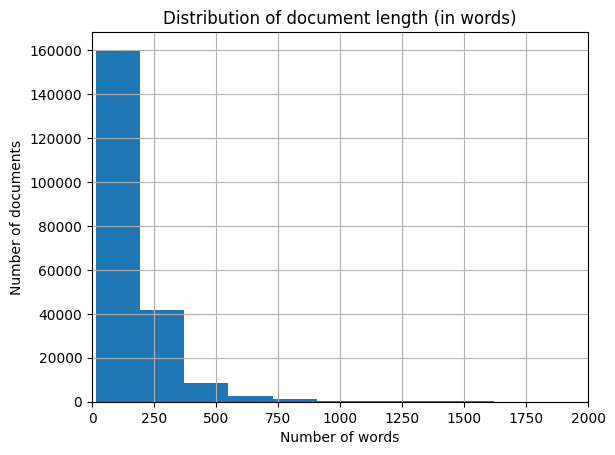

In [ ]:


plt.figure()
docs_df["doc_length"].hist(bins=50)
plt.xlim(0, 2000)
plt.title("Distribution of document length (in words)")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

In [ ]:
# top 5 plus longs
docs_df.sort_values("doc_length", ascending=False).head(5)[
    ["id", "doc_length", "category"]
]

,id,doc_length,category
107453,b2dab658-08dc-4af3-8edf-e05142a71592_82295,8909,tex
38602,061d2c60-30eb-4683-8d9f-f9ae06324873_166854,8501,tex
190322,ffcde7de-c243-40e7-8efc-97116860e0d4_28739,6028,unix
35756,7f7399cb-3c1b-497a-bc51-c2ff8a828f0a_150066,5512,tex
108632,5085a430-e486-4c70-9919-104598fda909_24973,5451,unix


In [ ]:
#top 5 plus courts
docs_df.sort_values("doc_length", ascending=True).head(5)[
    ["id", "doc_length", "category"]
]

,id,doc_length,category
136317,e0dabfc7-cfb6-43ea-b6d8-3c8895666d77_28549,9,tex
135963,268abc0b-4645-4101-a3b3-745d6d97d361_5910,11,unix
171528,1058c223-1889-4fcd-bc2e-398a0c7bd469_10482,11,gaming
201662,36d6d1b3-cbdf-42a6-897b-a4f4b78cebea_642,11,gaming
27907,850c2934-833c-4baf-916f-745a2b4bb482_16239,11,android


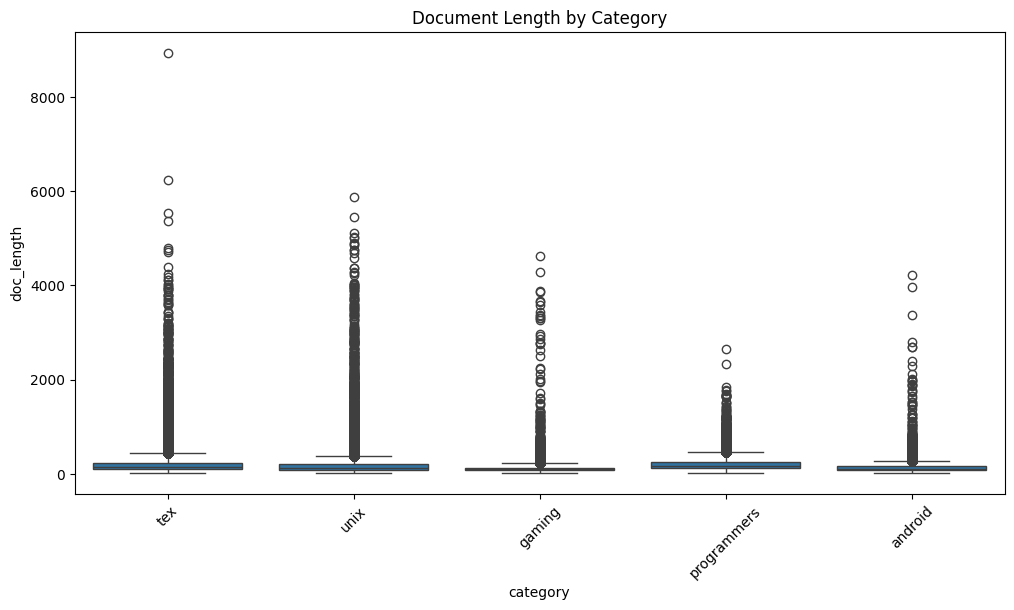

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="category", y="doc_length", data=docs_df)
plt.xticks(rotation=45)
plt.title("Document Length by Category")
plt.show()

In [ ]:
Q1 = docs_df["doc_length"].quantile(0.25)
Q3 = docs_df["doc_length"].quantile(0.75)
IQR = Q3 - Q1

outliers = docs_df[docs_df["doc_length"] > Q3 + 1.5 * IQR]

print("Nombre de documents outliers :", len(outliers))
outliers[["id", "doc_length"]].head()


Nombre de documents outliers : 14800


,id,doc_length
6,b25af998-bcb1-4988-93a7-0eb06f6781ce_113704,654
23,72c5b815-261e-4e3d-8238-b36f2470c142_81766,393
30,32f70c9b-feba-40e4-af1f-1c323a3d8c35_62230,708
35,024e2ca7-2df5-4580-9927-a38dd25a6234_151011,554
60,af07f4bd-743e-4e47-a560-65de82448afb_146927,413


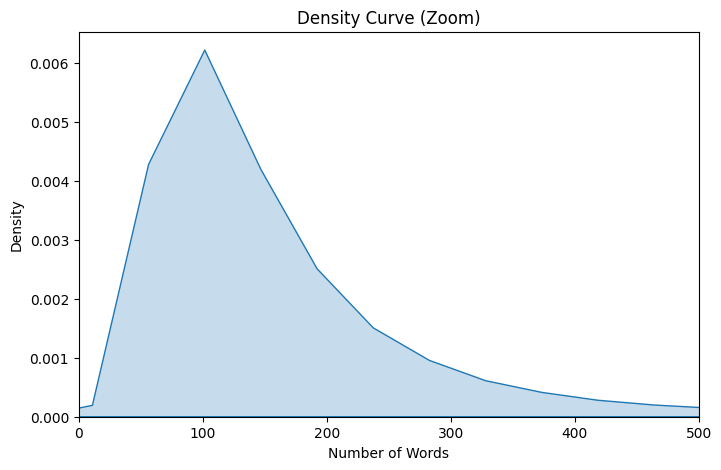

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(docs_df["doc_length"], fill=True)

plt.xlim(0, 500)  # zoom
plt.title("Density Curve (Zoom)")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.show()

### 1.2 Train Queries (train_queries.json)

**Overview:**

Shape (327 queries) and category distribution

In [ ]:
print("Shape:", train_queries_df.shape)
train_queries_df.head(10)

Shape: (327, 5)


,id,text,title,tags,category
0,961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878,Want to try reformatting Damaged SD Card,,"[linux, development]",android
1,4008ed78-e66e-4d89-9c3b-c79bd1cf6fc9_366,"Convince grep to output all lines, not just th...",,"[shell, virtualization, storage, cluster]",unix
2,d5a95b09-e8ea-44dd-993d-347ed418e1f1_15138,How can I automatically reject some types of c...,,"[linux, development]",android
3,3e66798a-b7fd-41b5-8bc0-33b3d7ce2aca_177487,Left and right braces on different lines of align,,"[tikz-pgf, horizontal-alignment, tikz-trees]",tex
4,f5f944d2-277a-481d-ab09-612890402ded_137489,How do you get the purple shark fin?,,[skyrim],gaming
5,da11c342-a2b4-442b-a95a-b2c26f78bf7a_194764,Highlighting labels of undefined citations?,,"[tikz-pgf, horizontal-alignment, tikz-trees]",tex
6,980c09bc-14a0-4832-ad0b-ac1a79ca51cd_55670,\href without decoration (no underline),,"[tikz-pgf, horizontal-alignment, tikz-trees]",tex
7,e655782b-869d-4d80-9513-fda43a2bbf84_54069,"Rooting - how to, and what are the consequence...",,"[linux, development]",android
8,cc1235a9-a603-4891-8474-6cc0a860f159_84759,Which PDF viewers for Linux support Beamer's s...,,"[tikz-pgf, horizontal-alignment, tikz-trees]",tex
9,534caa94-be3a-4a61-b39e-5319f0f9425c_28551,Why can't android connect to an ad hoc hotspot?,,"[linux, development]",android


In [ ]:
train_queries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        327 non-null    object
 1   text      327 non-null    object
 2   title     327 non-null    object
 3   tags      327 non-null    object
 4   category  327 non-null    object
dtypes: object(5)
memory usage: 12.9+ KB


In [ ]:
print("Total number of categories :", train_queries_df["category"].nunique())
print("List of categories :", train_queries_df["category"].unique())

Total number of categories : 5
List of categories : ['android' 'unix' 'tex' 'gaming' 'programmers']


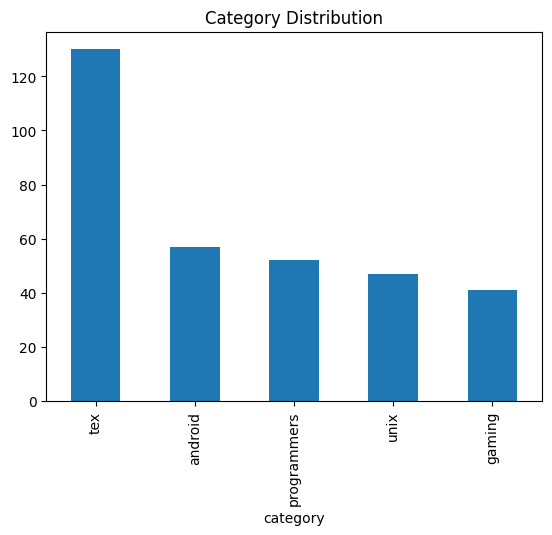

In [ ]:
train_queries_df["category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.show()

**Tag Analysis:**

Statistics of unique tags (only 15 for queries) and distribution of tags per query.

In [ ]:
tags_countsq = dict()
for tags in train_queries_df["tags"]:
 for tag in tags:
  tags_countsq[tag] = tags_countsq.get(tag, 0) + 1

print(tags_countsq.__len__(), "unique tag")
print("Top 10 most frequent tags :")
Counter(tags_countsq).most_common(10)

15 unique tag
Top 10 most frequent tags :


[('tikz-pgf', 130),
 ('horizontal-alignment', 130),
 ('tikz-trees', 130),
 ('linux', 57),
 ('development', 57),
 ('web-development', 52),
 ('python', 52),
 ('sql', 52),
 ('concurrency', 52),
 ('sqlite', 52)]

In [ ]:
train_queries_df["Tag#"] = train_queries_df["tags"].apply(lambda x: len(x))
train_queries_df["Tag#"].describe()

,Tag#
count,327.000000
mean,3.036697
std,1.207796
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


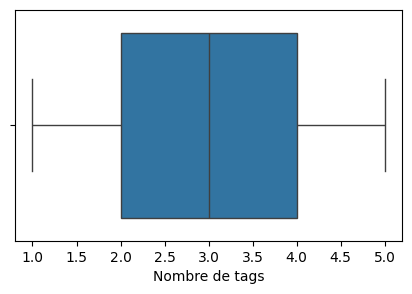

In [ ]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=train_queries_df["Tag#"])
plt.xlabel("Nombre de tags")
plt.show()

In [ ]:
na_countsq = train_queries_df.isna().sum()
na_pctq = (na_countsq / len(train_queries_df) * 100).round(2)
missing_summaryq = pd.DataFrame({"missing_count": na_countsq, "missing_pct": na_pctq})
missing_summaryq.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
id,0,0.0
text,0,0.0
title,0,0.0
tags,0,0.0
category,0,0.0
Tag#,0,0.0


**Data Integrity:**

Check for NAs, blank titles, and potential duplicates.

In [ ]:
blank_titleq = train_queries_df["title"].apply(is_blank_str).sum()
blank_textq  = train_queries_df["text"].apply(is_blank_str).sum()

quasi_empty_textq = train_queries_df["text"].apply(is_quasi_empty_text).sum()



empty_or_bad_tagsq = train_queries_df["tags"].apply(is_bad_tags).sum()

bad_type_textq = train_queries_df["text"].apply(is_bad_type_text).sum()

empty_categoriesq = train_queries_df["category"].apply(is_blank_str).sum()


print("Blank title:", blank_titleq)
print("Blank text :", blank_textq)
print("Quasi-empty text (short/punct only):", quasi_empty_textq)
print("Empty or bad tags:", empty_or_bad_tagsq)
print("Bad type in text:", bad_type_textq)
print("Empty categories :", empty_categoriesq)

Blank title: 327
Blank text : 0
Quasi-empty text (short/punct only): 0
Empty or bad tags: 0
Bad type in text: 0
Empty categories : 0


In [ ]:


train_queries_df["title_clean"] = train_queries_df["title"].apply(clean_text)

# Apply text cleaning to document main text
train_queries_df["text_clean"] = train_queries_df["text"].apply(clean_text)

# Apply tag cleaning to document tags
train_queries_df["tags_clean"] = train_queries_df["tags"].apply(clean_tags)


train_queries_df["content_key"] = (
    (train_queries_df["title_clean"] + " ") * 3 +   # Boost title weight
    train_queries_df["text_clean"] + " " +          # Add main text
    train_queries_df["tags_clean"]                  # Add tags
).str.strip()  # Remove extra spaces



dup_id_q = train_queries_df["id"].str.strip().duplicated().sum()
print("Duplicated doc IDs (after stripping spaces):", dup_id_q)
dup_text_q = train_queries_df["text_clean"].duplicated().sum()
print("Duplicated doc text:", dup_text_q)
dup_content_q = train_queries_df["content_key"].duplicated().sum()
print("Duplicated documents (normalized content):", dup_content_q)
train_queries_df["train_query_length"] = train_queries_df["content_key"].apply(lambda x: len(x.split())) #split en mots


Duplicated doc IDs (after stripping spaces): 0
Duplicated doc text: 0
Duplicated documents (normalized content): 0


**Length analysis :**

In [ ]:
train_queries_df["content_raw"] = (
    train_queries_df["title"].fillna("").astype(str) + " " +
    train_queries_df["text"].fillna("").astype(str)  + " " +
    train_queries_df["tags"].apply(lambda t: " ".join(t) if isinstance(t, list) else "")
).str.strip()

train_queries_df["train_length_raw"] = train_queries_df["content_raw"].apply(lambda x: len(str(x).split()))


print("Total number of queries :", train_queries_df.shape[0])

print("\nLength Statistics (RAW) :")
print(train_queries_df["train_query_length"].describe())

print("\nLength Statistics (CLEAN) :")
print(train_queries_df["train_query_length"].describe())

Total number of queries : 327

Length Statistics (RAW) :
count    327.000000
mean      12.899083
std        4.016710
min        3.000000
25%       10.000000
50%       12.000000
75%       15.000000
max       32.000000
Name: train_query_length, dtype: float64

Length Statistics (CLEAN) :
count    327.000000
mean      12.899083
std        4.016710
min        3.000000
25%       10.000000
50%       12.000000
75%       15.000000
max       32.000000
Name: train_query_length, dtype: float64


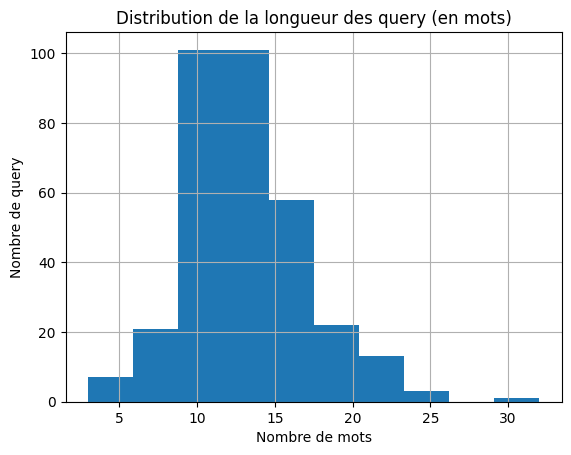

In [ ]:
plt.figure()
train_queries_df["train_query_length"].hist(bins=10)
plt.title("Distribution de la longueur des query (en mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de query")
plt.show()

In [ ]:
#top 5 plus longs
train_queries_df.sort_values("train_query_length", ascending=False).head(5)[
    ["id", "train_query_length", "category"]
]

,id,train_query_length,category
128,14407185-5f1f-461d-8921-205f00c5cce7_211678,32,programmers
162,be509f2b-24ea-4ad2-8fa2-3c1261747ece_20653,26,programmers
180,96c242d4-dd2d-45b5-9706-4b741a31bb09_102552,25,tex
92,a9ad41a3-0147-424f-8a8f-a79feda99f5f_78501,24,unix
216,c4f18ca1-77f0-498e-9078-c657488270c2_98654,23,tex


In [ ]:
#top 5 plus courts
train_queries_df.sort_values("train_query_length", ascending=True).head(5)[
    ["id", "train_query_length", "category"]
]

,id,train_query_length,category
149,3617f665-9e52-4490-b8ac-031c71983732_160548,3,gaming
47,47d3232f-f7ec-4e71-a97f-942bc4cd2b7a_120032,4,gaming
154,769e411a-d0c0-4789-9a18-603bf01c6079_148895,4,gaming
24,55e9aab1-4705-44dc-9ce6-a9d9e8ffca3b_102361,5,gaming
134,a705a67a-f608-448d-9c76-772304c24f81_54068,5,gaming


In [ ]:
train_queries_df.sort_values("train_query_length", ascending=True).head(10)[["id", "train_query_length", "category", "text_clean", "tags_clean"]]

,id,train_query_length,category,text_clean,tags_clean
149,3617f665-9e52-4490-b8ac-031c71983732_160548,3,gaming,minecraft multiplayer,skyrim
47,47d3232f-f7ec-4e71-a97f-942bc4cd2b7a_120032,4,gaming,true vault huntermode,skyrim
154,769e411a-d0c0-4789-9a18-603bf01c6079_148895,4,gaming,redirecting nether portals,skyrim
134,a705a67a-f608-448d-9c76-772304c24f81_54068,5,gaming,point of no return,skyrim
146,6e78e67a-764b-48cf-b31d-dc6bc4153d84_87004,5,gaming,help with item stats,skyrim
24,55e9aab1-4705-44dc-9ce6-a9d9e8ffca3b_102361,5,gaming,diablo 3 monster curses,skyrim
106,da6c3298-b9a0-47d8-98ca-3ce2846fe2b0_82179,5,android,charging related question,development linux
202,71c6f22c-4b16-4b5e-af85-1885c716b892_161568,6,gaming,importing games back into steam,skyrim
224,e5603ca2-4cf8-4710-86a9-331bb1a9185d_21311,6,gaming,starting in world of warcraft,skyrim
41,0a490233-6a3a-4f2e-b61e-4260abfcb4c4_77444,6,android,bluetooth headset using android,development linux


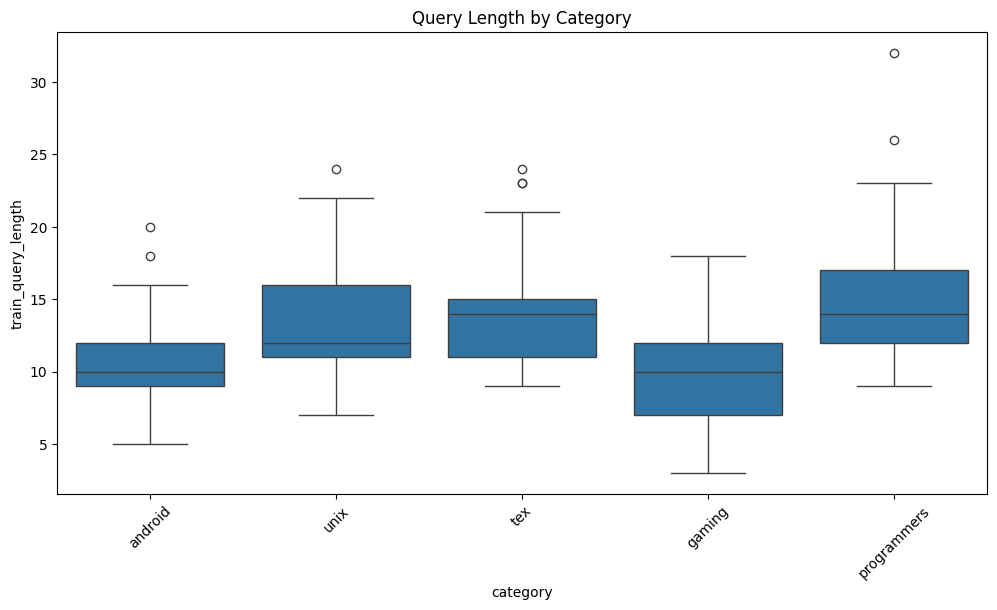

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x="category", y="train_query_length", data=train_queries_df)
plt.xticks(rotation=45)
plt.title("Query Length by Category")
plt.show()

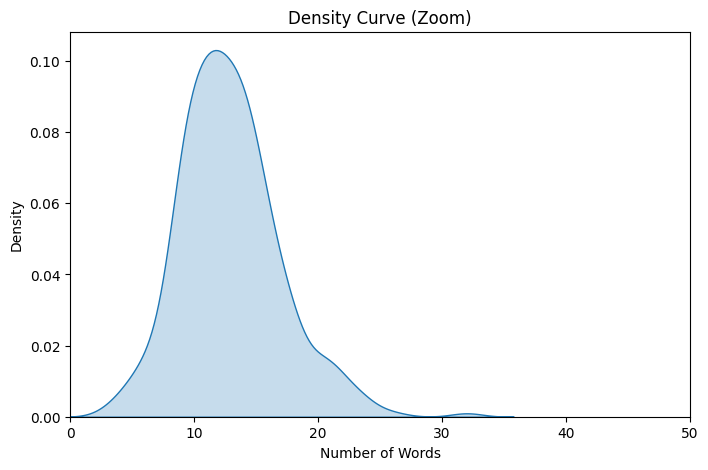

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(train_queries_df["train_query_length"], fill=True)

plt.xlim(0, 50)
plt.title("Density Curve (Zoom)")
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.show()

### 1.3 Test Queries (test_queries.json)


**Overview:**

Shape (141 queries) and verification of schema similarity with training queries.


In [ ]:
print("Shape:", test_queries_df.shape)
test_queries_df.head(10)

Shape: (141, 4)


,id,text,title,tags
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,Why use an interface when the class can direct...,,"[web-development, python, sql, concurrency, sq..."
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,Linux isn't sure whether a file exists or not,,"[shell, virtualization, storage, cluster]"
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,Will my Android device change to Gingerbread w...,,"[linux, development]"
3,cb216e47-add6-41fd-974a-39251e4df3aa_6777,How to clean up file extensions?,,"[shell, virtualization, storage, cluster]"
4,14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748,Cancelling in a Fraction,,"[tikz-pgf, horizontal-alignment, tikz-trees]"
5,9ceab16a-79cf-4523-8846-ef2f9bbf2aad_40876,"How to get rid of the ""In:"" prefix in some bib...",,"[tikz-pgf, horizontal-alignment, tikz-trees]"
6,6ca71ddc-5bbf-4643-b789-6b5401e7673f_16078,How to force Gmail/Android to request password...,,"[linux, development]"
7,4b5622f5-566f-4dfa-b83a-f1b646381c06_186377,Developers taking code home - how bad is it?,,"[web-development, python, sql, concurrency, sq..."
8,009b1511-1254-4ee9-b697-f219d2c0bf4a_111002,What's the difference between $$ $$ and \begin...,,"[tikz-pgf, horizontal-alignment, tikz-trees]"
9,6cb18019-528d-4b41-ba49-1d92e4edbab2_9944,What is the difference between software engine...,,"[web-development, python, sql, concurrency, sq..."


In [ ]:
test_queries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      141 non-null    object
 1   text    141 non-null    object
 2   title   141 non-null    object
 3   tags    141 non-null    object
dtypes: object(4)
memory usage: 4.5+ KB


**Tag Statistics:**
Statistics of unique tags (only 15 for queries) and distribution of tags per query.

In [ ]:
tags_countst = dict()
for tags in test_queries_df["tags"]:
 for tag in tags:
  tags_countst[tag] = tags_countst.get(tag, 0) + 1

print(tags_countst.__len__(), "tags uniques")
print("Top 10 tags les plus fréquents :")
Counter(tags_countst).most_common(10)

15 tags uniques
Top 10 tags les plus fréquents :


[('tikz-pgf', 68),
 ('horizontal-alignment', 68),
 ('tikz-trees', 68),
 ('linux', 23),
 ('development', 23),
 ('shell', 19),
 ('virtualization', 19),
 ('storage', 19),
 ('cluster', 19),
 ('web-development', 17)]

In [ ]:
test_queries_df["Tag#"] = test_queries_df["tags"].apply(lambda x: len(x))
test_queries_df["Tag#"].describe()

,Tag#
count,141.000000
mean,3.014184
std,1.088812
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


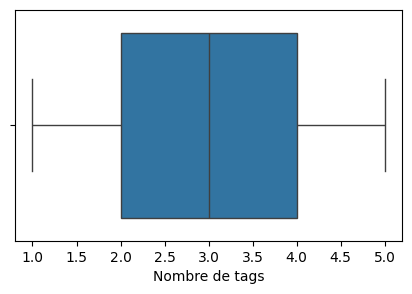

In [ ]:
plt.figure(figsize=(5, 3))
sns.boxplot(x=test_queries_df["Tag#"])
plt.xlabel("Nombre de tags")
plt.show()

**Data Integrity:**

Check for NAs, blank titles, and potential duplicates

In [ ]:
na_countst = test_queries_df.isna().sum()
na_pctt = (na_countst / len(test_queries_df) * 100).round(2)
missing_summaryt = pd.DataFrame({"missing_count": na_countst, "missing_pct": na_pctt})
missing_summaryt.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
id,0,0.0
text,0,0.0
title,0,0.0
tags,0,0.0
Tag#,0,0.0


In [ ]:
blank_titlet = test_queries_df["title"].apply(is_blank_str).sum()
blank_textt  = test_queries_df["text"].apply(is_blank_str).sum()

quasi_empty_textt = test_queries_df["text"].apply(is_quasi_empty_text).sum()

empty_or_bad_tagst = test_queries_df["tags"].apply(is_bad_tags).sum()

bad_type_textt = test_queries_df["text"].apply(is_bad_type_text).sum()


print("Blank title:", blank_titlet)
print("Blank text :", blank_textt)
print("Quasi-empty text (short/punct only):", quasi_empty_textt)
print("Empty or bad tags:", empty_or_bad_tagst)
print("Bad type in text:", bad_type_textt)

Blank title: 141
Blank text : 0
Quasi-empty text (short/punct only): 0
Empty or bad tags: 0
Bad type in text: 0


**Length analysis:**

In [ ]:

test_queries_df["title_clean"] = test_queries_df["title"].apply(clean_text)

# Apply text cleaning to document main text
test_queries_df["text_clean"] = test_queries_df["text"].apply(clean_text)

# Apply tag cleaning to document tags
test_queries_df["tags_clean"] = test_queries_df["tags"].apply(clean_tags)


test_queries_df["content_key"] = (
    (test_queries_df["title_clean"] + " ") * 3 +   # Boost title weight
    test_queries_df["text_clean"] + " " +          # Add main text
    test_queries_df["tags_clean"]                  # Add tags
).str.strip()  # Remove extra spaces



test_queries_df["test_query_length"] = test_queries_df["content_key"].apply(lambda x: len(x.split())-2)

In [ ]:
print("\nStats test query lenghth :")
print(test_queries_df["test_query_length"].describe())


Stats test query lenghth :
count    141.000000
mean      11.070922
std        4.302234
min        1.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       25.000000
Name: test_query_length, dtype: float64


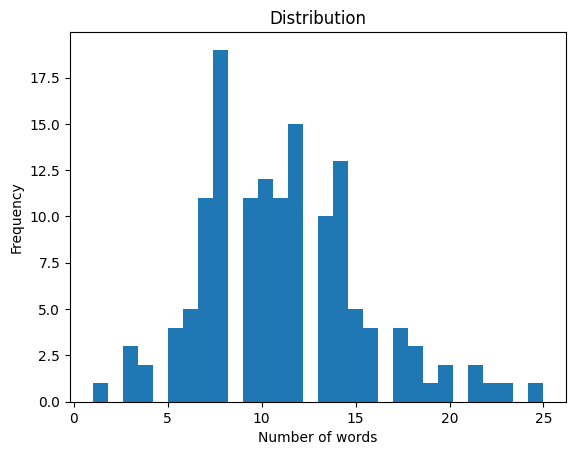

In [ ]:
plt.hist(test_queries_df["test_query_length"], bins=30)
plt.title("Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#top 5 plus longs
test_queries_df.sort_values("test_query_length", ascending=False).head(5)[
    ["id", "test_query_length", "text_clean", "tags_clean"]
]

,id,test_query_length,text_clean,tags_clean
94,de3ebf94-4fd4-4c40-8fef-93e8b0ed1a3c_3955,27,is there a site where i can enter a latex expr...,horizontal alignment tikz pgf tikz trees
67,efd261f9-6aee-426e-a111-503120b649e6_82227,25,programming practice - is there a site that ha...,concurrency python sql sqlite web development
56,328b6d12-6289-46ec-b6c0-6be446e12d74_42934,25,is there a package for segmenting a large tex ...,horizontal alignment tikz pgf tikz trees
84,34fd1c44-93e0-45cd-8bed-7fc6bec4de81_111881,23,how much do i need to learn in order to get an...,concurrency python sql sqlite web development
114,8de9bb65-94c4-4321-bf7d-45bde732c59f_195456,23,what is the latex command or package that allo...,horizontal alignment tikz pgf tikz trees


In [ ]:
#top 5 plus courts
test_queries_df.sort_values("test_query_length", ascending=True).head(5)[
    ["id", "test_query_length", "text_clean", "tags_clean"]
]

,id,test_query_length,text_clean,tags_clean
32,21e8deec-77b4-429e-8129-6b4ac59d85ea_183174,3,mod installation,skyrim
57,69d3418a-c3c8-47d6-ab04-a9e1be9ce5a2_147878,5,follower missing in skyrim,skyrim
132,5961d629-54e6-4082-a5fb-6fcf35a06a1b_75755,5,android play store,development linux
135,2496e470-68f6-4d9f-b2dc-4526d72af391_26238,5,sms thread retrieval,development linux
52,b13578bd-e1f5-4aab-bdc2-1bf84b0ea1d2_137211,6,what use are chocolate bars,skyrim


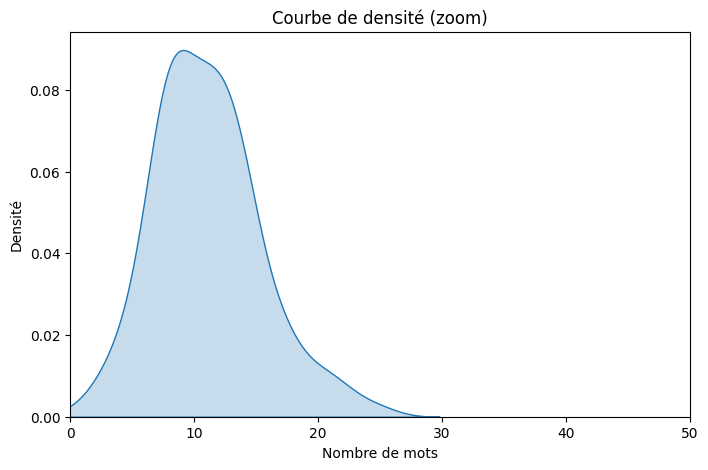

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(test_queries_df["test_query_length"], fill=True)

plt.xlim(0, 50)
plt.title("Courbe de densité (zoom)")
plt.xlabel("Nombre de mots")
plt.ylabel("Densité")
plt.show()


After analysis, we can conclude that train and test queries are similar.

It is important to note that our exploration of the test queries is strictly limited to
verifying the similarity between the two datasets.

We do not use any information from queries_test.json for model training or hyperparameter tuning, as this would result
in Data Leakage.

###1.4 Ground Truth (qgts_train.json)

**Overview and basic stats :**
- Shape (327 items)
- number of document relevant per query

In [ ]:
# Aperçu global
print("Shape:", gts_df.shape)
gts_df.head(10) #10 premiéres lignes

Shape: (3, 327)


,961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878,4008ed78-e66e-4d89-9c3b-c79bd1cf6fc9_366,d5a95b09-e8ea-44dd-993d-347ed418e1f1_15138,3e66798a-b7fd-41b5-8bc0-33b3d7ce2aca_177487,f5f944d2-277a-481d-ab09-612890402ded_137489,da11c342-a2b4-442b-a95a-b2c26f78bf7a_194764,980c09bc-14a0-4832-ad0b-ac1a79ca51cd_55670,e655782b-869d-4d80-9513-fda43a2bbf84_54069,cc1235a9-a603-4891-8474-6cc0a860f159_84759,534caa94-be3a-4a61-b39e-5319f0f9425c_28551,...,cbd9045d-9abb-4103-9b45-64678a9b9262_185783,553912ab-4932-4d42-a047-b68aa507ee73_104362,1ed89f09-9d35-4668-8e05-7ffa10d0bd6c_206755,f73b0a9e-63c1-44cd-b36f-b41b696d4131_37581,46cddbe6-646c-4845-a699-7cdfe3b21721_65261,6f98ccbb-db6f-4646-ac1e-08d8d8bda71a_247103,345e8385-635c-44ab-abd1-f9fbcccaf774_159755,c38ac583-a824-46d9-ad00-105571c0c8fa_120087,3ed0fa3e-af7c-40b2-b44e-bf16de45051e_7772,7878104c-6dfa-42fe-badd-8fc53b2314ac_163896
total_relevant_docs,4,5,4,15,6,4,9,8,4,5,...,4,7,5,11,5,4,5,5,5,4
relevant_doc_ids,[{'doc_id': '135f5fdb-bcba-40b8-b90d-823617f1e...,[{'doc_id': 'ada9aadc-7371-450f-b610-9c1b40c8b...,[{'doc_id': 'ed189b8f-e6fe-42e3-b326-333b86d97...,[{'doc_id': 'a98df142-fd9e-4aad-a9c4-a334262e9...,[{'doc_id': '77294dfe-cbbb-4802-99ef-b86c2bd63...,[{'doc_id': '4016915f-5aee-4b97-94a0-02e998db6...,[{'doc_id': '0b4c1ceb-1a07-48d4-a555-f76e24058...,[{'doc_id': '124064f8-0dcf-4034-868d-2b16055ac...,[{'doc_id': '7bdf2f89-f3ab-4240-95d4-4616fe913...,[{'doc_id': '7b8283aa-a41e-41f9-bf7d-901ce326a...,...,[{'doc_id': '351d1ced-dc50-4e4f-90de-0d2684e64...,[{'doc_id': 'd770f2ef-2570-4b43-ae4b-75a99500d...,[{'doc_id': '28332c8d-5d96-4877-8429-d602a3735...,[{'doc_id': '6b4c155c-80d7-4203-9e62-e65f67aa2...,[{'doc_id': '99d38d5a-2d11-4ec2-b443-442e0d0eb...,[{'doc_id': '7ae6f7f5-b4ca-477a-b71e-8a8ae204c...,[{'doc_id': '142b4234-ce1b-4ba3-bc89-de7a57105...,[{'doc_id': 'f4dde969-74fc-4401-848d-ac1c906f7...,[{'doc_id': '43e3229a-7db0-423a-8557-10aabb32e...,[{'doc_id': '849eb92b-1401-430a-86ef-9fdfb09e2...
category,android,unix,android,tex,gaming,tex,tex,android,tex,android,...,tex,gaming,programmers,tex,android,programmers,tex,gaming,unix,gaming


In [ ]:
print("Number of docments in gts :", gts_df.shape[1])

Number of docments in gts : 327


In [ ]:
relevant_counts = gts_df.loc["total_relevant_docs"]
print(relevant_counts.head())

961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878      4
4008ed78-e66e-4d89-9c3b-c79bd1cf6fc9_366        5
d5a95b09-e8ea-44dd-993d-347ed418e1f1_15138      4
3e66798a-b7fd-41b5-8bc0-33b3d7ce2aca_177487    15
f5f944d2-277a-481d-ab09-612890402ded_137489     6
Name: total_relevant_docs, dtype: object


In [ ]:
print("Statistiques nombre de documents pertinents par query :")
print(relevant_counts.describe())

Statistiques nombre de documents pertinents par query :
count     327
unique     31
top         4
freq      118
Name: total_relevant_docs, dtype: int64


In [ ]:
print("Nombre total de queries :", relevant_counts.count())
print("Minimum docs pertinents :", relevant_counts.min())
print("Maximum docs pertinents :", relevant_counts.max())
print("Moyenne :", relevant_counts.mean())
print("Médiane :", relevant_counts.median())

print("Queries avec 1 doc pertinent :", (relevant_counts == 1).sum())
print("Queries avec 0 doc pertinent :", (relevant_counts == 0).sum())
print("Queries avec >10 docs pertinents :", (relevant_counts > 10).sum())

Nombre total de queries : 327
Minimum docs pertinents : 4
Maximum docs pertinents : 262
Moyenne : 9.082568807339449
Médiane : 5.0
Queries avec 1 doc pertinent : 0
Queries avec 0 doc pertinent : 0
Queries avec >10 docs pertinents : 50


In [ ]:

print("Querry with most docs :")
print(relevant_counts.sort_values(ascending=False).head(10))

Querry with most docs :
49d7dae2-44cf-433f-beaf-b399905b27db_19971     262
6e3570f7-a217-4ece-a58a-ba973460c3aa_3747      149
69277e6f-e701-4859-aa63-54c6f18658ad_279       139
dba66105-2d70-4dd0-84c1-170cdb458cdb_44220      53
3a37f860-64bd-466b-a0b3-e98620382fff_168547     43
441f6e89-f077-42c1-a809-a608a3e05f1b_12834      42
0015b462-21fb-4413-97a6-30f13f879691_47598      40
cb347760-0693-41ca-9b9f-fe8a7834a027_56848      32
8a7889e0-b89f-4f6a-b984-f4d271a26c1c_82993      32
641962a5-c4a5-42b1-b7b6-16b9e34fc7fa_150072     30
Name: total_relevant_docs, dtype: object


**Distribution of relevant documents per querry**

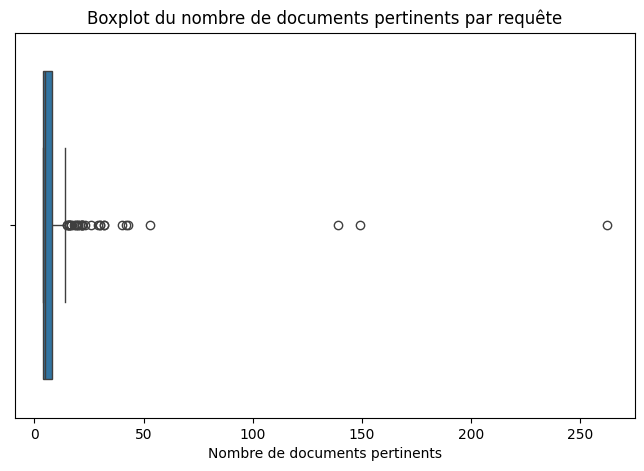

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=relevant_counts.astype(int))
plt.title("Boxplot du nombre de documents pertinents par requête")
plt.xlabel("Nombre de documents pertinents")
plt.show()

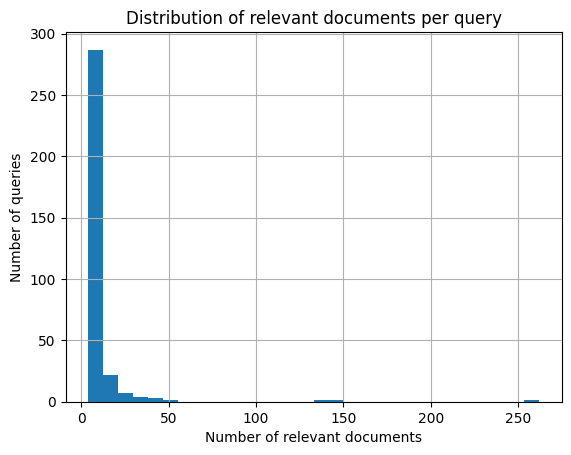

In [ ]:
plt.figure()
relevant_counts.hist(bins=30)
plt.title("Distribution of relevant documents per query")
plt.xlabel("Number of relevant documents")
plt.ylabel("Number of queries")
plt.show()

In [ ]:
categories_gts = gts_df.loc['category']
print("Category Number :", categories_gts.nunique())
print("Category List :", categories_gts.unique())

Category Number : 5
Category List : ['android' 'unix' 'tex' 'gaming' 'programmers']


In [ ]:
print("Category distribution By Querry :")
print(categories_gts.value_counts())

Category distribution By Querry :
category
tex            130
android         57
programmers     52
unix            47
gaming          41
Name: count, dtype: int64


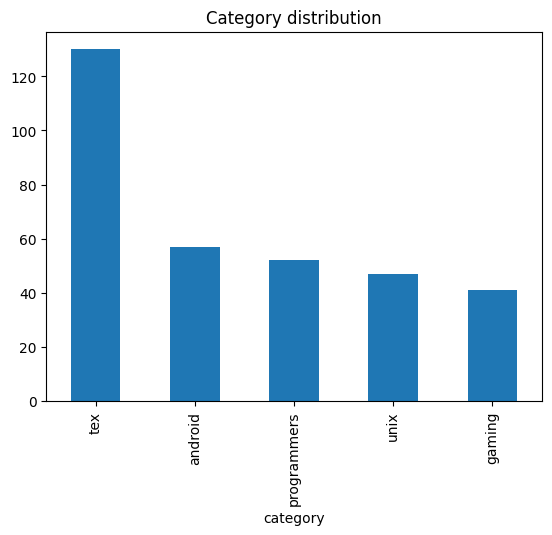

In [ ]:
categories_gts.value_counts().plot(kind="bar")
plt.title("Category distribution")
plt.show()

In [ ]:
analysis_df = pd.DataFrame({
    "num_relevant": relevant_counts,
    "category": categories_gts
})

print(analysis_df.groupby("category")["num_relevant"].describe())

             count  unique  top  freq
category                             
android         57      14    4    21
gaming          41      10    4    16
programmers     52      14    4    14
tex            130      21    4    48
unix            47      10    4    19


In [ ]:
# Vérifier les NaN spécifiquement dans les lignes 'category' et 'relevant_doc_ids'
nan_in_category = gts_df.loc['category'].isna().sum()
nan_in_relevant_doc_ids = gts_df.loc['relevant_doc_ids'].isna().sum()
print(f"NaNs dans la ligne 'category': {nan_in_category}")
print(f"NaNs dans la ligne 'relevant_doc_ids': {nan_in_relevant_doc_ids}")

# Vérifier les chaînes vides dans la ligne 'category'
empty_category_entries = gts_df.loc['category'].apply(lambda x: isinstance(x, str) and x.strip() == "").sum()
print(f"Chaînes vides dans la ligne 'category': {empty_category_entries}")

# Vérifier les listes vides dans la ligne 'relevant_doc_ids'
empty_relevant_doc_ids_entries = gts_df.loc['relevant_doc_ids'].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f"Listes vides dans la ligne 'relevant_doc_ids': {empty_relevant_doc_ids_entries}")

NaNs dans la ligne 'category': 0
NaNs dans la ligne 'relevant_doc_ids': 0
Chaînes vides dans la ligne 'category': 0
Listes vides dans la ligne 'relevant_doc_ids': 0


In [ ]:
# Vérifier les doublons dans les IDs de requête (noms des colonnes)
dup_query_ids_gts = gts_df.columns.duplicated().sum()
print(f"Nombre d'IDs de requête dupliqués dans gts_df : {dup_query_ids_gts}")


Nombre d'IDs de requête dupliqués dans gts_df : 0


###1.5 Data Preparation

Before entering our data into the model, we process the data in order to optimise our results when entering them into the models.

In [ ]:
# Check if a value is an empty string (after removing spaces)
def is_blank_str(x):
    return isinstance(x, str) and x.strip() == ""


# Check if text is too short or contains only non-alphanumeric characters
def is_quasi_empty_text(x, min_chars=5):
    if not isinstance(x, str):
        return False

    cleaned = x.strip()

    # Consider text empty if it is shorter than the minimum length
    if len(cleaned) < min_chars:
        return True

    # Consider text empty if it contains only special characters
    if re.match(r'^\W+$', cleaned):
        return True

    return False


# Validate tags: must be a non-empty list of non-empty strings
def is_bad_tags(x):

    if not isinstance(x, list):
        return True
    if len(x) == 0:
        return True

    # Remove invalid or empty tags
    cleaned_tags = [t.strip() for t in x if isinstance(t, str)]
    cleaned_tags = [t for t in cleaned_tags if t != ""]

    return len(cleaned_tags) == 0


# Check if the value is not a valid text string
def is_bad_type_text(x):
    return not isinstance(x, str)

In [ ]:
# Install the word2number library (used to convert written numbers into digits)
!pip install word2number

In [ ]:
import re
import pandas as pd
from word2number import w2n

# Convert written numbers (e.g., "twenty one") into digits
def replace_num(match):
    try:
        return str(w2n.word_to_num(match.group(0)))
    except:
        # If conversion fails, keep the original text
        return match.group(0)

# Clean and normalize text
def clean_text(s):
    if pd.isna(s):
        return ""

    # Convert to lowercase
    s = str(s).lower()

    # Define patterns for number words
    units = r"(?:one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|thirteen|fourteen|fifteen|sixteen|seventeen|eighteen|nineteen)"
    tens = r"(?:twenty|thirty|forty|fifty|sixty|seventy|eighty|ninety)"
    scales = r"(?:hundred|thousand|million|billion)"

    # Replace number words with digits
    num_pattern = rf"\b(?:{units}|{tens}|{scales})(?:[\s\-]|and|{units}|{tens}|{scales})*\b"
    s = re.sub(num_pattern, replace_num, s, flags=re.IGNORECASE)

    # Remove special characters (keep only letters and numbers)
    s = re.sub(r"[^a-z0-9]", " ", s)

    # Remove extra spaces
    s = re.sub(r"\s+", " ", s).strip()

    return s

clean_text :
- Numerical normalization: Convert numbers written in words into digits.

- Lowercasing: Transform all text to lowercase.

- Special character cleaning: Remove punctuation and non-alphanumeric characters (except +, *, /, -).

- Compound word handling: Replace hyphens with spaces.

- Extra space removal: Delete double, leading, and trailing spaces.



In [ ]:
# Clean and normalize a list of tags
def clean_tags(tags):
    if not isinstance(tags, list):
        return ""

    # Apply text cleaning to each tag
    cleaned = [clean_text(t) for t in tags]

    # Remove empty tags
    cleaned = [t for t in cleaned if t != ""]

    # Remove duplicates and sort
    cleaned = sorted(set(cleaned))

    # Return tags as a single space-separated string
    return " ".join(cleaned)

In [ ]:
# Clean and normalize document titles
docs_df["title_clean"] = docs_df["title"].apply(clean_text)

# Clean and normalize document main text
docs_df["text_clean"] = docs_df["text"].apply(clean_text)

# Clean and normalize document tags
docs_df["tags_clean"] = docs_df["tags"].apply(clean_tags)

In [ ]:
# Create a weighted content field for retrieval
# Title is repeated 3 times to give it more importance
docs_df["content_key"] = (
    (docs_df["title_clean"] + " ") * 3 +   # Boost title weight
    docs_df["text_clean"] + " " +          # Add main text
    docs_df["tags_clean"]                  # Add tags
).str.strip()  # Remove extra spaces




To increase the importance of the title words, we repeat the title three times. The words in the title are considered more important than those in the main text because they summarize the core idea of the document.

In [ ]:
# Create a raw (non-cleaned) content field
docs_df["content_raw"] = (
    docs_df["title"].astype(str) + " " +          # Original title
    docs_df["text"].astype(str) + " " +           # Original text
    docs_df["tags"].apply(lambda t: " ".join(sorted(t)))  # Original tags joined as text
).str.strip()  # Remove extra spaces

In [ ]:
# Clean and normalize training query fields
train_queries_df["title_clean"] = train_queries_df["title"].apply(clean_text)
train_queries_df["text_clean"] = train_queries_df["text"].apply(clean_text)
train_queries_df["tags_clean"] = train_queries_df["tags"].apply(clean_tags)

# Create a combined cleaned field for retrieval
train_queries_df["content_key"] = (
    train_queries_df["title_clean"] + " " +   # Cleaned title
    train_queries_df["text_clean"] + " " +    # Cleaned text
    train_queries_df["tags_clean"]            # Cleaned tags
).str.strip()  # Remove extra spaces

In [ ]:
# Create a raw (non-cleaned) version of the training query content
train_queries_df["content_raw"] = (
    train_queries_df["title"].fillna("").astype(str) + " " +   # Original title
    train_queries_df["text"].fillna("").astype(str) + " " +    # Original text
    train_queries_df["tags"].apply(
        lambda t: " ".join(t) if isinstance(t, list) else ""
    )  # Join tags if they exist
).str.strip()  # Remove extra spaces

# Compute query length (number of words) from raw content
train_queries_df["train_length_raw"] = (
    train_queries_df["content_raw"]
    .apply(lambda x: len(str(x).split()))
)

In [ ]:
# Clean and normalize test query fields
test_queries_df["title_clean"] = test_queries_df["title"].apply(clean_text)
test_queries_df["text_clean"] = test_queries_df["text"].apply(clean_text)
test_queries_df["tags_clean"] = test_queries_df["tags"].apply(clean_tags)

# Create a combined cleaned field for retrieval
test_queries_df["content_key"] = (
    test_queries_df["title_clean"] + " " +   # Cleaned title
    test_queries_df["text_clean"] + " " +    # Cleaned text
    test_queries_df["tags_clean"]            # Cleaned tags
).str.strip()  # Remove extra spaces

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Load default English stopwords
stop_words = set(ENGLISH_STOP_WORDS)
print(stop_words.__len__())

# Words to keep (important for meaning in retrieval)
mots_a_sauver = {
    'no', 'not', 'never', 'none', 'neither', 'nor', 'cannot', 'cant', 'couldnt',
    'would', 'should', 'could', 'can', 'may', 'might',
    'system', 'show', 'move', 'get', 'part', 'detail'
}

# Remove important words from the stopword list
stop_words_propre = set(stop_words).difference(mots_a_sauver)

print(f"Liste réduite à : {len(stop_words_propre)} mots.")

# Remove stopwords from already cleaned text
def remove_stopwords_from_clean(s):
    if not isinstance(s, str) or s.strip() == "":
        return ""
    tokens = s.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)


from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

# Apply stemming to cleaned text
def stem_from_clean(s):
    if not isinstance(s, str) or s.strip() == "":
        return ""
    tokens = s.split()
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

318
Liste réduite à : 297 mots.


remove_stopwords_from_clean : Remove common non-informative words(stopWords) while keeping negations (e.g., no, not, never).


stem_from_clean : Reduce words to their root form (e.g., running, runner → run).

In [ ]:
# Remove stopwords from the weighted document content
docs_df["content_ir"] = docs_df["content_key"].apply(remove_stopwords_from_clean)

# Apply stemming to further normalize terms
docs_df["content_ir_stem"] = docs_df["content_ir"].apply(stem_from_clean)

In [ ]:
# Remove stopwords from cleaned training queries
train_queries_df["content_ir"] = train_queries_df["content_key"].apply(remove_stopwords_from_clean)

# Apply stemming to normalize query terms
train_queries_df["content_ir_stem"] = train_queries_df["content_ir"].apply(stem_from_clean)

In [ ]:
# Remove stopwords from cleaned test queries
test_queries_df["content_ir"] = test_queries_df["content_key"].apply(remove_stopwords_from_clean)

# Apply stemming to normalize test query terms
test_queries_df["content_ir_stem"] = test_queries_df["content_ir"].apply(stem_from_clean)

## **2. Implementation of the Retrieval Process Pipeline**

### 2.1 Model TF IDF :

TF-IDF evaluates word importance within a document relative to a corpus. Term Frequency (TF) increases based on a word's frequency in a specific document. Inverse Document Frequency (IDF) boosts rare terms while penalizing common ones. Text is converted into weight vectors for mathematical comparison. Relevance is ranked using cosine similarity between query and document vectors

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Maximum number of documents to retrieve
k_max = 1400

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    sublinear_tf=True,      # Apply sublinear term frequency scaling
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=2,               # Ignore rare terms (appear in <2 documents)
    max_df=0.95             # Ignore very frequent terms
)

Explanation of model initialisation/parametres:

```
# sublinear_tf=True
```
means that we ask the model to apply a logarithmic normalization to the term frequency.



```
# ngram_range=(1, 2)

```
tells the model to extract both single words (unigrams) and pairs of consecutive words (bigrams)




We train the model on content_ir_stem, therefore using this preprocessing of our data:

* Cleaning: Lowercasing, word-to-digit conversion, and punctuation removal.

* Boosting: Title repeated 3 times + Text + Tags.

* Filtering: Removal of stopwords, preserving key negations (no, not, never).

* Stemming: Reducing words to their root using the Porter Stemmer.




In [ ]:
import torch
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


k_feedback = 10   # Number of top documents used for expansion
alpha = 1.0       # Weight of the original query
beta = 0.5        # Weight of feedback documents

# Fit TF-IDF on documents and transform queries
X_docs = tfidf.fit_transform(docs_df["content_ir_stem"])
X_queries = tfidf.transform(train_queries_df["content_ir_stem"])

n_queries = X_queries.shape[0]

# Store top-k document indices and scores
topk_indices_tfidf_max = np.zeros((n_queries, k_max), dtype=np.int32)
topk_scores_tfidf_max  = np.zeros((n_queries, k_max), dtype=np.float32)

print(f"Starting retrieval with query expansion for {n_queries} queries...")

for i in range(n_queries):

    # Compute initial cosine similarity scores
    scores_init = cosine_similarity(X_queries[i], X_docs).ravel()

    # Select top documents for feedback
    top_feedback_idx = np.argpartition(-scores_init, k_feedback-1)[:k_feedback]
    relevant_docs_vectors = X_docs[top_feedback_idx]

    # Compute mean vector of top documents (expansion vector)
    expansion_weights = np.asarray(relevant_docs_vectors.mean(axis=0)).ravel()

    # Convert query to dense array
    query_init_array = X_queries[i].toarray().ravel()

    # Apply Rocchio formula
    query_expanded_array = (alpha * query_init_array) + (beta * expansion_weights)
    X_query_expanded = query_expanded_array.reshape(1, -1)

    # Compute final similarity scores with expanded query
    final_scores = cosine_similarity(X_query_expanded, X_docs).ravel()

    # Select top-k documents
    top_idx = np.argpartition(-final_scores, k_max-1)[:k_max]
    top_idx = top_idx[np.argsort(-final_scores[top_idx])]

    # Store results
    topk_indices_tfidf_max[i] = top_idx
    topk_scores_tfidf_max[i]  = final_scores[top_idx]

print("Query expansion completed successfully.")

Using device: cuda
Starting retrieval with query expansion for 327 queries...
Query expansion completed successfully.


Query Expansion is an optimization technique that enriches the user’s initial query in order to retrieve relevant documents that may not contain the exact same keywords.

the method follows these steps:

Initial search: The system retrieves the top 10 most relevant documents.

Profile creation: It computes the centroid (average vector) of these documents to build a representative topic profile.

Vector combination: A new expanded query vector is generated by combining the original query vector with the average document vector, using the weights α = 1.0 (original query) and β = 0.5 (expansion).

New search: The system performs a second retrieval using the expanded query vector, which is now enriched with additional related terms.

This process enriches the initial query with terms that are likely related to the query’s topic, thereby improving the retrieval of relevant documents.

In [ ]:
# Store retrieval results for different values of k
tfidf_results = {}

for k in range(10, k_max):
    tfidf_results[k] = (
        topk_indices_tfidf_max[:, :k],  # Top-k document indices
        topk_scores_tfidf_max[:, :k]    # Corresponding similarity scores
    )

In [ ]:

!pip install bm25s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.1/70.1 kB 11.6 MB/s eta 0:00:00


In [ ]:

!pip install rank_bm25

### 2.2 Model bm25+ :


BM25+ is a probabilistic retrieval model that evolves from TF-IDF to correct structural limitations like document length bias. It features TF Saturation, meaning a word's impact on the relevance score reaches a limit rather than increasing indefinitely with frequency. The model applies Document Length Normalization, rewarding terms found in shorter documents more than those lost in very long texts. Relevance is determined by summing the individual scores of each query term present in a document. Although highly efficient for exact keyword matches, it lacks semantic understanding and cannot connect synonyms or contex

**Training phase of the BM25+ model :**

In [ ]:
from rank_bm25 import BM25Plus

# Tokenize documents and training queries
docs_tokens = docs_df["content_ir_stem"].str.split().tolist()
queries_tokens = train_queries_df["content_ir_stem"].str.split().tolist()

# Initialize BM25+ model on tokenized documents
bm25 = BM25Plus(docs_tokens)

# Store top-k indices and scores
topk_indices_bm25_max = np.zeros((len(queries_tokens), k_max), dtype=np.int32)
topk_scores_bm25_max  = np.zeros((len(queries_tokens), k_max), dtype=np.float32)

# Compute BM25 scores for each query
for i, q in enumerate(queries_tokens):
    scores = bm25.get_scores(q)

    # Select top-k documents
    top_idx = np.argpartition(-scores, k_max-1)[:k_max]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    topk_indices_bm25_max[i] = top_idx
    topk_scores_bm25_max[i]  = scores[top_idx]

print("BM25+ (k_max) indices shape:", topk_indices_bm25_max.shape)
print("BM25+ (k_max) scores shape :", topk_scores_bm25_max.shape)

# Store results for different values of k
bm25_results = {}
for k in range(10, k_max):
    bm25_results[k] = (
        topk_indices_bm25_max[:, :k],  # Top-k document indices
        topk_scores_bm25_max[:, :k]    # Corresponding BM25 scores
    )

BM25+ (k_max) indices shape: (327, 1400)
BM25+ (k_max) scores shape : (327, 1400)


In [ ]:

q = 0

print("Query:", train_queries_df.loc[q, "content_ir"][:200])

print("\nTF-IDF top docs IDs & scores:")
for rank in range(5):
    # Get document index for this rank
    doc_idx = tfidf_results[10][0][q, rank]
    # Print rank, document ID, and similarity score
    print(rank + 1, docs_df.loc[doc_idx, "id"], tfidf_results[10][1][q, rank])

print("\nBM25+ top docs IDs & scores:")
for rank in range(5):
    # Get document index for this rank
    doc_idx = bm25_results[10][0][q, rank]
    # Print rank, document ID, and BM25 score
    print(rank + 1, docs_df.loc[doc_idx, "id"], bm25_results[10][1][q, rank])

Query: want try reformatting damaged sd card development linux

TF-IDF top docs IDs & scores:
1 cbac6e51-ea52-4824-be99-93db1abbe35a_62218 0.39729598
2 9b7f0646-d400-4843-b5d8-df4ce4cd7b27_7240 0.3783977
3 7c092c06-046c-4e35-8769-4e912eec36fc_71751 0.3474185
4 135f5fdb-bcba-40b8-b90d-823617f1e805_21141 0.33533952
5 a1fdd2bb-79eb-4dc5-8671-afca8cd3dac3_44409 0.3293333

BM25+ top docs IDs & scores:
1 9b7f0646-d400-4843-b5d8-df4ce4cd7b27_7240 67.37716
2 135f5fdb-bcba-40b8-b90d-823617f1e805_21141 64.80759
3 a9100aab-c981-4aa6-b375-f4042c372675_3963 64.2036
4 be55a7d5-7935-434c-9425-783681823ef9_40574 62.54049
5 aa233964-9223-4611-b540-7edb5c5207d0_41404 62.398666


In [ ]:
# Extract relevance information from ground truth
relevant_counts = gts_df.loc["total_relevant_docs"]
relevant_doc_ids = gts_df.loc["relevant_doc_ids"]

# Build a dictionary: query_id -> set of relevant document IDs
gts_dict = {}

for qid in gts_df.columns:
    gts_dict[qid] = set(
        [d["doc_id"] for d in gts_df.loc["relevant_doc_ids", qid]]
    )

# Example: display first 5 relevant doc IDs for a query
if qid in gts_dict:
    print(list(gts_dict[qid])[:5])
else:
    print("qid not found in gts_dict")

['7f9698ca-9834-453f-850c-8ff07366ebce_67772', '7d067b62-6682-49d3-aafc-84e3cc0a4c09_70586', '063d780a-bb17-4a28-9006-f825bc1dc5ec_77485', '849eb92b-1401-430a-86ef-9fdfb09e2da1_67598']


In [ ]:
import numpy as np

# Evaluate retrieval results using Recall, Precision, and MRR at k
def evaluate_retrieval(topk_indices, docs_df, train_queries_df, gts_dict, k):
    recalls = []
    precisions = []
    reciprocal_ranks = []
    accuracies = []

    for i, qid in enumerate(train_queries_df["id"]):

        # Get retrieved document IDs for this query
        retrieved_doc_ids = docs_df["id"].iloc[topk_indices[i]].values
        relevant_doc_ids = set(gts_dict[qid])

        # Find correctly retrieved relevant documents
        correct = set(retrieved_doc_ids) & relevant_doc_ids

        # Compute recall@k
        recall = len(correct) / len(relevant_doc_ids) if len(relevant_doc_ids) > 0 else 0
        recalls.append(recall)

        # Compute precision@k
        precision = len(correct) / k if k > 0 else 0
        precisions.append(precision)

        # Compute reciprocal rank (first relevant hit)
        rr = 0
        for rank, doc_id in enumerate(retrieved_doc_ids, start=1):
            if doc_id in relevant_doc_ids:
                rr = 1 / rank
                break
        reciprocal_ranks.append(rr)

    # Average metrics over all queries
    avg_recall = np.mean(recalls)
    avg_precision = np.mean(precisions)
    avg_mrr = np.mean(reciprocal_ranks)

    # Compute a global score (combined metric)
    global_score = (avg_recall + avg_precision + avg_mrr) / 4

    return {
        "Recall@k": avg_recall,
        "Precision@k": avg_precision,
        "MRR@k": avg_mrr,
        "Global_Score": global_score
    }

###**2.3 Evaluation and Comparaison**

In [ ]:
# Evaluate both models for different values of k
k_values = range(10, k_max)
results = []

for k in k_values:

    # Evaluate TF-IDF model
    tfidf_metrics = evaluate_retrieval(
        tfidf_results[k][0], docs_df, train_queries_df, gts_dict, k
    )

    # Evaluate BM25+ model
    bm25_metrics = evaluate_retrieval(
        bm25_results[k][0], docs_df, train_queries_df, gts_dict, k
    )

    # Store TF-IDF results
    results.append({
        "Model": "TF-IDF",
        "k": k,
        **tfidf_metrics
    })

    # Store BM25+ results
    results.append({
        "Model": "BM25+",
        "k": k,
        **bm25_metrics
    })

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results)

# Display evaluation results
results_df

,Model,k,Recall@k,Precision@k,MRR@k,Global_Score
0,TF-IDF,10,0.114149,0.070336,0.198851,0.095834
1,BM25+,10,0.107888,0.064526,0.162924,0.083834
2,TF-IDF,11,0.122666,0.069224,0.199963,0.097963
3,BM25+,11,0.111690,0.060884,0.163480,0.084014
4,TF-IDF,12,0.131645,0.068552,0.200982,0.100295
...,...,...,...,...,...,...
2775,BM25+,1397,0.472620,0.002482,0.172549,0.161913
2776,TF-IDF,1398,0.518782,0.002785,0.207447,0.182253
2777,BM25+,1398,0.472620,0.002481,0.172549,0.161912
2778,TF-IDF,1399,0.518782,0.002783,0.207447,0.182253


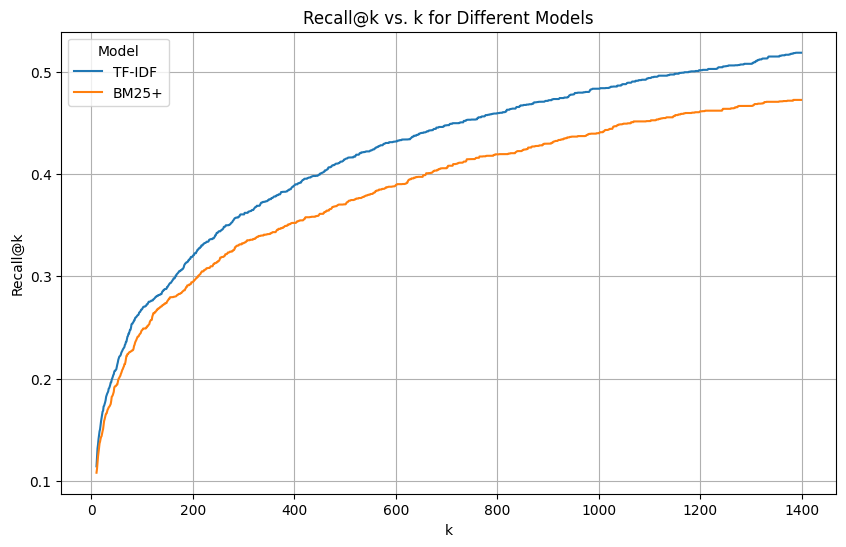

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Recall@k for both models
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="k",
    y="Recall@k",
    hue="Model"   # Compare models (TF-IDF vs BM25+)
)

plt.title("Recall@k vs. k for Different Models")
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.grid(True)

plt.show()

According to the sources, TF-IDF outperforms BM25+ in terms of Recall on the analyzed dataset.

k represents the number of top-ranked documents returned.

Here are the key points regarding their recall performance:

TF-IDF: This model achieves a recall of 0.52 when k = 1,400.

BM25+: It is considered the least effective model for this metric. It does not surpass the 0.50 threshold even when k = 1,400, indicating that it struggles more to retrieve the complete set of relevant documents.

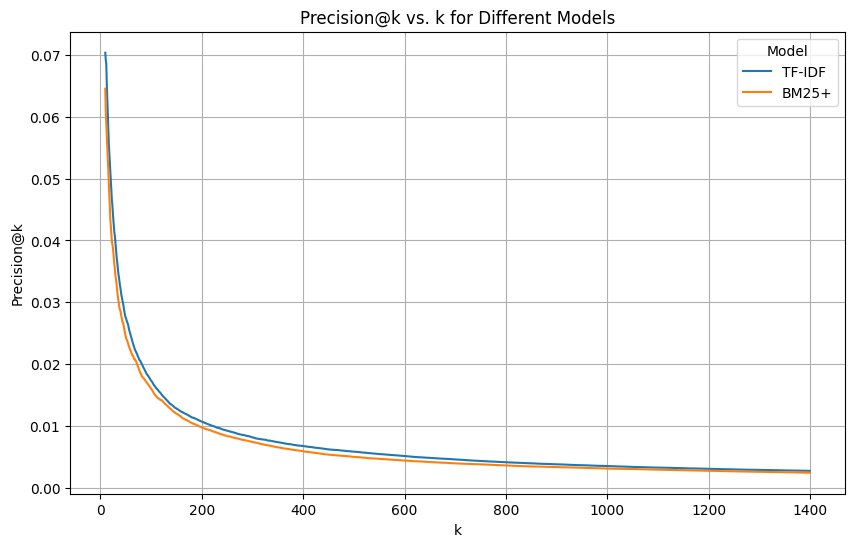

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Precision@k for both models
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="k",
    y="Precision@k",
    hue="Model"   # Compare models (TF-IDF vs BM25+)
)

plt.title("Precision@k vs. k for Different Models")
plt.xlabel("k")
plt.ylabel("Precision@k")
plt.grid(True)

plt.show()

In terms of precision, TF-IDF achieves slightly better results than BM25 pour n'import quel valeur de k


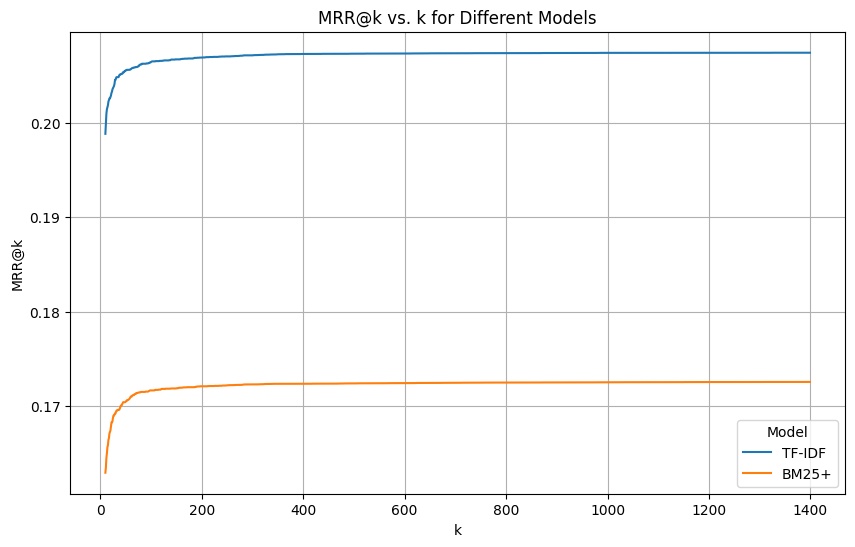

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot MRR@k for both models
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="k",
    y="MRR@k",
    hue="Model"   # Compare models (TF-IDF vs BM25+)
)

plt.title("MRR@k vs. k for Different Models")
plt.xlabel("k")
plt.ylabel("MRR@k")
plt.grid(True)

plt.show()

The analysis of the Mean Reciprocal Rank (MRR), which reflects ranking precision, confirms this hierarchy: TF-IDF achieves a score of 0.207 compared to 0.173 for BM25+. This indicates that the first relevant document generally appears higher in the ranked list with TF-IDF than with BM25+.

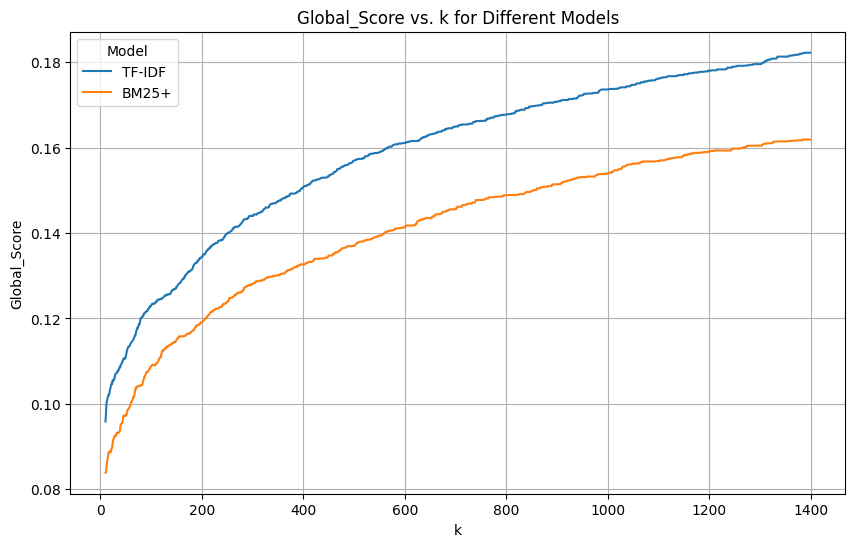

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Global Score for both models
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="k",
    y="Global_Score",
    hue="Model"   # Compare models (TF-IDF vs BM25+)
)

plt.title("Global_Score vs. k for Different Models")
plt.xlabel("k")
plt.ylabel("Global_Score")
plt.grid(True)

plt.show()

Overall, TF-IDF achieves better results than BM25+.

Our modifications to TF-IDF made it outperform BM25+, even though BM25 is theoretically designed to improve upon TF-IDF.

The main modification that likely contributed to this result is the implementation of query expansion, which allows TF-IDF to simulate a form of semantic search by adding synonyms and words from the same lexical field as the initial query.

###**2.4 Model Embedding :**

Embedding is an information retrieval method that relies on meaning and semantics rather than simple word frequency. Unlike lexical models such as TF-IDF and BM25+, it transforms each sentence or document into a dense vector in a high-dimensional space (often 1024 dimensions).

Embeddings generally produce optimal results when the processed text remains natural and close to human language. Unlike TF-IDF or BM25+, embeddings do not require heavy preprocessing such as stemming or stop-word removal, as they derive their strength from the overall semantic structure of the sentence.

Therefore, here we apply a preprocessing approach that is better suited to embeddings.


**Preprocessing:**

In [ ]:


import re

def clean_text(text):
    # Return an empty string if the input is not a valid string
    if not isinstance(text, str):
        return ""

    # Remove HTML tags using regular expressions
    text = re.sub(r'<[^>]+>', '', text)

    # Replace multiple whitespace characters with a single space and trim extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def clean_tags(tags_val):
    # If tags are provided as a list, join them into a single comma-separated string
    if isinstance(tags_val, list):
        return ", ".join(tags_val)

    # Otherwise, convert to string and format by removing brackets
    # and ensuring proper comma spacing
    return str(tags_val).replace('[', '').replace(']', '').replace(',', ', ')

C'est partie est similaire a des etapes du pretraitement de tf idf et bm25 .

In [ ]:

# Install the LangChain text splitters package
!pip install langchain-text-splitters

# Import the RecursiveCharacterTextSplitter for chunking long texts
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Import pandas for data manipulation
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 67.0 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.7
    Uninstalling langchain-core-1.2.7:
      Successfully uninstalled langchain-core-1.2.7


**Splitting Documents into Chunks for Embedding**

We use a chunking strategy with overlap. In your project, an overlap of 70 characters was applied to prevent ideas or sentences from being abruptly cut off, ensuring that the meaning remains intact within each vector.

In [ ]:



CHUNK_SIZE = 2048
CHUNK_OVERLAP = 280  

all_chunks_data = []


splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ".", " ", ""]
)
e
for _, row in docs_df.iterrows():


    title_clean = clean_text(row["title"])
    content_clean = clean_text(row["text"])

   
    chunks = splitter.split_text(content_clean)

    # Store each generated chunk with its metadata
    for i, c in enumerate(chunks):
        all_chunks_data.append({
            "chunk_id": f"{row['id']}_{i}",        
            "original_id": row["id"],               
            "category": row["category"],             
            "text_for_embedding": f"{title_clean}\n{c}" 
        })


chunks_df = pd.DataFrame(all_chunks_data)


print("Chunks:", chunks_df.shape)
print(chunks_df[["chunk_id", "original_id", "category", "text_for_embedding"]].head(2))

Chunks: (239325, 4)
                                        chunk_id  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427_0   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850_0   

                                   original_id category  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427      tex   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850     unix   

                                  text_for_embedding  
0  MikTex Download Failure - toptesi.tar.lzma\nI ...  
1  Launcher for a Python program that requires ex...  


In [ ]:



max_length_chunk = chunks_df.loc[
    chunks_df['text_for_embedding'].apply(len).idxmax()
]


print("Chunk with the longest 'text_for_embedding':")
print(max_length_chunk['text_for_embedding'])

Chunk with the longest 'text_for_embedding':
mdadm - Accidentally ran "mdadm --create" on an existing raid-1. The superblock is now corrupt and I am unable to recover data. Did I bork my data?
Checksum 0x4453, unused inodes 0 Primary superblock at 0, Group descriptors at 1-59 Reserved GDT blocks at 60-1024 Block bitmap at 1025 (+1025), Inode bitmap at 1041 (+1041) Inode table at 1057-1568 (+1057) 23513 free blocks, 8181 free inodes, 2 directories Free blocks: 12576-12591, 12864-12879, Free inodes: Group 1: (Blocks 32768-65535) [ITABLE_ZEROED] Checksum 0x348a, unused inodes 0 Backup superblock at 32768, Group descriptors at 32769-32827 Reserved GDT blocks at 32828-33792 Block bitmap at 1026 (bg #0 + 1026), Inode bitmap at 1042 (bg #0 + 1042) Inode table at 1569-2080 (bg #0 + 1569) 31743 free blocks, 8192 free inodes, 0 directories Free blocks: 43232-43239, 43264-43271, Free inodes: Group 2: (Blocks 65536-98303) [ITABLE_ZEROED] Checksum 0x2056, unused inodes 0 Block bitmap at 1027 (bg #0

In [ ]:


def prepare_query(row):
    # Clean the original query text
    q = clean_text(row["text"])

    # Add an instruction prefix to improve embedding-based retrieval performance
    return "Represent this sentence for searching relevant passages: " + q

# Apply the query preparation function to the training and test queries
train_queries_df["query_enriched"] = train_queries_df.apply(prepare_query, axis=1)
test_queries_df["query_enriched"]  = test_queries_df.apply(prepare_query, axis=1)

# Display the first two enriched training queries
print(train_queries_df["query_enriched"].head(2))

0    Represent this sentence for searching relevant...
1    Represent this sentence for searching relevant...
Name: query_enriched, dtype: object


In [ ]:


!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
import torch
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the pre-trained embedding model
model = SentenceTransformer("BAAI/bge-base-en-v1.5", device=device) #choice of the model

def encode_fast(texts, model, batch_size=64):
  
    return model.encode(
        texts,
        batch_size=batch_size,         
        show_progress_bar=True,
        normalize_embeddings=True,      # Normalize vectors for cosine similarity
        convert_to_numpy=True
    )

# Generate embeddings for document chunks
doc_embeddings = encode_fast(
    chunks_df["text_for_embedding"].tolist(),
    model,
    batch_size=1024
)

# Generate embeddings for training queries
train_embeddings = encode_fast(
    train_queries_df["query_enriched"].tolist(),
    model,
    batch_size=1024
)

# Generate embeddings for test queries
test_embeddings = encode_fast(
    test_queries_df["query_enriched"].tolist(),
    model,
    batch_size=1024
)

# Display embedding matrix shapes
print("Doc:", doc_embeddings.shape)
print("Train:", train_embeddings.shape)
print("Test:", test_embeddings.shape)


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Doc: (239325, 768)
Train: (327, 768)
Test: (141, 768)


In [ ]:


from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


import os
import numpy as np

# Define the directory in Google Drive where files will be stored
SAVE_DIR = "/content/drive/MyDrive/data_science"

# Create the directory if it does not already exist
os.makedirs(SAVE_DIR, exist_ok=True)

# Save embeddings as NumPy binary files (.npy format)
np.save(os.path.join(SAVE_DIR, "doc_embeddings5.npy"), doc_embeddings)
np.save(os.path.join(SAVE_DIR, "train_embeddings5.npy"), train_embeddings)
np.save(os.path.join(SAVE_DIR, "test_embeddings5.npy"), test_embeddings)

print("Embeddings saved to doc_embeddings5.npy, train_embeddings5.npy, and test_embeddings5.npy")

Embeddings saved to doc_embeddings5.npy, train_embeddings5.npy, and test_embeddings5.npy


In [ ]:
# Load the NumPy embedding files into memory
doc_embeddings   = np.load(f"{SAVE_DIR}/doc_embeddings5.npy")
train_embeddings = np.load(f"{SAVE_DIR}/train_embeddings5.npy")
test_embeddings  = np.load(f"{SAVE_DIR}/test_embeddings5.npy")

# Display the shape of each embedding matrix
# (Documents, Training Queries, Test Queries)
print(doc_embeddings.shape, train_embeddings.shape, test_embeddings.shape)

(239325, 768) (327, 768) (141, 768)


**What is the purpose of high-dimensional embeddings? How can they help in information retrieval compared to simpler models?**

The purpose of high-dimensional embeddings is to convert text into dense vectors in
a high-dimensional space where semantic similarity is reflected by geometric proximity.


Unlike simpler bag-of-words models (such as TF-IDF or BM25) that rely mainly on
exact token overlap, embeddings can capture deeper meaning, synonyms, paraphrases,
and contextual relations between words. This significantly helps information retrieval
when the user’s query and the relevant documents use different vocabulary (e.g., “ins-
tall” vs. “setup”). Furthermore, it improves the system’s robustness to noisy, short, or
conversational queries. In practice, embedding-based retrieval typically ranks documents
by calculating the cosine similarity between the query vector and the document vectors.


Running UMAP on 3327 points (docs: 3000, queries: 327)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


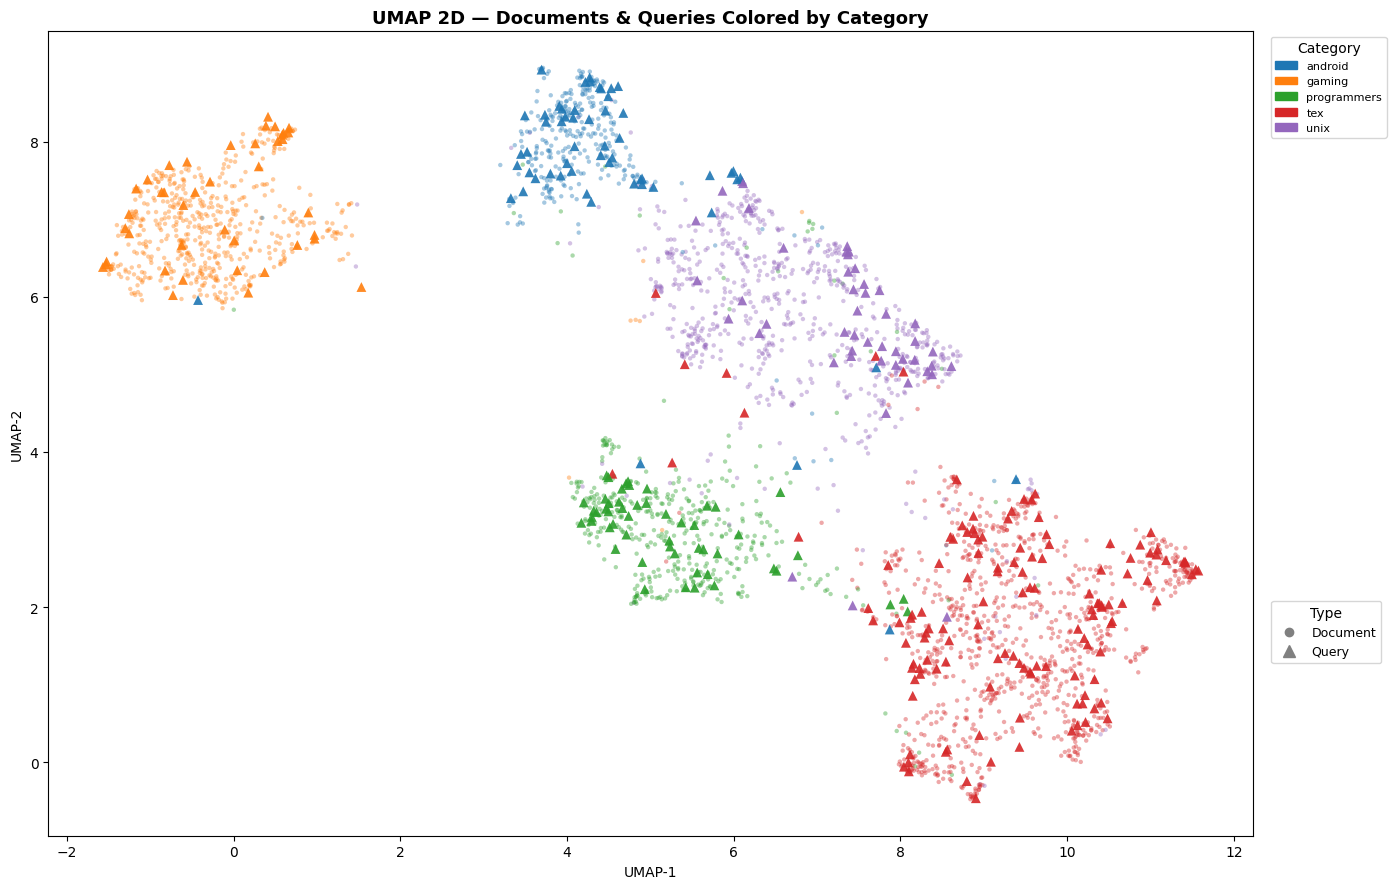

Saved: umap_embeddings.png


In [ ]:

import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np



MAX_DOCS    = 3000  
MAX_QUERIES = 500   


np.random.seed(42)

n_docs = len(doc_embeddings)
n_qrs  = len(train_embeddings)

# Randomly pick indices without replacement (unique samples)
doc_idx = np.random.choice(n_docs, min(MAX_DOCS, n_docs), replace=False)
qry_idx = np.random.choice(n_qrs,  min(MAX_QUERIES, n_qrs), replace=False)

# Extract the sampled embeddings
sample_doc_embs   = doc_embeddings[doc_idx]
sample_query_embs = train_embeddings[qry_idx]

# Retrieve the associated categories (used for coloring points)
sample_doc_cats   = chunks_df["category"].iloc[doc_idx].tolist()
sample_query_cats = train_queries_df["category"].iloc[qry_idx].tolist()

# Combine documents and queries into one matrix so UMAP places them
# in the *same* 2D space (important for comparing their relative positions).
combined  = np.vstack([sample_doc_embs, sample_query_embs])

# Store labels for each point: its category (color) and its type (marker style)
all_cats  = sample_doc_cats + sample_query_cats
all_kinds = ["doc"] * len(doc_idx) + ["query"] * len(qry_idx)

print(f"Running UMAP on {len(combined)} points (docs: {len(doc_idx)}, queries: {len(qry_idx)})")


reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)


embedding_2d = reducer.fit_transform(combined)



categories   = sorted(set(all_cats))
palette      = sns.color_palette("tab10", len(categories))
cat_to_color = {c: palette[i] for i, c in enumerate(categories)}

fig, ax = plt.subplots(figsize=(14, 9))


for kind, marker, size, alpha in [
    ("doc",   "o", 10, 0.4),  
    ("query", "^", 50, 0.9)   
]:
  
    mask = [i for i, k in enumerate(all_kinds) if k == kind]

   
    for i in mask:
        ax.scatter(
            embedding_2d[i, 0], embedding_2d[i, 1],
            c=[cat_to_color[all_cats[i]]],
            marker=marker,
            s=size,
            alpha=alpha,
            edgecolors="none"
        )


# Category legend: colored patches
patches = [mpatches.Patch(color=cat_to_color[c], label=c) for c in categories]

# Type legend: marker-only legend entries
from matplotlib.lines import Line2D
type_legend = [
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=6, label="Document"),
    Line2D([0], [0], marker="^", color="gray", linestyle="None", markersize=8, label="Query"),
]

# Add both legends (Matplotlib normally replaces the first legend when adding a second)
leg1 = ax.legend(handles=patches, title="Category", bbox_to_anchor=(1.01, 1),   loc="upper left", fontsize=8)
leg2 = ax.legend(handles=type_legend, title="Type", bbox_to_anchor=(1.01, 0.3), loc="upper left", fontsize=9)
ax.add_artist(leg1)

ax.set_title("UMAP 2D — Documents & Queries Colored by Category", fontsize=13, fontweight="bold")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

plt.tight_layout()


plt.savefig("umap_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: umap_embeddings.png")

We observe clear clusters, which become even more distinct when color-coded by category. Queries and documents from the same category tend to group together, though some categories form tighter clusters than others.

For example, the gaming category forms a compact and well-separated cluster. Programmers and android show a similar pattern, but with slightly more dispersion. In contrast, unix and tex are more spread out, reflecting greater internal diversity. A few outliers are also visible, which is normal in high-dimensional projections.

This behavior is expected, since the documents were pre-classified. Categories define the main subject and vocabulary, and because embeddings capture semantic meaning, texts with similar context naturally appear close to each other in vector space.

In [ ]:

import numpy as np

def retrieve_topk_blockwise(query_embs, doc_embs, k=5000, doc_block=50000):
   

    Q = query_embs.shape[0]  # Number of queries
    N = doc_embs.shape[0]    # Number of document chunks

    # Initialize top-k scores and indices
    top_scores = np.full((Q, k), -np.inf, dtype=np.float32)
    top_idx    = np.full((Q, k), -1,      dtype=np.int32)

    # Process documents in blocks to reduce memory usage
    for start in range(0, N, doc_block):
        end = min(start + doc_block, N)
        block = doc_embs[start:end]  # Current block of documents [B, D]

       
        sim = query_embs @ block.T

        # Select local top-k candidates inside this block
        k_local = min(k, sim.shape[1])
        idx_local = np.argpartition(-sim, kth=k_local - 1, axis=1)[:, :k_local]
        scr_local = np.take_along_axis(sim, idx_local, axis=1)

        # Convert local indices to global indices
        idx_global = idx_local + start

        # Merge with previously selected top-k results
        merged_scores = np.concatenate([top_scores, scr_local], axis=1)
        merged_idx    = np.concatenate([top_idx,    idx_global], axis=1)

        # Keep only global top-k results
        sel = np.argpartition(-merged_scores, kth=k - 1, axis=1)[:, :k]
        top_scores = np.take_along_axis(merged_scores, sel, axis=1)
        top_idx    = np.take_along_axis(merged_idx,    sel, axis=1)

        # Sort final top-k results in descending similarity order
        order = np.argsort(-top_scores, axis=1)
        top_scores = np.take_along_axis(top_scores, order, axis=1)
        top_idx    = np.take_along_axis(top_idx,    order, axis=1)

        print(f"Documents {start}-{end}/{N} processed")

    return top_idx, top_scores


K_LIST   = range(10, 2000, 100)  # Evaluation cutoffs
K_DOCS   = max(K_LIST)
K_CHUNKS = 239325  # Total number of document chunks


topk_indices_train, topk_scores_train = retrieve_topk_blockwise(
    train_embeddings.astype(np.float32),
    doc_embeddings.astype(np.float32),
    k=K_CHUNKS,
    doc_block=50000
)

print(topk_indices_train.shape, topk_scores_train.shape)

Documents 0-50000/239325 processed
Documents 50000-100000/239325 processed
Documents 100000-150000/239325 processed
Documents 150000-200000/239325 processed
Documents 200000-239325/239325 processed
(327, 239325) (327, 239325)


In [ ]:


def parse_gts(gts_df):

    gt_dict = {}

    for col in gts_df.columns:
        rel_ids_raw = gts_df.loc["relevant_doc_ids", col]

        # Main case: list of dicts like [{"doc_id": "xxx"}, ...]
        if isinstance(rel_ids_raw, list):
            ids = [d["doc_id"] for d in rel_ids_raw if isinstance(d, dict) and "doc_id" in d]

        # Fallback: sometimes stored as a JSON-like string
        elif isinstance(rel_ids_raw, str):
            import re
            ids = re.findall(r'"doc_id":\s*"([^"]+)"', rel_ids_raw)

        # Otherwise: no relevant ids available
        else:
            ids = []

        gt_dict[col] = set(ids)

    return gt_dict


# Build the ground truth dictionary
gt_dict = parse_gts(gts_df)

# Quick sanity check
print(f"Parsed GTs for {len(gt_dict)} queries")
sample_qid = list(gt_dict.keys())[0]
print(f"Example — query '{sample_qid[:30]}...' → {len(gt_dict[sample_qid])} relevant doc(s)")

Parsed GTs for 327 queries
Example — query '961c4349-8cf1-4ef1-89cc-24d20b...' → 4 relevant doc(s)


In [ ]:

chunk_to_doc = chunks_df["original_id"].tolist()

In [ ]:


def chunks_to_top_docs_robust(chunk_indices_row, k_docs, chunk_to_doc):


    seen = set()  # Track already selected document IDs
    out = []

    # 1) Traverse ranked chunk indices (highest similarity first)
    for idx in chunk_indices_row:

        # Ignore invalid indices (e.g., -1)
        if idx is None or int(idx) < 0:
            continue

        doc_id = chunk_to_doc[int(idx)]

        # Safety checks against None or invalid values
        if doc_id is None:
            continue
        doc_id = str(doc_id)
        if doc_id.lower() == "nan" or doc_id.strip() == "":
            continue

        # Keep only the first occurrence of each document
        if doc_id not in seen:
            seen.add(doc_id)
            out.append(doc_id)

      
        if len(out) == k_docs:
            return out

    
    for doc_id in chunk_to_doc:
        if doc_id is None:
            continue
        doc_id = str(doc_id)
        if doc_id.lower() == "nan" or doc_id.strip() == "":
            continue
        if doc_id not in seen:
            seen.add(doc_id)
            out.append(doc_id)

        if len(out) == k_docs:
            break

    return out

In [ ]:


import pandas as pd


train_query_ids = train_queries_df["id"].tolist()

def compute_all_metrics(topk_indices, topk_scores, train_query_ids, gt_dict, k_list):
    """
    Compute retrieval metrics over a list of cutoffs K:
      - Precision@K: proportion of retrieved docs that are relevant
      - Recall@K: proportion of relevant docs that were retrieved
      - MRR@K: reciprocal rank of the first relevant doc (0 if none found)
    Returns a DataFrame with one row per K.
    """
    results = []

    for k in k_list:
        precisions, recalls, rr_list = [], [], []

        # Evaluate each query independently
        for i, qid in enumerate(train_query_ids):
            relevant = gt_dict.get(qid, set())
            if not relevant:
                continue  

            retrieved = chunks_to_top_docs_robust(
                topk_indices[i],
                k_docs=k,
                chunk_to_doc=chunk_to_doc
            )

            # Count how many retrieved documents are relevant
            hits = [d for d in retrieved if d in relevant]

            # Compute Precision@k and Recall@k for this query
            precisions.append(len(hits) / k)
            recalls.append(len(hits) / len(relevant))

            # Compute Reciprocal Rank (first relevant document position)
            rr = 0.0
            for rank, doc in enumerate(retrieved, start=1):
                if doc in relevant:
                    rr = 1.0 / rank
                    break
            rr_list.append(rr)

      
        results.append({
            "k":           k,
            "Precision@k": round(np.mean(precisions), 4),
            "Recall@k":    round(np.mean(recalls),    4),
            "MRR@k":       round(np.mean(rr_list),    4),
        })

    return pd.DataFrame(results)


metrics_df = compute_all_metrics(
    topk_indices_train,
    topk_scores_train,
    train_query_ids,
    gt_dict,
    K_LIST
)

print("\n===== RETRIEVAL METRICS =====")
print(metrics_df.to_string(index=False))


===== RETRIEVAL METRICS =====
   k  Precision@k  Recall@k  MRR@k
  10       0.1642    0.2752 0.4389
 110       0.0334    0.5472 0.4474
 210       0.0209    0.6236 0.4476
 310       0.0155    0.6688 0.4477
 410       0.0124    0.6932 0.4477
 510       0.0104    0.7156 0.4477
 610       0.0090    0.7337 0.4478
 710       0.0080    0.7492 0.4478
 810       0.0071    0.7635 0.4478
 910       0.0065    0.7725 0.4478
1010       0.0059    0.7805 0.4478
1110       0.0055    0.7881 0.4478
1210       0.0051    0.7984 0.4478
1310       0.0048    0.8076 0.4478
1410       0.0045    0.8157 0.4478
1510       0.0042    0.8213 0.4478
1610       0.0040    0.8250 0.4478
1710       0.0038    0.8289 0.4478
1810       0.0036    0.8319 0.4478
1910       0.0035    0.8352 0.4478


**Evaluation phase of the model**

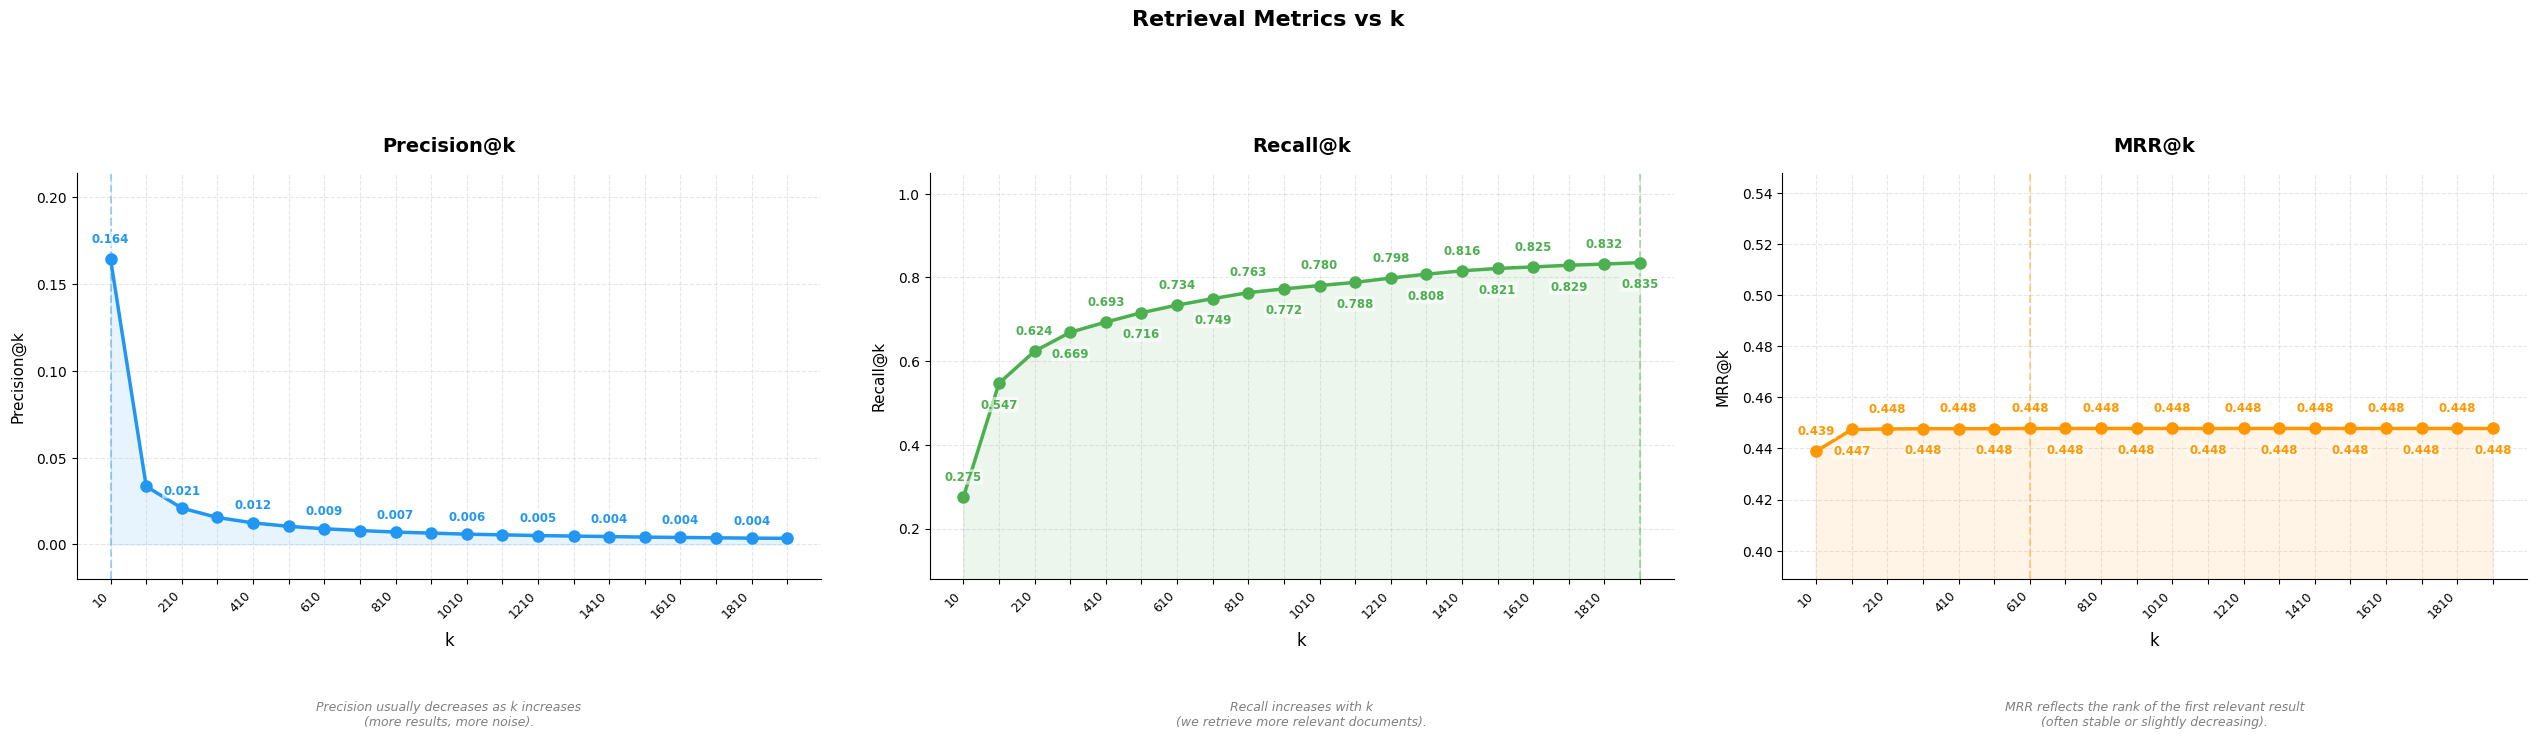

Saved: metrics_vs_k.png


In [ ]:


import matplotlib.pyplot as plt
import numpy as np

# Create 3 side-by-side plots (Precision, Recall, MRR)
fig, axes = plt.subplots(1, 3, figsize=(26, 8))
fig.suptitle("Retrieval Metrics vs k", fontsize=16, fontweight='bold', y=1.03)

# Metric configuration: (column name, color, short interpretation note)
metric_cfg = [
    ("Precision@k", "#2196F3", "Precision usually decreases as k increases\n(more results, more noise)."),
    ("Recall@k",    "#4CAF50", "Recall increases with k\n(we retrieve more relevant documents)."),
    ("MRR@k",       "#FF9800", "MRR reflects the rank of the first relevant result\n(often stable or slightly decreasing)."),
]

for ax, (metric, color, note) in zip(axes, metric_cfg):
    vals = metrics_df[metric].values
    ks   = metrics_df["k"].values

    # Plot curve + light area fill for readability
    ax.plot(ks, vals, marker="o", color=color, linewidth=2.5, markersize=8, zorder=3)
    ax.fill_between(ks, vals, alpha=0.1, color=color)

    # Annotate points (reduced labels for Precision to avoid overlap)
    for i, (x, y) in enumerate(zip(ks, vals)):
        if metric == "Precision@k" and i > 0 and i % 2 != 0:
            continue

        offset_y = 12 if i % 2 == 0 else -18
        if metric == "Precision@k" and y < 0.05:
            offset_y = 10

        ax.annotate(
            f"{y:.3f}", (x, y),
            textcoords="offset points",
            xytext=(0, offset_y),
            ha='center', fontsize=8.5, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.6)
        )

    # Highlight the best k for this metric (max value)
    best_idx = np.argmax(vals)
    ax.axvline(x=ks[best_idx], color=color, linestyle='--', alpha=0.4, linewidth=1.5)

    # Axes labels and styling
    ax.set_title(metric, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("k", fontsize=12, labelpad=8)
    ax.set_ylabel(metric, fontsize=11, labelpad=8)

    # Show one x-axis label out of two for readability
    ax.set_xticks(ks)
    x_labels = [str(k) if i % 2 == 0 else "" for i, k in enumerate(ks)]
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

    # Adjust y-limits to avoid squeezing the curve against the axis
    y_min, y_max = vals.min(), vals.max()
    if metric == "Precision@k":
        ax.set_ylim(-0.02, y_max + 0.05)
    else:
        margin = (y_max - y_min) * 0.35 if (y_max - y_min) > 0.01 else 0.05
        ax.set_ylim(max(0, y_min - margin), min(1.05, y_max + margin + 0.05))

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Add a short interpretation note below each plot
    ax.text(0.5, -0.30, note, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='gray', style='italic')

# Final layout + save figure
plt.tight_layout(pad=3.0)
plt.savefig("metrics_vs_k.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: metrics_vs_k.png")

**Kaggle test**


In [ ]:

topk_indices_test, topk_scores_test = retrieve_topk_blockwise(
    test_embeddings.astype(np.float32),
    doc_embeddings.astype(np.float32),    
    k=239325,                            
    doc_block=50000                       
)


K_SUBMIT = 3000

Documents 0-50000/239325 processed
Documents 50000-100000/239325 processed
Documents 100000-150000/239325 processed
Documents 150000-200000/239325 processed
Documents 200000-239325/239325 processed


In [ ]:


import pandas as pd
import json


test_query_ids = test_queries_df["id"].astype(str).tolist()

rows = []


for i, qid in enumerate(test_query_ids):


    retrieved_doc_ids = chunks_to_top_docs_robust(
        topk_indices_test[i],
        k_docs=K_SUBMIT,
        chunk_to_doc=chunk_to_doc
    )

   
    relevant_str = json.dumps(retrieved_doc_ids)

    rows.append({
        "queryID": qid,
        "relevantIDs": relevant_str,
        "category": " "  
    })

submission_df = pd.DataFrame(rows)

submission_df.head()

,queryID,relevantIDs,category
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,"[""87a25467-3a02-4bc5-9d9d-af40d61b098e_159813""...",
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,"[""f013d0bd-279d-4ab4-890f-bb5e499dd919_246678""...",
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,"[""43fa6e5a-6ad6-4701-ba44-68b513409ffc_17053"",...",
3,cb216e47-add6-41fd-974a-39251e4df3aa_6777,"[""abb6048a-487f-42a5-bc18-73fa59e7df24_31771"",...",
4,14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748,"[""59108dd2-5f5a-4add-b947-3303c8aaa891_123331""...",


In [ ]:


import json


submission_df2 = submission_df.copy()


submission_df2["doclen"] = submission_df["relevantIDs"].apply(
    lambda x: len(json.loads(x))
)

submission_df2["doclen"].describe()

,doclen
count,141.0
mean,3000.0
std,0.0
min,3000.0
25%,3000.0
50%,3000.0
75%,3000.0
max,3000.0


In [ ]:


submission_df = submission_df.rename(columns={
    "queryID": "query_id",
    "relevantIDs": "relevant_doc_ids"
})


submission_df["category"] = submission_df["category"].fillna("unknown")


submission_df.to_csv("solutions_MM.csv", index=False)

print("Submission file saved as solutions_MM.csv")

Submission file saved as solutions_MM.csv


In [ ]:


out_path = "solutions_MM.csv"


submission_df.to_csv(out_path, index=False)


print("Saved:", out_path)

Saved: solutions_MM.csv


In [ ]:




from google.colab import files
files.download("solutions_MM.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Phase 2: Classification and Reranking :**


To improve our Retrieval models, we can also add query classification to our pipeline. As seen in the 2D Visualization of Embeddings with UMAP, queries and documents cluster into distinct regions of the graph, suggesting that classification could help us improve our results and better filter candidates.

##**1. Document and Query Classification**




We import the embeddings generated in Phase 1, along with the corresponding data, as well as all the necessary libraries and preprocessing steps used in that phase.

In [ ]:
import json

with open("docs.json", "r") as f:
    documents = json.load(f)

# Load training queries
with open("queries_train.json", "r") as f:
    train_queries = json.load(f)

# Load relevance judgments (ground truth)
with open("qgts_train.json", "r") as f:
    gts = json.load(f)

# Load test queries
with open("queries_test.json", "r") as f:
    test_queries = json.load(f)

# Print dataset sizes
print("documents Number:", len(documents))
print("train queries Number:", len(train_queries))
print("relevance judgments Number:", len(gts))
print("test queries Number:", len(test_queries))

# Convert data to pandas DataFrames for easier manipulation
docs_df = pd.DataFrame(documents)
train_queries_df = pd.DataFrame(train_queries)
gts_df = pd.DataFrame(gts)
test_queries_df = pd.DataFrame(test_queries)

documents Number: 216041
train queries Number: 327
relevance judgments Number: 327
test queries Number: 141


In [ ]:

from google.colab import drive
drive.mount("/content/drive")

import numpy as np


SAVE_DIR = "/content/drive/MyDrive/data_science"


doc_embeddings   = np.load(f"{SAVE_DIR}/doc_embeddings5.npy")
train_embeddings = np.load(f"{SAVE_DIR}/train_embeddings5.npy")
test_embeddings  = np.load(f"{SAVE_DIR}/test_embeddings5.npy")

print(doc_embeddings.shape, train_embeddings.shape, test_embeddings.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(239325, 768) (327, 768) (141, 768)


We check the distribution of our categories to decide whether to use class_weight='balanced'


In [ ]:

print(docs_df["category"].value_counts())
print(docs_df["category"].value_counts(normalize=True).round(3) * 100)



category
tex            68184
unix           47382
gaming         45301
programmers    32176
android        22998
Name: count, dtype: int64

category
tex            31.6
unix           21.9
gaming         21.0
programmers    14.9
android        10.6
Name: proportion, dtype: float64


In [ ]:


docs_df["title_clean"] = docs_df["title"].apply(clean_text)


docs_df["text_clean"] = docs_df["text"].apply(clean_text)

docs_df["tags_clean"] = docs_df["tags"].apply(clean_tags)


docs_df["content_key"] = (
    (docs_df["title_clean"]+ " ")*3 +
    docs_df["text_clean"]  + " " +
    docs_df["tags_clean"]
).str.strip()





# application of the cleaning functions
train_queries_df["title_clean"] = train_queries_df["title"].apply(clean_text)
train_queries_df["text_clean"]  = train_queries_df["text"].apply(clean_text)
train_queries_df["tags_clean"] = train_queries_df["tags"].apply(clean_tags)

#merge : text + title + tags
train_queries_df["content_key"] = (
    train_queries_df["title_clean"] + " " +
    train_queries_df["text_clean"]  + " " +
    train_queries_df["tags_clean"]
).str.strip() 





# application of the cleaning functions
test_queries_df["title_clean"] = test_queries_df["title"].apply(clean_text)
test_queries_df["text_clean"]  = test_queries_df["text"].apply(clean_text)
test_queries_df["tags_clean"] = test_queries_df["tags"].apply(clean_tags)

#merge : text + title + tags
test_queries_df["content_key"] = (
    test_queries_df["title_clean"] + " " +
    test_queries_df["text_clean"]  + " " +
    test_queries_df["tags_clean"]
).str.strip() #enlève les espaces au début/fin pour que deux contenus identiques ne deviennent pas différents juste à cause d’un espace.


In [ ]:

!pip install langchain-text-splitters


from langchain_text_splitters import RecursiveCharacterTextSplitter

import pandas as pd


# Define chunking parameters
CHUNK_SIZE = 2048
CHUNK_OVERLAP = 280  # Approximately 15% overlap to preserve context between chunks

all_chunks_data = []

# Initialize the text splitter with custom separators
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ".", " ", ""]
)

# Iterate over each document in the DataFrame
for _, row in docs_df.iterrows():

    # A. Clean the title and content before processing
    title_clean = clean_text(row["title"])
    content_clean = clean_text(row["text"])

    # Split the cleaned content into smaller chunks
    chunks = splitter.split_text(content_clean)

    # Store each generated chunk with its metadata
    for i, c in enumerate(chunks):
        all_chunks_data.append({
            "chunk_id": f"{row['id']}_{i}",      
            "original_id": row["id"],                
            "category": row["category"],            
            "text_for_embedding": f"{title_clean}\n{c}"  
        })


chunks_df = pd.DataFrame(all_chunks_data)

# Display the shape and preview of the resulting chunks dataset
print("Chunks:", chunks_df.shape)
print(chunks_df[["chunk_id", "original_id", "category", "text_for_embedding"]].head(2))

Chunks: (239325, 4)
                                        chunk_id  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427_0   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850_0   

                                   original_id category  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427      tex   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850     unix   

                                  text_for_embedding  
0  MikTex Download Failure - toptesi.tar.lzma\nI ...  
1  Launcher for a Python program that requires ex...  


In [ ]:
print(len(doc_embeddings))
print(len(docs_df))

print(len(train_embeddings))
print(len(train_queries_df))

239325
216041
327
327


### 1.1 Choice of classification model


What model could you use as a document classifier? How does it work?
- SVM (Support Vector Machine): Finds the optimal boundary between classes in high-dimensional text data, making it very effective for classification.
- Logistic Regression: Computes a weighted sum of features to estimate the probability that a document belongs to a class.
- Random Forest: Combines multiple decision trees to make predictions, but is less effective for text due to high dimensionality and sparsity.

### 1.2 Data splitting and preparation for our classification models (SVM, LR)


Splitting data for the classification process:

We keep 10% of documents and queries as holdout sets and use the remaining data for training (with an 80/20 internal split).

This setup allows the model to learn from both data types while evaluating on documents (holdout_docs), queries (holdout_queries), and also on the full test data (holdout_docs + holdout_queries).

What data could you use to train your classifier? Will you use both documents and queries?

We choose to use both queries and documents to train the classification models in order to benefit from their complementary properties. Queries help the model adapt to the structure of the final validation queries, while documents provide a larger volume of data that helps reduce overfitting. Using only queries could lead to overfitting due to limited data, whereas using only documents could harm generalization, since the model would be trained on longer texts while the inputs to classify are shorter queries.

In [ ]:


from sklearn.model_selection import train_test_split


chunk_cats = chunks_df["original_id"].map(
    docs_df.set_index("id")["category"]
).values

chunks_train_idx, chunks_holdout_idx = train_test_split(
    np.arange(len(chunks_df)),
    test_size=0.10,
    random_state=42,
    stratify=chunk_cats
)

chunks_df_train   = chunks_df.iloc[chunks_train_idx].reset_index(drop=True)
chunks_df_holdout = chunks_df.iloc[chunks_holdout_idx].reset_index(drop=True)

# Corresponding embeddings
doc_emb_train   = doc_embeddings[chunks_train_idx]
doc_emb_holdout = doc_embeddings[chunks_holdout_idx]

print(f"chunks pour entraînement : {len(chunks_df_train)}")
print(f"chunks holdout (10%) : {len(chunks_df_holdout)}")

# --- 10% holdout on training queries ---
tq_train_idx, tq_holdout_idx = train_test_split(
    np.arange(len(train_queries_df)),
    test_size=0.10,
    random_state=42,
    stratify=train_queries_df["category"].values
)

tq_df_train   = train_queries_df.iloc[tq_train_idx].reset_index(drop=True)
tq_df_holdout = train_queries_df.iloc[tq_holdout_idx].reset_index(drop=True)

# Corresponding embeddings
tq_emb_train = train_embeddings[tq_train_idx]
tq_emb_holdout = train_embeddings[tq_holdout_idx]

print(f"train queries pour entraînement : {len(tq_df_train)}")
print(f"train queries holdout (10%)      : {len(tq_df_holdout)}")

chunks pour entraînement : 215392
chunks holdout (10%)     : 23933
train queries pour entraînement : 294
train queries holdout (10%)      : 33


What input features could you use for your classifier?

Once the data is selected, it is necessary to define the features used as input to the model. Features correspond to the numerical representation of texts, allowing the classifier to exploit them effectively.

In our case, each document or query is represented by a high-dimensional vector capturing the semantic information of the text. These vectors, derived from document chunks and queries (content_key = text + tags + title) after vectorization, constitute the main feature of the model.

In addition, we add an extra feature corresponding to the text length (number of words), normalized. This information allows the model to account for structural differences between document chunks (often long) and queries (often short).

The final features are thus obtained by concatenating the text vectors with the normalized text length. This combination allows both the semantic content and structural properties of the data to be represented.

In [ ]:

from sklearn.preprocessing import StandardScaler
import numpy as np

# Compute text lengths for each split
doc_lengths_train   = chunks_df_train["text_for_embedding"].apply(lambda x: len(x.split())).values.reshape(-1, 1)
doc_lengths_holdout = chunks_df_holdout["text_for_embedding"].apply(lambda x: len(x.split())).values.reshape(-1, 1)
tq_lengths_train    = tq_df_train["content_key"].apply(lambda x: len(x.split())).values.reshape(-1, 1)
tq_lengths_holdout  = tq_df_holdout["content_key"].apply(lambda x: len(x.split())).values.reshape(-1, 1)
test_lengths        = test_queries_df["content_key"].apply(lambda x: len(x.split())).values.reshape(-1, 1)

# Fit the scaler only on training data
scaler = StandardScaler()
doc_lengths_train_norm   = scaler.fit_transform(doc_lengths_train)
doc_lengths_holdout_norm = scaler.transform(doc_lengths_holdout)
tq_lengths_train_norm    = scaler.transform(tq_lengths_train)
tq_lengths_holdout_norm  = scaler.transform(tq_lengths_holdout)
test_lengths_norm        = scaler.transform(test_lengths)

# Concatenate embeddings with normalized length feature
X_docs_train   = np.hstack([doc_emb_train,   doc_lengths_train_norm])
X_docs_holdout = np.hstack([doc_emb_holdout, doc_lengths_holdout_norm])
X_tq_train     = np.hstack([tq_emb_train,    tq_lengths_train_norm])
X_tq_holdout   = np.hstack([tq_emb_holdout,  tq_lengths_holdout_norm])
X_test_queries = np.hstack([test_embeddings, test_lengths_norm])

print("X_docs_train shape:", X_docs_train.shape)
print("X_tq_train shape  :", X_tq_train.shape)

X_docs_train shape: (215392, 769)
X_tq_train shape  : (294, 769)


- Train → X_tq_train, X_docs_train
- Test  → X_docs_holdout (10% docs), X_tq_holdout (10% queries)

In [ ]:

from sklearn.preprocessing import LabelEncoder

# Labels for training
chunk_cats_train = chunks_df_train["original_id"].map(
    docs_df.set_index("id")["category"]
).tolist()

all_X = np.vstack([X_docs_train, X_tq_train])
all_y = chunk_cats_train + list(tq_df_train["category"])

# Labels for holdout sets
y_holdout_docs    = chunks_df_holdout["original_id"].map(
    docs_df.set_index("id")["category"]
).tolist()
y_holdout_queries = list(tq_df_holdout["category"])

# LabelEncoder fitted on training data
le = LabelEncoder()
all_y_enc          = le.fit_transform(all_y)
y_holdout_docs_enc = le.transform(y_holdout_docs)
y_holdout_tq_enc   = le.transform(y_holdout_queries)

print("Total exemples entraînement:", len(all_y))
print("Classes:", le.classes_)

Total exemples entraînement: 215686
Classes: ['android' 'gaming' 'programmers' 'tex' 'unix']


Class labels are encoded as integers because models cannot process strings directly.

android → 0, gaming → 1, programmers → 2, tex → 3, unix → 4

**Data Preparation Strategy**

Both document chunks (X_docs_train) and training queries (X_tq_train), after excluding the holdout set, are combined to form the full training dataset. This approach serves two main purposes:

- More data: Increasing the number of training examples provides the classifier with a stronger learning signal.

- Better domain alignment: Since the model is ultimately evaluated on queries, including query embeddings during training ensures it is exposed to the same type of input it will encounter at inference time, rather than only document chunks. This helps reduce the train–test distribution gap.

### 1.3 Implementation of the Logistic Regression model


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


X_tr, X_val, y_tr, y_val = train_test_split(
    all_X, all_y_enc,
    test_size=0.2,  
    random_state=42, 
    stratify=all_y_enc 
)

# Train the model
clf = LogisticRegression(
    max_iter=1000, 
    C=5.0,
    solver='saga', 
    n_jobs=-1, 
    class_weight='balanced'
)
clf.fit(X_tr, y_tr)

y_pred_val = clf.predict(X_val)
print("=== Validation interne (20% du train) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

=== Validation interne (20% du train) ===
Accuracy: 0.9778153831888359
              precision    recall  f1-score   support

     android       0.97      0.98      0.97      4250
      gaming       0.99      0.99      0.99      8288
 programmers       0.96      0.97      0.97      6338
         tex       0.99      0.98      0.99     14602
        unix       0.96      0.97      0.97      9660

    accuracy                           0.98     43138
   macro avg       0.97      0.98      0.98     43138
weighted avg       0.98      0.98      0.98     43138



Evaluation of the LR model on the full test set (10% docs + 10% queries):
Good results with Accuracy: 0.97. The model classifies tex and gaming slightly better,
but results are homogeneous across all classes.

#### 1.3.1 Learning Curves — Logistic Regression Classifier


We plot the learning curve of the Logistic Regression model to verify whether it suffers from overfitting.


In [ ]:

from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, C=5.0, solver='saga', n_jobs=-1, class_weight='balanced'),
    all_X, all_y_enc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

print("train_sizes =", train_sizes.tolist())
print("train_mean =", train_mean.tolist())
print("train_std =", train_std.tolist())
print("val_mean =", val_mean.tolist())
print("val_std =", val_std.tolist())



[learning_curve] Training set sizes: [ 14379  28758  43137  57516  71895  86274 100653 115032 129411 143790]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


train_sizes = [14379, 28758, 43137, 57516, 71895, 86274, 100653, 115032, 129411, 143790]
train_mean = [0.9844217261283816, 0.982868535132253, 0.9823121682082666, 0.9817442103066973, 0.9811947979692608, 0.9810062514005763, 0.9809808616401564, 0.9808661937547812, 0.9808233715320439, 0.9806616130004405]
train_std = [0.0019670541238933515, 0.0002786660008848936, 0.00022948964778755326, 1.4195990349241652e-05, 0.00016959307469849262, 0.00029267059004885876, 7.315801825536595e-05, 7.677655666533065e-05, 0.0001545892913598042, 0.00010552246727164455]
val_mean = [0.972102962257917, 0.9739436024689714, 0.9751212401809993, 0.9758584245496321, 0.97627569877531, 0.9766187908089435, 0.9769804277618356, 0.9772261556482591, 0.9773930641777557, 0.977592427444485]
val_std = [0.00045869125984373654, 0.00020367230665492867, 0.00017248531652448677, 0.0002130899063431364, 0.0003884121163839842, 0.0003992871239965742, 0.00041293791388907747, 0.0004730908360591694, 0.00041004212149408536, 0.00028987652856489

[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 305.3min finished


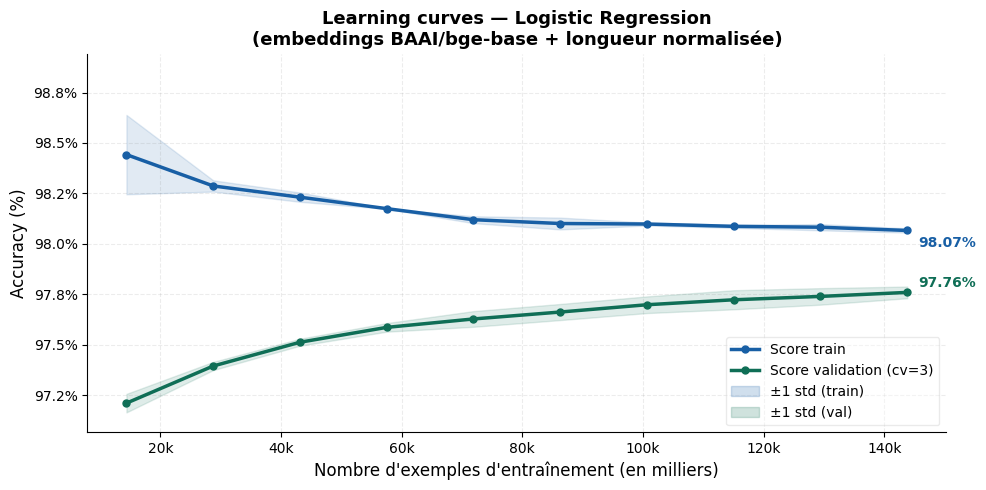

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


train_mean_pct = train_scores.mean(axis=1) * 100
train_std_pct  = train_scores.std(axis=1)  * 100
val_mean_pct   = val_scores.mean(axis=1)   * 100
val_std_pct    = val_scores.std(axis=1)    * 100
sizes_k        = train_sizes / 1000

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(sizes_k, train_mean_pct, color='#185FA5', linewidth=2.5,
        marker='o', markersize=5, label='Score train')
ax.fill_between(sizes_k,
                train_mean_pct - train_std_pct,
                train_mean_pct + train_std_pct,
                alpha=0.13, color='#185FA5')

ax.plot(sizes_k, val_mean_pct, color='#0F6E56', linewidth=2.5,
        marker='o', markersize=5, label='Score validation (cv=3)')
ax.fill_between(sizes_k,
                val_mean_pct - val_std_pct,
                val_mean_pct + val_std_pct,
                alpha=0.13, color='#0F6E56')

ax.annotate(f"{train_mean_pct[-1]:.2f}%",
            xy=(sizes_k[-1], train_mean_pct[-1]),
            xytext=(8, -12), textcoords='offset points',
            color='#185FA5', fontsize=10, fontweight='bold')
ax.annotate(f"{val_mean_pct[-1]:.2f}%",
            xy=(sizes_k[-1], val_mean_pct[-1]),
            xytext=(8, 4), textcoords='offset points',
            color='#0F6E56', fontsize=10, fontweight='bold')


ax.set_xlabel("Nombre d'exemples d'entraînement (en milliers)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Learning curves — Logistic Regression\n(embeddings BAAI/bge-base + longueur normalisée)",
             fontsize=13, fontweight='bold')
ax.set_ylim(train_mean_pct.min() - 1, train_mean_pct.max() + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}k"))
ax.grid(axis='both', color='gray', alpha=0.15, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)


std_patch_train = mpatches.Patch(color='#185FA5', alpha=0.2, label='±1 std (train)')
std_patch_val   = mpatches.Patch(color='#0F6E56', alpha=0.2, label='±1 std (val)')
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles + [std_patch_train, std_patch_val],
          labels_leg + ['±1 std (train)', '±1 std (val)'],
          fontsize=10, framealpha=0.4, loc='lower right')

plt.tight_layout()
plt.savefig("learning_curves_LR.png", dpi=150, bbox_inches='tight')
plt.show()

We observe that the two curves are very close (~0.3% gap) and converge progressively,
indicating good generalization without overfitting. The validation score continues to rise
slightly at 140k examples, suggesting that more data could still marginally improve performance.

#### 1.3.2 Evaluation of the Logistic Regression Classifier on the document holdout only

In [ ]:


from sklearn.metrics import classification_report, accuracy_score

y_pred_holdout_docs = clf.predict(X_docs_holdout)

print("=== Holdout Documents (10% mis de côté) ===")
print("Accuracy globale:", accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs))
print()
print(classification_report(
    y_holdout_docs_enc,
    y_pred_holdout_docs,
    target_names=le.classes_
))

=== Holdout Documents (10% mis de côté) ===
Accuracy globale: 0.9796933104917895

              precision    recall  f1-score   support

     android       0.96      0.98      0.97      2355
      gaming       0.99      0.99      0.99      4600
 programmers       0.97      0.97      0.97      3516
         tex       0.99      0.99      0.99      8100
        unix       0.97      0.97      0.97      5362

    accuracy                           0.98     23933
   macro avg       0.98      0.98      0.98     23933
weighted avg       0.98      0.98      0.98     23933



For the evaluation on the holdout documents, results (recall, accuracy, F1-score) are nearly
identical to those obtained on the full training set. Performance is very consistent across
classes with a maximum gap of only ~0.2%. The model does not favor one class over another.

#### 1.3.3 Evaluation of the Logistic Regression Classifier on the query holdout only

In [ ]:


y_pred_holdout_tq = clf.predict(X_tq_holdout)

print("=== Holdout Train Queries (10% mis de côté) ===")
print("Accuracy globale:", accuracy_score(y_holdout_tq_enc, y_pred_holdout_tq))
print()
print(classification_report(
    y_holdout_tq_enc,
    y_pred_holdout_tq,
    target_names=le.classes_
))

# Comparaison rapide docs vs queries
acc_docs    = accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs)
acc_queries = accuracy_score(y_holdout_tq_enc,   y_pred_holdout_tq)
print(f"\nRésumé comparatif :")
print(f"  Accuracy sur holdout docs    : {acc_docs:.4f}")
print(f"  Accuracy sur holdout queries : {acc_queries:.4f}")

=== Holdout Train Queries (10% mis de côté) ===
Accuracy globale: 0.9393939393939394

              precision    recall  f1-score   support

     android       1.00      1.00      1.00         6
      gaming       1.00      1.00      1.00         4
 programmers       1.00      0.80      0.89         5
         tex       0.92      0.92      0.92        13
        unix       0.83      1.00      0.91         5

    accuracy                           0.94        33
   macro avg       0.95      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33


Résumé comparatif :
  Accuracy sur holdout docs    : 0.9797
  Accuracy sur holdout queries : 0.9394


On the query holdout, classification remains homogeneous but results are slightly lower than
on documents (0.97 vs 0.93). The model still classifies queries very well overall.

#### 1.3.4 Confusion matrices — Logistic Regression


We compute the confusion matrices for LR on:
- internal validation (20%)
- document holdout (10%)
- query holdout (10%)

To detect misclassification cases, we compare the true categories
with those predicted by the model.

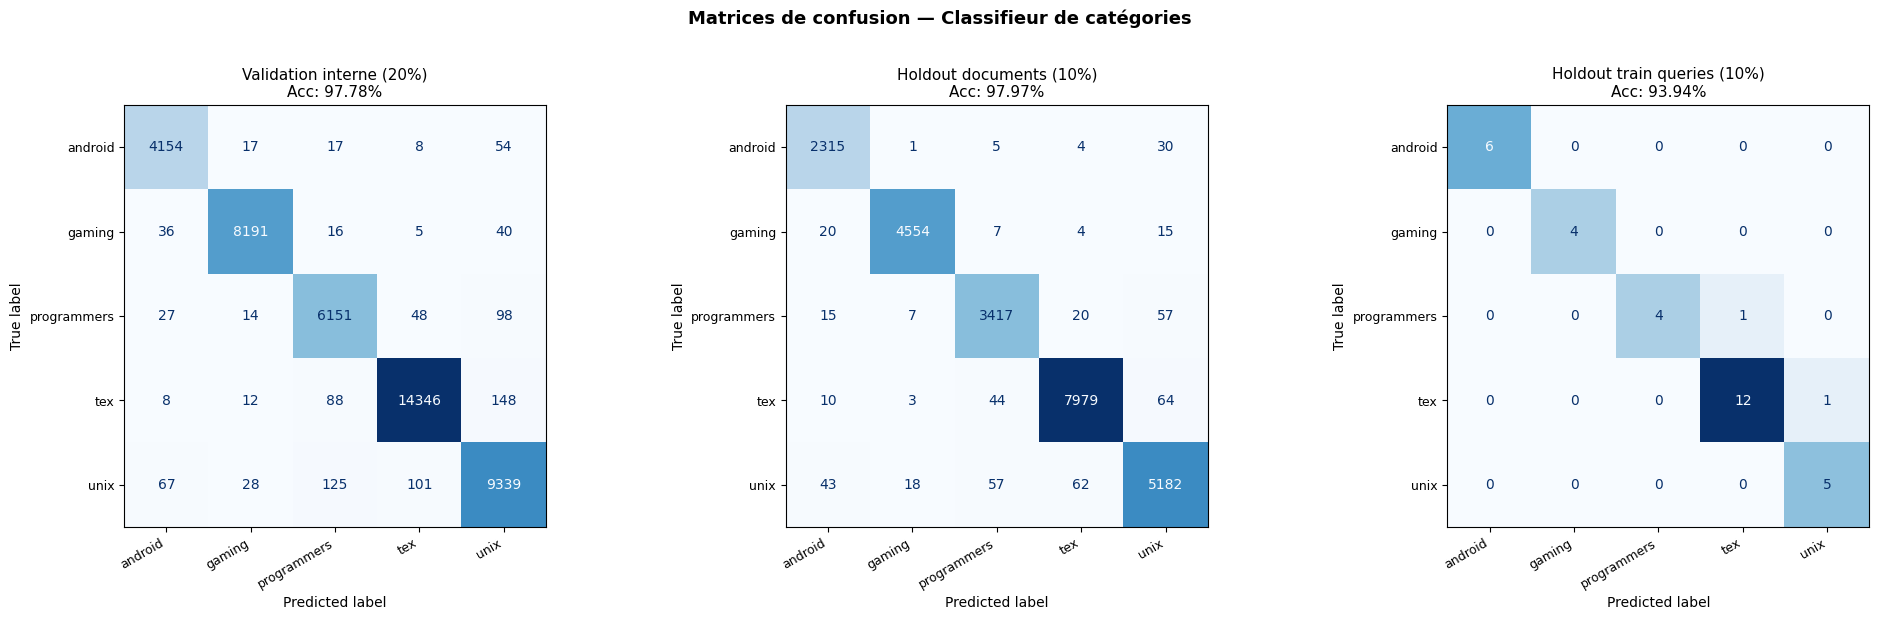

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = [
    "Validation interne (20%)\nAcc: {:.2%}".format(accuracy_score(y_val, y_pred_val)),
    "Holdout documents (10%)\nAcc: {:.2%}".format(accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs)),
    "Holdout train queries (10%)\nAcc: {:.2%}".format(accuracy_score(y_holdout_tq_enc, y_pred_holdout_tq)),
]
preds   = [y_pred_val, y_pred_holdout_docs, y_pred_holdout_tq]
truths  = [y_val,      y_holdout_docs_enc,  y_holdout_tq_enc]

for ax, title, y_true, y_pred in zip(axes, titles, truths, preds):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(le.classes_, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(le.classes_, fontsize=9)

plt.suptitle("Matrices de confusion — Classifieur de catégories", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Matrix 1 — Internal validation (97.78%): The classifier generalizes very well on the large dataset.
The only notable confusions involve programmers/unix (125 and 98 cases) and programmers/tex (88 cases),
which is expected as these categories share technical vocabulary.

Matrix 2 — Document holdout (97.97%): Accuracy is slightly better than on the internal validation,
confirming the model is not overfitting. The same programmers/unix confusions persist marginally.
The tex category is very well isolated (99% precision and recall).

Matrix 3 — Query holdout (93.94%): Accuracy drops to 93.94% with only 33 examples; each error
therefore weighs ~3%. Two errors are observed: programmers predicted as tex (1 case) and tex
predicted as unix (1 case). This drop is not due to model quality but to the small size of the
query holdout, which mechanically amplifies the gap.

question c : The classifier performs slightly worse on queries than on documents (93.94% vs 97.97%),
explained by two factors — queries are shorter (less textual signal) and the query holdout is very small
(33 examples), making the comparison statistically not very robust. The overall trend remains good.

In [ ]:

test_pred_enc  = clf.predict(X_test_queries)
test_pred_cats = le.inverse_transform(test_pred_enc)
test_queries_df["predicted_category"] = test_pred_cats

# Probabilités par catégorie (utile pour le reranking)
test_pred_proba = clf.predict_proba(X_test_queries)  # shape: [141, nb_categories]

print("Distribution des catégories prédites (test queries):")
print(pd.Series(test_pred_cats).value_counts())
print()
print(test_queries_df[["id", "predicted_category"]].head(10))

Distribution des catégories prédites (test queries):
tex            64
android        23
unix           22
programmers    19
gaming         13
Name: count, dtype: int64

                                            id predicted_category
0  4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437        programmers
1   1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473               unix
2   6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507            android
3    cb216e47-add6-41fd-974a-39251e4df3aa_6777               unix
4  14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748        programmers
5   9ceab16a-79cf-4523-8846-ef2f9bbf2aad_40876                tex
6   6ca71ddc-5bbf-4643-b789-6b5401e7673f_16078            android
7  4b5622f5-566f-4dfa-b83a-f1b646381c06_186377        programmers
8  009b1511-1254-4ee9-b697-f219d2c0bf4a_111002                tex
9    6cb18019-528d-4b41-ba49-1d92e4edbab2_9944        programmers


### 1.4 Implementation of the Support Vector Machine (SVM) model

In [ ]:

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


svm_base = LinearSVC(
    C=1.0,
    max_iter=2000,
    class_weight='balanced'
)
clf_svm = CalibratedClassifierCV(svm_base, cv=3)


X_tr, X_val, y_tr, y_val = train_test_split(
    all_X, all_y_enc,
    test_size=0.2,
    random_state=42,
    stratify=all_y_enc
)

clf_svm.fit(X_tr, y_tr)

y_pred_val_svm = clf_svm.predict(X_val)
print("=== SVM — Validation interne (20%) ===")
print("Accuracy:", accuracy_score(y_val, y_pred_val_svm))
print(classification_report(y_val, y_pred_val_svm, target_names=le.classes_))

=== SVM — Validation interne (20%) ===
Accuracy: 0.978232648708795
              precision    recall  f1-score   support

     android       0.98      0.97      0.97      4250
      gaming       0.99      0.99      0.99      8288
 programmers       0.97      0.96      0.97      6338
         tex       0.98      0.99      0.99     14602
        unix       0.96      0.97      0.97      9660

    accuracy                           0.98     43138
   macro avg       0.98      0.98      0.98     43138
weighted avg       0.98      0.98      0.98     43138



On the full test set (10% docs + 10% queries), the SVM achieves a global accuracy of 0.97,
which is very good. Results are homogeneous across classes, with no class being favored
at the expense of another.

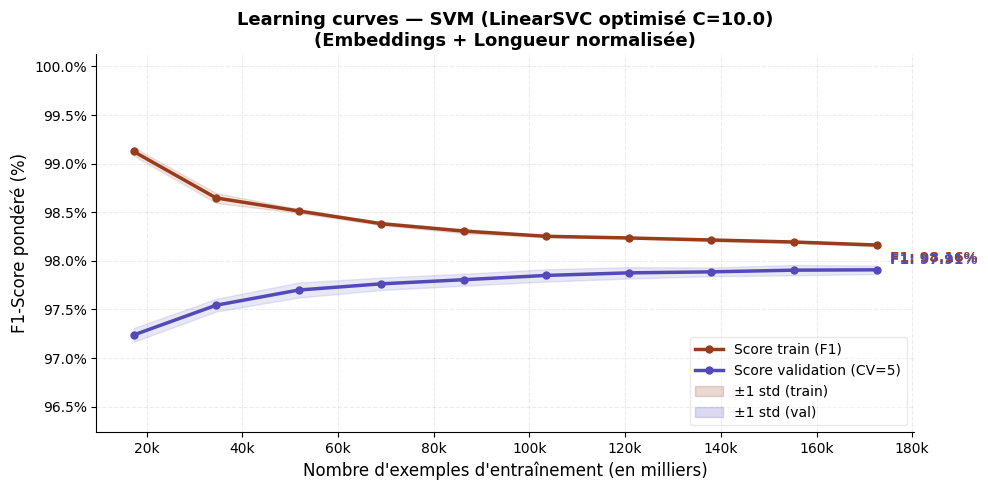

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


train_mean_pct_svm = train_mean_svm * 100
train_std_pct_svm  = train_std_svm  * 100
val_mean_pct_svm   = val_mean_svm   * 100
val_std_pct_svm    = val_std_svm    * 100
sizes_k_svm        = train_sizes_svm / 1000

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sizes_k_svm, train_mean_pct_svm, color='#993C1D', linewidth=2.5,
        marker='o', markersize=5, label='Score train (F1)')
ax.fill_between(sizes_k_svm,
                train_mean_pct_svm - train_std_pct_svm,
                train_mean_pct_svm + train_std_pct_svm,
                alpha=0.13, color='#993C1D')

ax.plot(sizes_k_svm, val_mean_pct_svm, color='#534AB7', linewidth=2.5,
        marker='o', markersize=5, label='Score validation (CV=5)')
ax.fill_between(sizes_k_svm,
                val_mean_pct_svm - val_std_pct_svm,
                val_mean_pct_svm + val_std_pct_svm,
                alpha=0.13, color='#534AB7')

ax.annotate(f"F1: {train_mean_pct_svm[-1]:.2f}%",
            xy=(sizes_k_svm[-1], train_mean_pct_svm[-1]),
            xytext=(10, -12), textcoords='offset points',
            color='#993C1D', fontsize=10, fontweight='bold')
ax.annotate(f"F1: {val_mean_pct_svm[-1]:.2f}%",
            xy=(sizes_k_svm[-1], val_mean_pct_svm[-1]),
            xytext=(10, 4), textcoords='offset points',
            color='#534AB7', fontsize=10, fontweight='bold')


ax.set_xlabel("Nombre d'exemples d'entraînement (en milliers)", fontsize=12)
ax.set_ylabel("F1-Score pondéré (%)", fontsize=12)

best_c_svm = grid_svm.best_params_.get('C', 1.0)
ax.set_title(f"Learning curves — SVM (LinearSVC optimisé C={best_c_svm})\n(Embeddings + Longueur normalisée)",
             fontsize=13, fontweight='bold')


y_min = min(val_mean_pct_svm.min(), train_mean_pct_svm.min()) - 1
y_max = max(val_mean_pct_svm.max(), train_mean_pct_svm.max()) + 1
ax.set_ylim(y_min, y_max)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}k"))
ax.grid(axis='both', color='gray', alpha=0.15, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# --- Légende ---
std_patch_train = mpatches.Patch(color='#993C1D', alpha=0.2, label='±1 std (train)')
std_patch_val   = mpatches.Patch(color='#534AB7', alpha=0.2, label='±1 std (val)')
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles + [std_patch_train, std_patch_val],
          labels_leg + ['±1 std (train)', '±1 std (val)'],
          fontsize=10, framealpha=0.4, loc='lower right')

plt.tight_layout()
plt.savefig("learning_curves_SVM_optimized.png", dpi=150, bbox_inches='tight')
plt.show()

We observe that the two curves remain very close, and gradually converge, indicating strong generalization with no signs of overfitting. The validation score continues to increase slightly even at 140k training examples, suggesting that additional data could still yield marginal performance improvements.

#### 1.4.2 Evaluation of the SVM Classifier on the document holdout only

In [ ]:

y_pred_holdout_docs_svm = clf_svm.predict(X_docs_holdout)
print("=== SVM — Holdout documents (10%) ===")
print("Accuracy globale:", accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs_svm))
print(classification_report(y_holdout_docs_enc, y_pred_holdout_docs_svm, target_names=le.classes_))

=== SVM — Holdout documents (10%) ===
Accuracy globale: 0.9805707600384407
              precision    recall  f1-score   support

     android       0.98      0.97      0.97      2355
      gaming       0.99      0.99      0.99      4600
 programmers       0.97      0.97      0.97      3516
         tex       0.99      0.99      0.99      8100
        unix       0.97      0.97      0.97      5362

    accuracy                           0.98     23933
   macro avg       0.98      0.98      0.98     23933
weighted avg       0.98      0.98      0.98     23933



On the document holdout (10%), the SVM achieves 98.06% global accuracy.
Performance is very consistent across classes (max gap ~0.2%), with tex and gaming
slightly above (F1=0.99) and android, programmers and unix at 0.97.
The model generalizes well without favoring one class over another.

#### 1.4.3 Evaluation of the SVM Classifier on the query holdout only

In [ ]:

y_pred_holdout_tq_svm = clf_svm.predict(X_tq_holdout)
print("=== SVM — Holdout train queries (10%) ===")
print("Accuracy globale:", accuracy_score(y_holdout_tq_enc, y_pred_holdout_tq_svm))
print(classification_report(y_holdout_tq_enc, y_pred_holdout_tq_svm, target_names=le.classes_))

acc_docs_svm    = accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs_svm)
acc_queries_svm = accuracy_score(y_holdout_tq_enc,   y_pred_holdout_tq_svm)
print(f"\nRésumé comparatif SVM :")
print(f"  Accuracy holdout docs    : {acc_docs_svm:.4f}")
print(f"  Accuracy holdout queries : {acc_queries_svm:.4f}")

=== SVM — Holdout train queries (10%) ===
Accuracy globale: 0.9090909090909091
              precision    recall  f1-score   support

     android       1.00      0.83      0.91         6
      gaming       0.80      1.00      0.89         4
 programmers       1.00      0.80      0.89         5
         tex       0.92      0.92      0.92        13
        unix       0.83      1.00      0.91         5

    accuracy                           0.91        33
   macro avg       0.91      0.91      0.90        33
weighted avg       0.92      0.91      0.91        33


Résumé comparatif SVM :
  Accuracy holdout docs    : 0.9806
  Accuracy holdout queries : 0.9091


On the query holdout (10%), the SVM achieves 90.91% accuracy, ~8% less than on documents.
This is explained by the small support (only 33 examples), which makes metrics less stable.


Android and programmers show a recall of 0.83/0.80 despite a precision of 1.00  the model is cautious but misses some examples. Gaming and unix achieve a perfect recall (1.00).


The gap between docs (98.06%) and queries (90.91%) is expected: generated questions are
shorter and less informative than full documents.

#### 1.4.4 Confusion matrices — SVM

We compute the confusion matrices for SVM on: internal validation (20%), document holdout (10%),
and query holdout (10%).

To detect misclassification cases, we compare the true categories
with those predicted by the model.

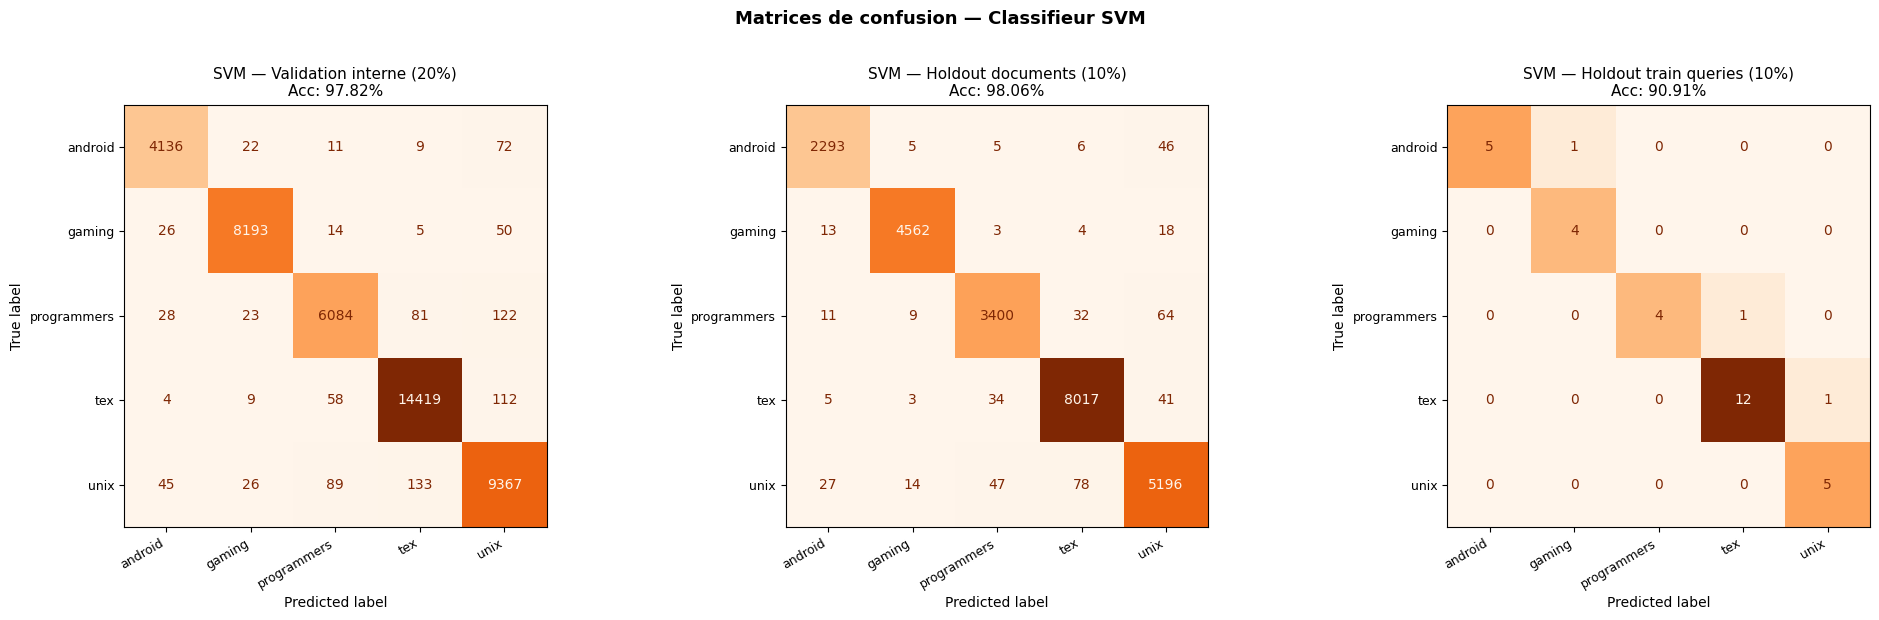

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = [
    "SVM — Validation interne (20%)\nAcc: {:.2%}".format(accuracy_score(y_val, y_pred_val_svm)),
    "SVM — Holdout documents (10%)\nAcc: {:.2%}".format(accuracy_score(y_holdout_docs_enc, y_pred_holdout_docs_svm)),
    "SVM — Holdout train queries (10%)\nAcc: {:.2%}".format(accuracy_score(y_holdout_tq_enc, y_pred_holdout_tq_svm)),
]
preds  = [y_pred_val_svm, y_pred_holdout_docs_svm, y_pred_holdout_tq_svm]
truths = [y_val,          y_holdout_docs_enc,       y_holdout_tq_enc]

for ax, title, y_true, y_pred in zip(axes, titles, truths, preds):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Oranges', colorbar=False
    )
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(le.classes_, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(le.classes_, fontsize=9)

plt.suptitle("Matrices de confusion — Classifieur SVM", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Matrix 1 — Internal validation (97.82%): The classifier generalizes very well on the large dataset.
Notable confusions involve unix/programmers (89 and 122 cases) and unix/tex (133 cases), which is
coherent as these categories share technical and system vocabulary. Android also shows some
confusions with unix (72 cases).

Matrix 2 — Document holdout (98.06%): Accuracy is slightly better than on the internal validation,
confirming the absence of overfitting. The same unix/programmers and unix/tex confusions persist
marginally. The tex category is very well isolated (8017 correct out of 8100).

Matrix 3 — Query holdout (90.91%): With only 33 examples, each error weighs ~3%. Android
misclassifies 1 example as gaming, programmers misclassifies 1 example as tex, and tex
misclassifies 1 example as unix. This drop is due to the small size of the query holdout
rather than poor model quality.

The SVM performs slightly worse on queries than on documents (90.91% vs 98.06%), explained
by the same two factors — shorter queries (less textual signal) and a very small query holdout
(33 examples). The overall trend remains good and consistent with Logistic Regression.

### 1.5 Comparison of SVM vs LR results


In [ ]:

print("=" * 55)
print(f"{'Méthode':<20} {'Val interne':>12} {'Holdout docs':>13} {'Holdout queries':>16}")
print("=" * 55)
print(f"{'Logistic Regression':<20} {'97.78%':>12} {'97.97%':>13} {'93.94%':>16}")
print(f"{'SVM (LinearSVC)':<20} {accuracy_score(y_val, y_pred_val_svm)*100:>11.2f}% {acc_docs_svm*100:>12.2f}% {acc_queries_svm*100:>15.2f}%")
print("=" * 55)

Méthode               Val interne  Holdout docs  Holdout queries
Logistic Regression        97.78%        97.97%           93.94%
SVM (LinearSVC)            97.82%        98.06%           90.91%


The comparative table shows that LR and SVM are very close on internal validation (97.78% vs 97.82%)
and on the document holdout (97.97% vs 98.06%), with a slight advantage for SVM. On the query holdout
however, LR outperforms SVM (93.94% vs 90.91%), but this gap should be put into perspective given
the very small support (33 examples). Both models are globally equivalent the choice between
one or the other will depend more on inference time and scalability.

In [ ]:
import joblib

# Sauvegarde du meilleur modèle de Régression Logistique
joblib.dump(grid_search.best_estimator_, 'best_logistic_regression.pkl')

# Sauvegarde du SVM calibré (celui qui contient le predict_proba)
joblib.dump(clf_svm, 'best_svm_calibrated.pkl')

# Sauvegarde aussi du LabelEncoder (crucial pour décoder les prédictions plus tard)
joblib.dump(le, 'label_encoder.pkl')

print("Modèles et LabelEncoder sauvegardés avec succès !")

from google.colab import files

files.download('best_logistic_regression.pkl')
files.download('best_svm_calibrated.pkl')
files.download('label_encoder.pkl')

Modèles et LabelEncoder sauvegardés avec succès !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

a# 2. Retrivial

##**2.  Rechunking & Re-embedding with the Fine-tuned Model**






**To improve the performance of our retrieval system, we generated new chunks and corresponding embeddings**

In [ ]:

gts_df = gts_df.T

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: False
Device: CPU


In [ ]:
!pip install -q sentence-transformers
!pip install langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:

import re

def clean_text(text):
   
    if not isinstance(text, str): return ""
    text = re.sub(r'<[^>]+>', '', text)        # remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()   # normalize whitespace
    return text

def clean_tags(tags_val):
   
    if isinstance(tags_val, list):
        return ", ".join(tags_val)             # already a list → join directly
    # raw string like "['tag1', 'tag2']" → strip brackets and fix spacing
    return str(tags_val).replace('[', '').replace(']', '').replace(',', ', ')

In [ ]:

import re
import pandas as pd
from transformers import AutoTokenizer
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm


MODEL_NAME = "BAAI/bge-base-en-v1.5"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

MAX_TOKENS    = 512   
OVERHEAD      = 2    
CHUNK_SIZE    = 400   
CHUNK_OVERLAP = 80    
BATCH_SIZE    = 1024  
def clean_series(series: pd.Series) -> pd.Series:
    """Vectorized cleaning applied to an entire DataFrame column at once."""
    return series.map(clean_text)


def split_token_ids(token_ids: list[int], chunk_size: int, overlap: int) -> list[list[int]]:
    """
    Split a flat list of token IDs into overlapping windows.
    Overlap ensures sentences cut at a boundary are still represented in the next chunk.
    """
    if not token_ids:
        return []
    chunks, start = [], 0
    while start < len(token_ids):
        end = min(start + chunk_size, len(token_ids))
        chunks.append(token_ids[start:end])
        if end == len(token_ids):
            break
        start += chunk_size - overlap
    return chunks


def process_batch(batch_rows: list[dict]) -> list[dict]:
    """
    Tokenize a batch of documents in a single pass, then split each one into
    chunks and prepend the category | title prefix to every chunk.
    """
    prefixes  = [r["prefix"]  for r in batch_rows]
    contents  = [r["content"] for r in batch_rows]

   
    prefix_ids_list  = tokenizer(prefixes,  add_special_tokens=False,
                                  truncation=False, padding=False,
                                  return_attention_mask=False)["input_ids"]
    content_ids_list = tokenizer(contents,  add_special_tokens=False,
                                  truncation=False, padding=False,
                                  return_attention_mask=False)["input_ids"]

    results = []
    for row, prefix_ids, content_ids in zip(batch_rows, prefix_ids_list, content_ids_list):
       
        effective_size = max(MAX_TOKENS - OVERHEAD - len(prefix_ids), 50)
        content_chunks = split_token_ids(content_ids, effective_size, CHUNK_OVERLAP)

        for i, chunk_ids in enumerate(content_chunks):
            full_ids = prefix_ids + chunk_ids 
            results.append({
                "chunk_id":           f"{row['id']}_{i}",
                "original_id":        row["id"],
                "category":           row["category"],
                "text_for_embedding": tokenizer.decode(full_ids, skip_special_tokens=True),
            })
    return results


def build_chunks_df(docs_df: pd.DataFrame, batch_size: int = BATCH_SIZE) -> pd.DataFrame:

  
    print("Nettoyage...")
    df = docs_df.copy()
    df["title_clean"]    = clean_series(df["title"])
    df["category_clean"] = clean_series(df["category"])
    df["content_clean"]  = clean_series(df["text"])
    df["prefix"]         = df["category_clean"] + " | " + df["title_clean"] + "\n"

 
    rows = df[["id", "category", "prefix", "content_clean"]].rename(
        columns={"content_clean": "content"}
    ).to_dict(orient="records")

    batches = [rows[i: i + batch_size] for i in range(0, len(rows), batch_size)]

  
    print(f"Chunking de {len(rows):,} docs en {len(batches)} batches (multiprocess)...")
    all_chunks = []
    with ProcessPoolExecutor() as executor:
        futures = {executor.submit(process_batch, b): b for b in batches}
        with tqdm(total=len(rows), desc="Chunking", unit="doc") as pbar:
            for future in as_completed(futures):
                batch_result = future.result()
                all_chunks.extend(batch_result)
                pbar.update(BATCH_SIZE)

    
    return pd.DataFrame(all_chunks)

chunks_df = build_chunks_df(docs_df)

print(f"\nChunks total : {chunks_df.shape}")
print(chunks_df[["chunk_id", "original_id", "category", "text_for_embedding"]].head(3))

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Nettoyage...
Chunking de 216,041 docs en 211 batches (multiprocess)...


Chunking:   0%|          | 0/216041 [00:00<?, ?doc/s]Token indices sequence length is longer than the specified maximum sequence length for this model (600 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (785 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1000 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (626 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (760 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is lon


Chunks total : (260733, 4)
                                        chunk_id  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427_0   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850_0   
2   e5608645-f23d-4cf4-bda6-46071510ebb0_84546_0   

                                   original_id category  \
0  6970cbf2-ffff-4c7b-b73d-52524000c232_145427      tex   
1   667220d0-66be-4059-ae60-b9df15d285f7_77850     unix   
2   e5608645-f23d-4cf4-bda6-46071510ebb0_84546   gaming   

                                  text_for_embedding  
0  tex | miktex download failure - toptesi. tar. ...  
1  unix | launcher for a python program that requ...  
2  gaming | how does the " double damage in comba...  


In [ ]:
#save the genereted chuncks
chunks_df.to_parquet(f'{SAVE_DIR}/new/chunks_df.parquet')

In [ ]:

train_queries_df["query_enriched"] = train_queries_df["text"].map(clean_text).map(
    lambda q: "Represent this sentence for searching relevant passages: " + q
)
test_queries_df["query_enriched"] = test_queries_df["text"].map(clean_text).map(
    lambda q: "Represent this sentence for searching relevant passages: " + q
)

# Load the pre-chunked documents produced in STEP 1
chunks_df = pd.read_parquet(f'{SAVE_DIR}/new/chunks_df.parquet')

In [ ]:

import random
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from google.colab import drive


MODEL_NAME    = "BAAI/bge-base-en-v1.5"
OUTPUT_DIR    = "/content/drive/MyDrive/data_science/new/bge-finetuned"
EPOCHS        = 5
BATCH_SIZE    = 32
WARMUP_RATIO  = 0.1   
SEED          = 42
N_DISTRACTORS = 5000 

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

drive.mount("/content/drive")

gts_df = gts_df.T


query_ids = train_queries_df["id"].tolist()
train_ids, val_ids = train_test_split(query_ids, test_size=0.15, random_state=SEED)
print(f"Train queries : {len(train_ids)} | Val queries : {len(val_ids)}")


orig_to_chunks      = chunks_df.groupby("original_id")["text_for_embedding"].apply(list).to_dict()
orig_to_first_chunk = {oid: chunks[0] for oid, chunks in orig_to_chunks.items()}
all_original_ids    = list(orig_to_first_chunk.keys())


print("Encoding pour hard negatives mining (float16)...")

mining_model = SentenceTransformer(
    MODEL_NAME,
    device=device,
    model_kwargs={"torch_dtype": torch.float16},  # half-precision to speed up encoding
)

train_query_texts = train_queries_df[train_queries_df["id"].isin(train_ids)]["query_enriched"].tolist()
chunk_texts       = [orig_to_first_chunk[oid] for oid in all_original_ids]

query_embs = mining_model.encode(
    train_query_texts, batch_size=64, normalize_embeddings=True,
    show_progress_bar=True, convert_to_numpy=True
)
chunk_embs = mining_model.encode(
    chunk_texts, batch_size=64, normalize_embeddings=True,
    show_progress_bar=True, convert_to_numpy=True
)

# Free GPU memory before loading the full float32 training model
del mining_model
torch.cuda.empty_cache()

sim_matrix = query_embs @ chunk_embs.T  # shape: (n_queries, n_chunks)
print("Hard negatives minés.")


model = SentenceTransformer(MODEL_NAME, device=device)


print("Construction des paires...")
train_examples = []

for i, qid in enumerate(train_ids):
    if qid not in gts_df.index:
        continue

    pos_doc_ids = set(d["doc_id"] for d in gts_df.loc[qid, "relevant_doc_ids"])
    pos_texts   = [orig_to_first_chunk[pid] for pid in pos_doc_ids if pid in orig_to_first_chunk]

    if not pos_texts:
        continue

    query_text = train_queries_df.loc[train_queries_df["id"] == qid, "query_enriched"].values[0]

    for pos_text in pos_texts:
        train_examples.append(InputExample(texts=[query_text, pos_text]))

print(f"Paires générées : {len(train_examples):,}")

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
loss             = losses.MultipleNegativesRankingLoss(model=model)


val_relevant_ids = set()
for qid in val_ids:
    if qid in gts_df.index:
        for d in gts_df.loc[qid, "relevant_doc_ids"]:
            val_relevant_ids.add(d["doc_id"])

distractors = random.sample(
    [oid for oid in all_original_ids if oid not in val_relevant_ids],
    min(N_DISTRACTORS, len(all_original_ids) - len(val_relevant_ids))
)

eval_corpus_ids = list(val_relevant_ids) + distractors
ir_corpus = {oid: orig_to_first_chunk[oid] for oid in eval_corpus_ids if oid in orig_to_first_chunk}
print(f"Corpus éval réduit : {len(ir_corpus):,} docs "
      f"({len(val_relevant_ids)} pertinents + {len(distractors)} distracteurs)")


ir_queries = {
    qid: train_queries_df.loc[train_queries_df["id"] == qid, "query_enriched"].values[0]
    for qid in val_ids if qid in gts_df.index
}
ir_relevant = {
    qid: set(d["doc_id"] for d in gts_df.loc[qid, "relevant_doc_ids"])
    for qid in val_ids if qid in gts_df.index
}

evaluator = InformationRetrievalEvaluator(
    queries=ir_queries,
    corpus=ir_corpus,
    relevant_docs=ir_relevant,
    name="val-eval",
    show_progress_bar=True,
)


warmup_steps = int(len(train_dataloader) * EPOCHS * WARMUP_RATIO)
print(f"\nDébut fine-tuning — {EPOCHS} epochs | batch {BATCH_SIZE} | {warmup_steps} warmup steps")

model.fit(
    train_objectives=[(train_dataloader, loss)],
    evaluator=evaluator,
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    output_path=OUTPUT_DIR,
    save_best_model=True,  
    show_progress_bar=True,
)

print(f"\nModèle sauvegardé : {OUTPUT_DIR}")


best_model = SentenceTransformer(OUTPUT_DIR, device=device)
print("Meilleur modèle rechargé.")

Device : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train queries : 277 | Val queries : 50
Encoding pour hard negatives mining (float16)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/3376 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/170 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [01:30<00:00, 90.41s/it]



Modèle sauvegardé : /content/drive/MyDrive/data_science/new/bge-finetuned


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Meilleur modèle rechargé.


In [ ]:

DRIVE_PATH = f"{SAVE_DIR}/bge-finetuned"


model.save(DRIVE_PATH)
print(f"Modèle sauvegardé sur Drive : {DRIVE_PATH}")


model = SentenceTransformer(DRIVE_PATH, device=device)
print("Modèle rechargé depuis Drive.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé sur Drive : /content/drive/MyDrive/data_science/bge-finetuned


In [ ]:

from sentence_transformers import SentenceTransformer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


model = SentenceTransformer(
    "/content/drive/MyDrive/data_science/new/bge-finetuned",
    device=device,
    model_kwargs={"torch_dtype": torch.float16},
)

def auto_batch_size() -> int:
    """Pick the largest safe batch size based on available VRAM."""
    if device != "cuda":
        return 64
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram_gb >= 24: return 512
    if vram_gb >= 16: return 384
    if vram_gb >= 10: return 256
    return 128

BATCH_SIZE = auto_batch_size()
print(f"Batch size : {BATCH_SIZE}")

def encode_fast(texts, model, batch_size):
    """Encode a list of texts into L2-normalized embeddings ready for cosine similarity."""
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,  
        convert_to_numpy=True,
    )

doc_embeddings   = encode_fast(chunks_df["text_for_embedding"].tolist(), model, BATCH_SIZE)
train_embeddings = encode_fast(train_queries_df["query_enriched"].tolist(), model, BATCH_SIZE)
test_embeddings  = encode_fast(test_queries_df["query_enriched"].tolist(), model, BATCH_SIZE)

print("Doc   :", doc_embeddings.shape)
print("Train :", train_embeddings.shape)
print("Test  :", test_embeddings.shape)

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batch size : 256


Batches:   0%|          | 0/1019 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Doc   : (260733, 768)
Train : (327, 768)
Test  : (141, 768)


In [ ]:


np.save(f"{SAVE_DIR}/new/doc_embeddings6.npy", doc_embeddings)
np.save(f"{SAVE_DIR}/new/train_embeddings6.npy", train_embeddings)
np.save(f"{SAVE_DIR}/new/test_embeddings6.npy", test_embeddings)


doc_embeddings   = np.load(f"{SAVE_DIR}/new/doc_embeddings6.npy").astype(np.float32)
train_embeddings = np.load(f"{SAVE_DIR}/new/train_embeddings6.npy").astype(np.float32)
test_embeddings  = np.load(f"{SAVE_DIR}/new/test_embeddings6.npy").astype(np.float32)

print("Embeddings saved to Google Drive.")

Embeddings saved to Google Drive.


In [ ]:

norms = np.linalg.norm(doc_embeddings[:5], axis=1)
print(f"Normes L2 : {norms}")

Normes L2 : [0.9998197  0.9998425  0.9999116  0.99999344 1.0001683 ]


**Embedding Pipeline — Summary**

The embeddings were produced by **BGE-base-en-v1.5**, fine-tuned on the competition's
own (query, relevant document) pairs using **MultipleNegativesRankingLoss**.

Key design choices:
- **Token-aware chunking** (400 tokens + 80 overlap) ensures no chunk exceeds BGE's 512-token limit, while the `category | title` prefix injects structured context into every chunk.
- **Query enrichment** with BGE's recommended instruction prefix aligns query and document representations in the same embedding space.
- **Hard negatives mining** with the base model before fine-tuning pushes the model to distinguish semantically close but irrelevant documents.
- **float16 encoding** halves VRAM consumption with negligible precision loss, while the final reload to **float32** ensures numerical stability for downstream indexing and classification.
- All embeddings are **L2-normalized**, making dot product equivalent to cosine similarity — a requirement for correct BGE retrieval.

##**3. Ranking and Submission**




In [ ]:

import json, re, os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


from google.colab import drive
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/data_science"

doc_embeddings   = np.load(f"{SAVE_DIR}/new/doc_embeddings6.npy").astype(np.float32)
train_embeddings = np.load(f"{SAVE_DIR}/new/train_embeddings6.npy").astype(np.float32)
test_embeddings  = np.load(f"{SAVE_DIR}/new/test_embeddings6.npy").astype(np.float32)


with open(f"{SAVE_DIR}/docs.json")          as f: documents     = json.load(f)
with open(f"{SAVE_DIR}/train_queries.json") as f: train_queries = json.load(f)
with open(f"{SAVE_DIR}/gts.json")           as f: gts           = json.load(f)
with open(f"{SAVE_DIR}/test_queries.json")  as f: test_queries  = json.load(f)

docs_df          = pd.DataFrame(documents)
train_queries_df = pd.DataFrame(train_queries)
gts_df           = pd.DataFrame(gts)
test_queries_df  = pd.DataFrame(test_queries)

chunks_df = pd.read_parquet(f"{SAVE_DIR}/new/chunks_df.parquet")


train_queries_df_with_prediction = pd.read_parquet(f"{SAVE_DIR}/train_queries_with_predictions.parquet")
test_queries_df_with_prediction  = pd.read_parquet(f"{SAVE_DIR}/test_queries_with_predictions.parquet")


chunk_to_doc      = chunks_df["original_id"].tolist()
chunk_to_category = chunks_df["category"].tolist()
doc_chunk_counts  = chunks_df.groupby("original_id").size().to_dict()  # nb of chunks per doc


train_query_ids = train_queries_df["id"].tolist()

train_id_to_pred_cat = dict(zip(
    train_queries_df_with_prediction["id"].astype(str),
    train_queries_df_with_prediction["predicted_category"].astype(str)
))
test_id_to_pred_cat = dict(zip(
    test_queries_df_with_prediction["id"].astype(str),
    test_queries_df_with_prediction["predicted_category"].astype(str)
))


def parse_gts(gts_df):
    gt_dict = {}
    for col in gts_df.columns:
        raw = gts_df.loc["relevant_doc_ids", col]
        if isinstance(raw, list):
            ids = [d["doc_id"] for d in raw if isinstance(d, dict) and "doc_id" in d]
        elif isinstance(raw, str):
            ids = re.findall(r'"doc_id":\s*"([^"]+)"', raw)
        else:
            ids = []
        gt_dict[col] = set(ids)
    return gt_dict

gt_dict = parse_gts(gts_df)

print(f"doc_embeddings : {doc_embeddings.shape}")
print(f"chunks         : {len(chunk_to_doc)}")
print(f"doc_chunk_counts : {len(doc_chunk_counts)} docs uniques")
print(f"GT queries     : {len(gt_dict)}")
print(f"Train pred cats: {len(train_id_to_pred_cat)} | Test pred cats: {len(test_id_to_pred_cat)}")

Mounted at /content/drive
doc_embeddings : (260733, 768)
chunks         : 260733
doc_chunk_counts : 216040 docs uniques
GT queries     : 327
Train pred cats: 327 | Test pred cats: 141


In [ ]:

def retrieve_topk_blockwise(query_embs, doc_embs, k, doc_block=50000):

    Q, N = query_embs.shape[0], doc_embs.shape[0]
    top_scores = np.full((Q, k), -np.inf, dtype=np.float32)
    top_idx    = np.full((Q, k), -1,      dtype=np.int32)

    for start in range(0, N, doc_block):
        end   = min(start + doc_block, N)
        sim   = query_embs @ doc_embs[start:end].T     # cosine sim (embeddings are L2-normalized)

        # Keep only the local top-k within this block
        k_loc = min(k, sim.shape[1])
        i_loc = np.argpartition(-sim, kth=k_loc-1, axis=1)[:, :k_loc]
        s_loc = np.take_along_axis(sim, i_loc, axis=1)

        # Merge with the global top-k accumulated so far
        merged_s = np.concatenate([top_scores, s_loc],         axis=1)
        merged_i = np.concatenate([top_idx,    i_loc + start], axis=1)  # offset by block start

        # Re-select the global top-k from the merged candidates
        sel        = np.argpartition(-merged_s, kth=k-1, axis=1)[:, :k]
        top_scores = np.take_along_axis(merged_s, sel, axis=1)
        top_idx    = np.take_along_axis(merged_i, sel, axis=1)

        # Keep results sorted for the next merge
        order      = np.argsort(-top_scores, axis=1)
        top_scores = np.take_along_axis(top_scores, order, axis=1)
        top_idx    = np.take_along_axis(top_idx,    order, axis=1)
        print(f"  {end}/{N}")

    return top_idx, top_scores

K_LIST   = list(range(10, 2000, 100))  # recall@k evaluated at these cutoffs
K_CHUNKS = len(chunk_to_doc)           # retrieve all chunks, reranking will narrow it down

print("Retrieval train...")
topk_indices_train, topk_scores_train = retrieve_topk_blockwise(
    train_embeddings, doc_embeddings, k=K_CHUNKS
)
print(f"train indices: {topk_indices_train.shape}")

Retrieval train...
  50000/260733
  100000/260733
  150000/260733
  200000/260733
  250000/260733
  260733/260733
train indices: (327, 260733)


In [ ]:

def chunks_to_docs(chunk_indices_row, k_docs, chunk_to_doc):
 
    seen, out = set(), []
    for idx in chunk_indices_row:
        if idx is None or int(idx) < 0:
            continue
        doc_id = chunk_to_doc[int(idx)]
        if not doc_id:
            continue
        doc_id = str(doc_id)
        if doc_id.lower() == "nan" or not doc_id.strip():
            continue
        if doc_id not in seen:
            seen.add(doc_id)
            out.append(doc_id)
        if len(out) == k_docs:
            return out
    # Fallback: pad with unseen docs to always return exactly k_docs results
    for doc_id in chunk_to_doc:
        if not doc_id:
            continue
        doc_id = str(doc_id)
        if doc_id.lower() == "nan" or not doc_id.strip():
            continue
        if doc_id not in seen:
            seen.add(doc_id)
            out.append(doc_id)
        if len(out) == k_docs:
            break
    return out


def compute_metrics(retrieve_fn, topk_indices, topk_scores, query_ids, gt_dict, k_list):
 
    results = []
    for k in k_list:
        precisions, recalls, rr_list = [], [], []
        for i, qid in enumerate(query_ids):
            relevant  = gt_dict.get(str(qid), set())
            if not relevant:
                continue
            retrieved = retrieve_fn(i, k)
            hits      = [d for d in retrieved if d in relevant]
            precisions.append(len(hits) / k)
            recalls.append(len(hits) / len(relevant))
            # MRR: reciprocal rank of the first relevant document
            rr = next((1.0/r for r, d in enumerate(retrieved, 1) if d in relevant), 0.0)
            rr_list.append(rr)
        results.append({
            "k":           k,
            "Precision@k": round(np.mean(precisions), 4),
            "Recall@k":    round(np.mean(recalls),    4),
            "MRR@k":       round(np.mean(rr_list),    4),
        })
    return pd.DataFrame(results)


# Pure embedding retrieval — no reranking applied yet
baseline_retrieve   = lambda i, k: chunks_to_docs(topk_indices_train[i], k, chunk_to_doc)
metrics_baseline_df = compute_metrics(
    baseline_retrieve, topk_indices_train, topk_scores_train,
    train_query_ids, gt_dict, K_LIST
)
print("===== BASELINE =====")
print(metrics_baseline_df.to_string(index=False))

===== BASELINE =====
   k  Precision@k  Recall@k  MRR@k
  10       0.2095    0.3416 0.5414
 110       0.0466    0.6811 0.5493
 210       0.0288    0.7648 0.5494
 310       0.0212    0.8024 0.5495
 410       0.0168    0.8278 0.5495
 510       0.0139    0.8377 0.5495
 610       0.0120    0.8548 0.5495
 710       0.0106    0.8684 0.5495
 810       0.0094    0.8785 0.5495
 910       0.0085    0.8871 0.5495
1010       0.0077    0.8929 0.5495
1110       0.0071    0.9003 0.5495
1210       0.0066    0.9053 0.5495
1310       0.0061    0.9090 0.5495
1410       0.0057    0.9121 0.5495
1510       0.0054    0.9148 0.5495
1610       0.0051    0.9179 0.5495
1710       0.0048    0.9226 0.5495
1810       0.0045    0.9233 0.5495
1910       0.0043    0.9248 0.5495


In [ ]:

import numpy as np

def precompute_doc_features(chunk_indices_row, chunk_scores_row,
                             chunk_to_doc, doc_chunk_counts, chunk_to_category):
  
    doc_w_cos    = {}  
    doc_raw_cos  = {}  
    doc_cat      = {}
    doc_first_rk = {}

    for rank, (idx, score) in enumerate(zip(chunk_indices_row, chunk_scores_row)):
        if idx is None or int(idx) < 0:
            continue
        i      = int(idx)
        doc_id = chunk_to_doc[i]
        if not doc_id:
            continue
        doc_id = str(doc_id)
        if doc_id.lower() == "nan" or not doc_id.strip():
            continue

        w = 1.0 / np.log2(rank + 2)  
        if doc_id not in doc_w_cos:
            doc_w_cos[doc_id]    = []
            doc_raw_cos[doc_id]  = []
            doc_cat[doc_id]      = str(chunk_to_category[i]) if chunk_to_category[i] else ""
            doc_first_rk[doc_id] = rank  

        doc_w_cos[doc_id].append(float(score) * w)
        doc_raw_cos[doc_id].append(float(score))

    features = {}
    for doc_id in doc_w_cos:
        raw_cos = doc_raw_cos[doc_id]
        
        cosine_hybrid = max(0.0, 0.7 * np.max(raw_cos) + 0.3 * np.mean(doc_w_cos[doc_id]))
        features[doc_id] = {
            "cosine_hybrid":    cosine_hybrid,
            "completion_ratio": min(len(raw_cos) / doc_chunk_counts.get(doc_id, 1), 1.0),
            "first_rank_bonus": 1.0 / np.log2(doc_first_rk[doc_id] + 2),
            "category":         doc_cat[doc_id],
        }
    return features


def score_and_rank(features, predicted_category,
                   alpha, beta, gamma, temperature=0.15, score_threshold=0.0, k_docs=None):

    if not features:
        return []

    doc_ids = list(features.keys())
    ch   = np.array([features[d]["cosine_hybrid"]    for d in doc_ids])
    cr   = np.array([features[d]["completion_ratio"] for d in doc_ids])
    frb  = np.array([features[d]["first_rank_bonus"] for d in doc_ids])
    cats = np.array([features[d]["category"]         for d in doc_ids])

    
    cat_match = np.where(
        (predicted_category is None) | (cats == str(predicted_category)),
        1.0, 0.5
    )

    raw = (ch ** alpha) * (1.0 + beta * cr) * (1.0 + gamma * frb) * cat_match


    shifted = raw / temperature
    shifted -= shifted.max()
    exp_arr = np.exp(shifted)
    scores  = exp_arr / exp_arr.sum()

    order   = np.argsort(-scores)
    doc_ids = [doc_ids[j] for j in order if scores[j] >= score_threshold]
    return doc_ids[:k_docs] if k_docs else doc_ids


def rerank_docs_v2(chunk_indices_row, chunk_scores_row, k_docs,
                   chunk_to_doc, doc_chunk_counts, chunk_to_category, predicted_category,
                   alpha=2.0, beta=1.5, gamma=1.0, temperature=0.15, score_threshold=0.0):

    features = precompute_doc_features(
        chunk_indices_row, chunk_scores_row,
        chunk_to_doc, doc_chunk_counts, chunk_to_category
    )
    return score_and_rank(features, predicted_category,
                          alpha, beta, gamma, temperature, score_threshold, k_docs)


print("precompute_doc_features() + score_and_rank() + rerank_docs_v2() définis ✅")

precompute_doc_features() + score_and_rank() + rerank_docs_v2() définis ✅


In [ ]:

from tqdm.auto import tqdm

train_features = []
for i, qid in enumerate(tqdm(train_query_ids, desc="Pré-calcul features")):
    feats = precompute_doc_features(
        topk_indices_train[i], topk_scores_train[i],
        chunk_to_doc, doc_chunk_counts, chunk_to_category
    )
    train_features.append((str(qid), feats))
print(f"Features pré-calculées pour {len(train_features)} queries ✅")


alpha_vals = [1.5, 2.0, 2.5, 3.0]
beta_vals  = [0.5, 1.0, 1.5, 2.0, 3.0]
gamma_vals = [0.5, 1.0, 1.5, 2.0]
K_GRID     = 10

n_combos = len(alpha_vals) * len(beta_vals) * len(gamma_vals)
best_mrr, best_params, results_grid = 0.0, {}, []

pbar = tqdm(itertools.product(alpha_vals, beta_vals, gamma_vals),
            total=n_combos, desc="Grid search")
for alpha, beta, gamma in pbar:
    mrrs, recalls = [], []
    for qid, feats in train_features:
        relevant = gt_dict.get(qid, set())
        if not relevant:
            continue
        retrieved = score_and_rank(
            feats, train_id_to_pred_cat.get(qid),
            alpha, beta, gamma, k_docs=K_GRID
        )
        hits = sum(1 for d in retrieved if d in relevant)
        recalls.append(hits / len(relevant))
        mrrs.append(next((1.0/r for r, d in enumerate(retrieved, 1) if d in relevant), 0.0))

    mean_mrr = float(np.mean(mrrs))
    results_grid.append((alpha, beta, gamma, mean_mrr, float(np.mean(recalls))))


    if mean_mrr > best_mrr:
        best_mrr    = mean_mrr
        best_params = {"alpha": alpha, "beta": beta, "gamma": gamma}
    pbar.set_postfix({"best_MRR@10": f"{best_mrr:.4f}", "α": alpha, "β": beta, "γ": gamma})


results_grid.sort(key=lambda x: x[3], reverse=True)
print(f"{'alpha':>6} {'beta':>6} {'gamma':>6} {'MRR@10':>8} {'Recall@10':>10}")
print("-" * 42)
for row in results_grid[:10]:
    print(f"{row[0]:6.1f} {row[1]:6.1f} {row[2]:6.1f} {row[3]:8.4f} {row[4]:10.4f}")

print(f"\n🏆 Meilleurs params : {best_params}  →  MRR@10 = {best_mrr:.4f}")


BEST_ALPHA = best_params["alpha"]
BEST_BETA  = best_params["beta"]
BEST_GAMMA = best_params["gamma"]

Pré-calcul features:   0%|          | 0/327 [00:00<?, ?it/s]

Features pré-calculées pour 327 queries ✅


Grid search:   0%|          | 0/80 [00:00<?, ?it/s]

 alpha   beta  gamma   MRR@10  Recall@10
------------------------------------------
   3.0    0.5    2.0   0.5420     0.3383
   3.0    1.0    2.0   0.5420     0.3383
   3.0    1.5    2.0   0.5420     0.3383
   3.0    2.0    2.0   0.5420     0.3383
   3.0    3.0    2.0   0.5420     0.3383
   3.0    0.5    1.5   0.5420     0.3383
   3.0    1.0    1.5   0.5420     0.3383
   3.0    1.5    1.5   0.5420     0.3383
   3.0    2.0    1.5   0.5420     0.3383
   3.0    3.0    1.5   0.5420     0.3383

🏆 Meilleurs params : {'alpha': 3.0, 'beta': 0.5, 'gamma': 2.0}  →  MRR@10 = 0.5420


Calcul métriques V2 (α=3.0, β=0.5, γ=2.0)...

===== RÉSUMÉ (k=10 et k=110) =====
        Méthode   k  Precision@k  Recall@k  MRR@k
       Baseline  10       0.2095    0.3416 0.5414
       Baseline 110       0.0466    0.6811 0.5493
Score Rerank V2  10       0.2083    0.3383 0.5420
Score Rerank V2 110       0.0468    0.6832 0.5500

===== DELTA V2 - Baseline (positif = amélioration) =====
   k  Precision@k  Recall@k  MRR@k
  10      -0.0012   -0.0033 0.0006
 110       0.0002    0.0021 0.0007
 210      -0.0001   -0.0013 0.0007
 310      -0.0002   -0.0049 0.0006
 410      -0.0001   -0.0051 0.0006
 510      -0.0001   -0.0032 0.0006
 610       0.0000   -0.0021 0.0007
 710      -0.0001   -0.0039 0.0007
 810       0.0000   -0.0018 0.0007
 910       0.0000   -0.0027 0.0007
1010       0.0000   -0.0028 0.0007
1110       0.0000   -0.0034 0.0007
1210       0.0000   -0.0031 0.0007
1310       0.0000   -0.0019 0.0007
1410       0.0000   -0.0020 0.0007
1510       0.0000   -0.0012 0.0007
1610       0.000

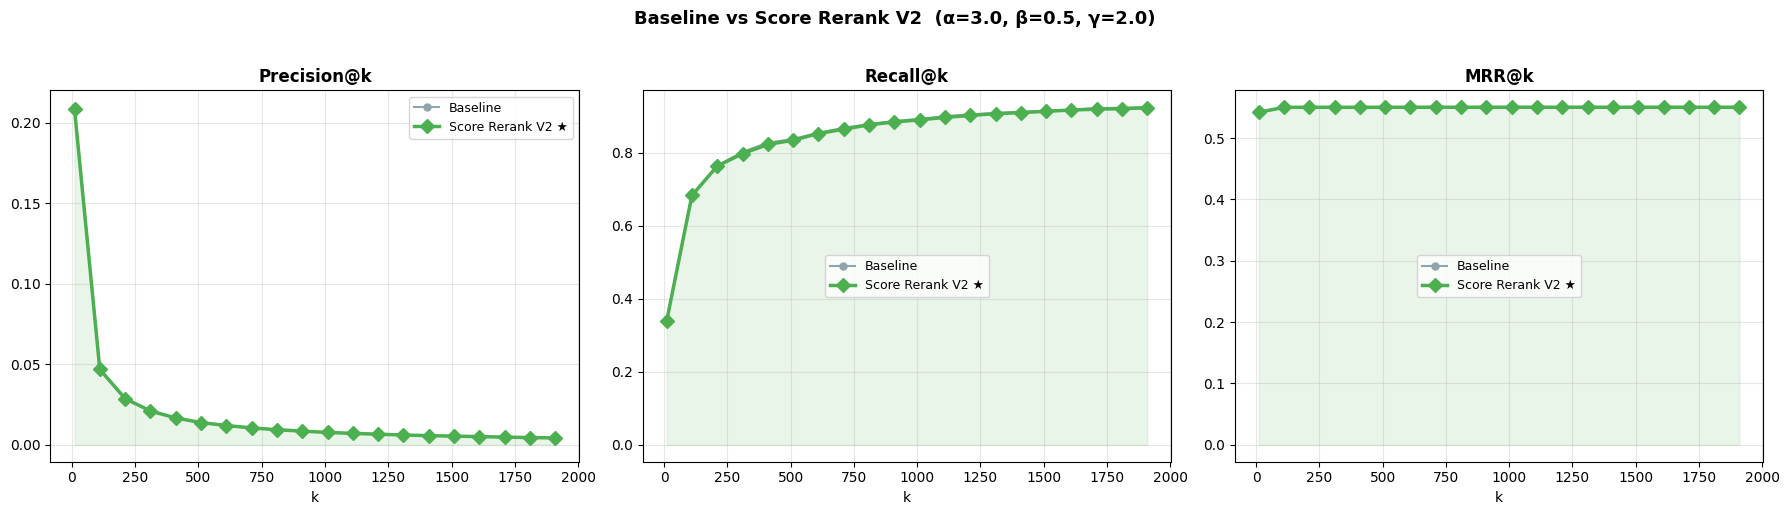

Saved: metrics_baseline_vs_v2.png


In [ ]:
def compute_metrics_from_features(train_features, gt_dict, id_to_pred_cat,
                                   alpha, beta, gamma, k_list):

    results = []
    for k in k_list:
        precisions, recalls, rr_list = [], [], []
        for qid, feats in train_features:
            relevant = gt_dict.get(qid, set())
            if not relevant:
                continue
            retrieved = score_and_rank(feats, id_to_pred_cat.get(qid),
                                       alpha, beta, gamma, k_docs=k)
            hits = sum(1 for d in retrieved if d in relevant)
            precisions.append(hits / k)
            recalls.append(hits / len(relevant))
            rr_list.append(next((1.0/r for r, d in enumerate(retrieved, 1)
                                 if d in relevant), 0.0))
        results.append({
            "k":           k,
            "Precision@k": round(np.mean(precisions), 4),
            "Recall@k":    round(np.mean(recalls),    4),
            "MRR@k":       round(np.mean(rr_list),    4),
        })
    return pd.DataFrame(results)


print(f"Calcul métriques V2 (α={BEST_ALPHA}, β={BEST_BETA}, γ={BEST_GAMMA})...")
metrics_v2_df = compute_metrics_from_features(
    train_features, gt_dict, train_id_to_pred_cat,
    BEST_ALPHA, BEST_BETA, BEST_GAMMA, K_LIST
)


print("\n===== RÉSUMÉ (k=10 et k=110) =====")
rows = []
for name, df in [("Baseline", metrics_baseline_df), ("Score Rerank V2", metrics_v2_df)]:
    for k_show in [10, 110]:
        r = df[df["k"] == k_show]
        if not r.empty:
            rows.append({"Méthode": name, "k": k_show,
                         "Precision@k": r["Precision@k"].values[0],
                         "Recall@k":    r["Recall@k"].values[0],
                         "MRR@k":       r["MRR@k"].values[0]})
print(pd.DataFrame(rows).to_string(index=False))


delta_df = metrics_baseline_df.copy()
for col in ["Precision@k", "Recall@k", "MRR@k"]:
    delta_df[col] = (metrics_v2_df[col] - metrics_baseline_df[col]).round(4)
print("\n===== DELTA V2 - Baseline (positif = amélioration) =====")
print(delta_df.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Baseline vs Score Rerank V2  (α={BEST_ALPHA}, β={BEST_BETA}, γ={BEST_GAMMA})",
             fontsize=13, fontweight="bold", y=1.02)
styles = [
    ("Baseline",          metrics_baseline_df, "#90A4AE", "o", "-",  1.5),
    ("Score Rerank V2 ★", metrics_v2_df,       "#4CAF50", "D", "-",  2.5),
]
for ax, metric in zip(axes, ["Precision@k", "Recall@k", "MRR@k"]):
    ks = metrics_baseline_df["k"].values
    for label, df, color, marker, ls, lw in styles:
        vals = df[metric].values
        ax.plot(ks, vals, marker=marker, label=label,
                color=color, linewidth=lw, markersize=5 if lw < 2 else 7, linestyle=ls)
        if "V2" in label:
            ax.fill_between(ks, vals, alpha=0.12, color=color)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("k")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_baseline_vs_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_baseline_vs_v2.png")

In [ ]:

topk_indices_test, topk_scores_test = retrieve_topk_blockwise(
    test_embeddings, doc_embeddings, k=K_CHUNKS
)

In [ ]:

K_SUBMIT       = 3000
test_query_ids = test_queries_df["id"].astype(str).tolist()

rows = []
for i, qid in enumerate(test_query_ids):
    pred_cat = test_id_to_pred_cat.get(qid)  

    retrieved = rerank_docs_v2(
        topk_indices_test[i], topk_scores_test[i], K_SUBMIT,
        chunk_to_doc, doc_chunk_counts, chunk_to_category,
        predicted_category=pred_cat,
        alpha=BEST_ALPHA, beta=BEST_BETA, gamma=BEST_GAMMA,
    )

  
    category = test_queries_df_with_prediction.loc[
        test_queries_df_with_prediction["id"].astype(str) == qid, "predicted_category"
    ]
    category = category.values[0] if len(category) else "unknown"

    rows.append({
        "query_id":         qid,
        "relevant_doc_ids": json.dumps(retrieved),
        "category":         category,
    })

submission_df = pd.DataFrame(rows)


submission_df["doclen"] = submission_df["relevant_doc_ids"].apply(lambda x: len(json.loads(x)))
print("--- Distribution longueurs ---")
print(submission_df["doclen"].describe())
print(f"Queries avec < 100 docs : {(submission_df['doclen'] < 100).sum()}")
print(f"Catégories uniques      : {submission_df['category'].nunique()} — {sorted(submission_df['category'].unique())}")

out_path = "solutions_score_rerank_v2.csv"
submission_df.drop(columns=["doclen"]).to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
submission_df.drop(columns=["doclen"]).head()

--- Distribution longueurs ---
count     141.0
mean     3000.0
std         0.0
min      3000.0
25%      3000.0
50%      3000.0
75%      3000.0
max      3000.0
Name: doclen, dtype: float64
Queries avec < 100 docs : 0
Catégories uniques      : 5 — ['android', 'gaming', 'programmers', 'tex', 'unix']

Saved: solutions_score_rerank_v2.csv


,query_id,relevant_doc_ids,category
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,"[""fd449cc9-3a39-4669-9c88-257f806ac488_108240""...",programmers
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,"[""f0218cf9-89ac-4da0-952a-a35a4a84ac48_126145""...",unix
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,"[""43fa6e5a-6ad6-4701-ba44-68b513409ffc_17053"",...",android
3,cb216e47-add6-41fd-974a-39251e4df3aa_6777,"[""6e0ba632-cb40-43ca-a808-387f28b950bd_46487"",...",unix
4,14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748,"[""59108dd2-5f5a-4add-b947-3303c8aaa891_123331""...",programmers


In [ ]:

from google.colab import files
files.download(out_path)

**Reranking Pipeline — Summary**

The baseline embedding retrieval is improved by a **custom scoring function** that combines four signals:

- **Cosine hybrid** — blends the best chunk score (max) with a rank-weighted mean, rewarding both peak relevance and consistency across chunks.
- **Completion ratio** — promotes documents for which many chunks were retrieved, as a proxy for topical coverage.
- **First-rank bonus** — gives an NDCG-style boost to documents whose first chunk appears early in the ranking.
- **Category match** — applies a 0.5 penalty to documents whose category doesn't match the classifier's prediction, leveraging the classifier built in the embedding notebook.

Hyperparameters α, β, γ were tuned via **grid search on the training set**, using precomputed per-document features to avoid reprocessing 260k chunks for every combination — reducing search time from hours to seconds.